# Notebook - Find best Drug compound for `Marburg` virus

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [147]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [148]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

#Needed to show molecules
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from copy import deepcopy

import sys
sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [149]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [150]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')

In [151]:
allVirusData_chEMBL_wMACAW = pd.read_csv(modelBuildingDataDir + 'allVirusData_chEMBL_uM_wMACAW.csv')

### Filter columns and keeping only data for Marburg virus

In [152]:
allVirusData_chEMBL_wMACAW =  allVirusData_chEMBL_wMACAW.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Virus"]
)
MarburgVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW[allVirusData_chEMBL_wMACAW['Virus'] == 'Marburg']
MarburgVirusData_chEMBL_wMACAW

,molecule_chembl_id,smiles,value_uM,pPotency,Virus
14291,CHEMBL5593581,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2cccnc2)CC1,38.600,4.413,Marburg
14292,CHEMBL5593153,CN(C)C1CCN(C(=O)c2cc3occc3n2Cc2ccc(Cl)cc2)CC1,7.960,5.099,Marburg
14293,CHEMBL5584196,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2ccc(F)cc2)CC1,20.000,NaN,Marburg
14294,CHEMBL5593168,CC(C)N1CCN(C(=O)c2cc3sccc3n2Cc2ccc(Cl)cc2)CC1,32.800,4.484,Marburg
14295,CHEMBL1236524,Nc1ncnc2c([C@@H]3N[C@H](CO)[C@@H](O)[C@H]3O)c[...,3.000,5.523,Marburg
...,...,...,...,...,...
14489,CHEMBL5595280,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCCCC1)C...,107.000,3.971,Marburg
14490,CHEMBL5592622,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCN(C)CC...,47.600,4.322,Marburg
14491,CHEMBL1655,CN(C)CCOc1ccc(/C(=C(/CCCl)c2ccccc2)c2ccccc2)cc1,0.700,6.155,Marburg
14492,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,4.600,5.337,Marburg


### Rename columns

In [153]:
MarburgVirusData_chEMBL_wMACAW = MarburgVirusData_chEMBL_wMACAW.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "Virus" : "VirusClassifier",
})

### Compound Distribution Across Viruses

In [154]:
virus_counts = MarburgVirusData_chEMBL_wMACAW['VirusClassifier'].value_counts().sort_values(ascending=False)
total_compounds = len(MarburgVirusData_chEMBL_wMACAW)

print(f"\n{'Virus':<30} {'Count':>10} {'Percentage':>12}")
print("-"*70)

for virus, count in virus_counts.items():
    percentage = (count / total_compounds) * 100
    print(f"{virus:<30} {count:>10} {percentage:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<30} {total_compounds:>10} {100.0:>11.2f}%")
print(f"\nNumber of unique viruses: {len(virus_counts)}")


Virus                               Count   Percentage
----------------------------------------------------------------------
Marburg                               203      100.00%
----------------------------------------------------------------------
TOTAL                                 203      100.00%

Number of unique viruses: 1


### Add `ID` column to left

In [155]:
MarburgVirusData_chEMBL_wMACAW.insert(0, 'ID', range(1, len(MarburgVirusData_chEMBL_wMACAW) + 1))
MarburgVirusData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,value_uM,pPotency,VirusClassifier
14291,1,CHEMBL5593581,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2cccnc2)CC1,38.600,4.413,Marburg
14292,2,CHEMBL5593153,CN(C)C1CCN(C(=O)c2cc3occc3n2Cc2ccc(Cl)cc2)CC1,7.960,5.099,Marburg
14293,3,CHEMBL5584196,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2ccc(F)cc2)CC1,20.000,NaN,Marburg
14294,4,CHEMBL5593168,CC(C)N1CCN(C(=O)c2cc3sccc3n2Cc2ccc(Cl)cc2)CC1,32.800,4.484,Marburg
14295,5,CHEMBL1236524,Nc1ncnc2c([C@@H]3N[C@H](CO)[C@@H](O)[C@H]3O)c[...,3.000,5.523,Marburg


### Add another filer to keep only these four columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `VirusClassifier`

In [156]:
MarburgVirusData_chEMBL_wMACAW = MarburgVirusData_chEMBL_wMACAW.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "VirusClassifier"]
)
MarburgVirusData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,pPotency,VirusClassifier
14291,1,CHEMBL5593581,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2cccnc2)CC1,4.413,Marburg
14292,2,CHEMBL5593153,CN(C)C1CCN(C(=O)c2cc3occc3n2Cc2ccc(Cl)cc2)CC1,5.099,Marburg
14293,3,CHEMBL5584196,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2ccc(F)cc2)CC1,NaN,Marburg
14294,4,CHEMBL5593168,CC(C)N1CCN(C(=O)c2cc3sccc3n2Cc2ccc(Cl)cc2)CC1,4.484,Marburg
14295,5,CHEMBL1236524,Nc1ncnc2c([C@@H]3N[C@H](CO)[C@@H](O)[C@H]3O)c[...,5.523,Marburg


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [157]:
print("Original shape:", MarburgVirusData_chEMBL_wMACAW.shape)

MarburgVirusData_chEMBL_wMACAW = MarburgVirusData_chEMBL_wMACAW[MarburgVirusData_chEMBL_wMACAW['pPotency'].notna() 
    & (MarburgVirusData_chEMBL_wMACAW['pPotency'] > 0) ]   # & (MarburgVirusData_chEMBL_wMACAW['pPotency'] < 12)

print("Shape after cleaning 'pPotency' value:", MarburgVirusData_chEMBL_wMACAW.shape)

Original shape: (203, 5)
Shape after cleaning 'pPotency' value: (186, 5)


In [158]:
MarburgVirusData_chEMBL_wMACAW

,ID,compound_id,Smiles,pPotency,VirusClassifier
14291,1,CHEMBL5593581,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2cccnc2)CC1,4.413,Marburg
14292,2,CHEMBL5593153,CN(C)C1CCN(C(=O)c2cc3occc3n2Cc2ccc(Cl)cc2)CC1,5.099,Marburg
14294,4,CHEMBL5593168,CC(C)N1CCN(C(=O)c2cc3sccc3n2Cc2ccc(Cl)cc2)CC1,4.484,Marburg
14295,5,CHEMBL1236524,Nc1ncnc2c([C@@H]3N[C@H](CO)[C@@H](O)[C@H]3O)c[...,5.523,Marburg
14296,6,CHEMBL5592994,CCN1CCN(CC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)C3...,4.521,Marburg
...,...,...,...,...,...
14489,199,CHEMBL5595280,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCCCC1)C...,3.971,Marburg
14490,200,CHEMBL5592622,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCN(C)CC...,4.322,Marburg
14491,201,CHEMBL1655,CN(C)CCOc1ccc(/C(=C(/CCCl)c2ccccc2)c2ccccc2)cc1,6.155,Marburg
14492,202,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,5.337,Marburg


### Remove duplicate compounds using Compute median potency per (Smiles, Virus) pair

In [159]:
duplicates = MarburgVirusData_chEMBL_wMACAW.duplicated(subset=['Smiles', 'VirusClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 34


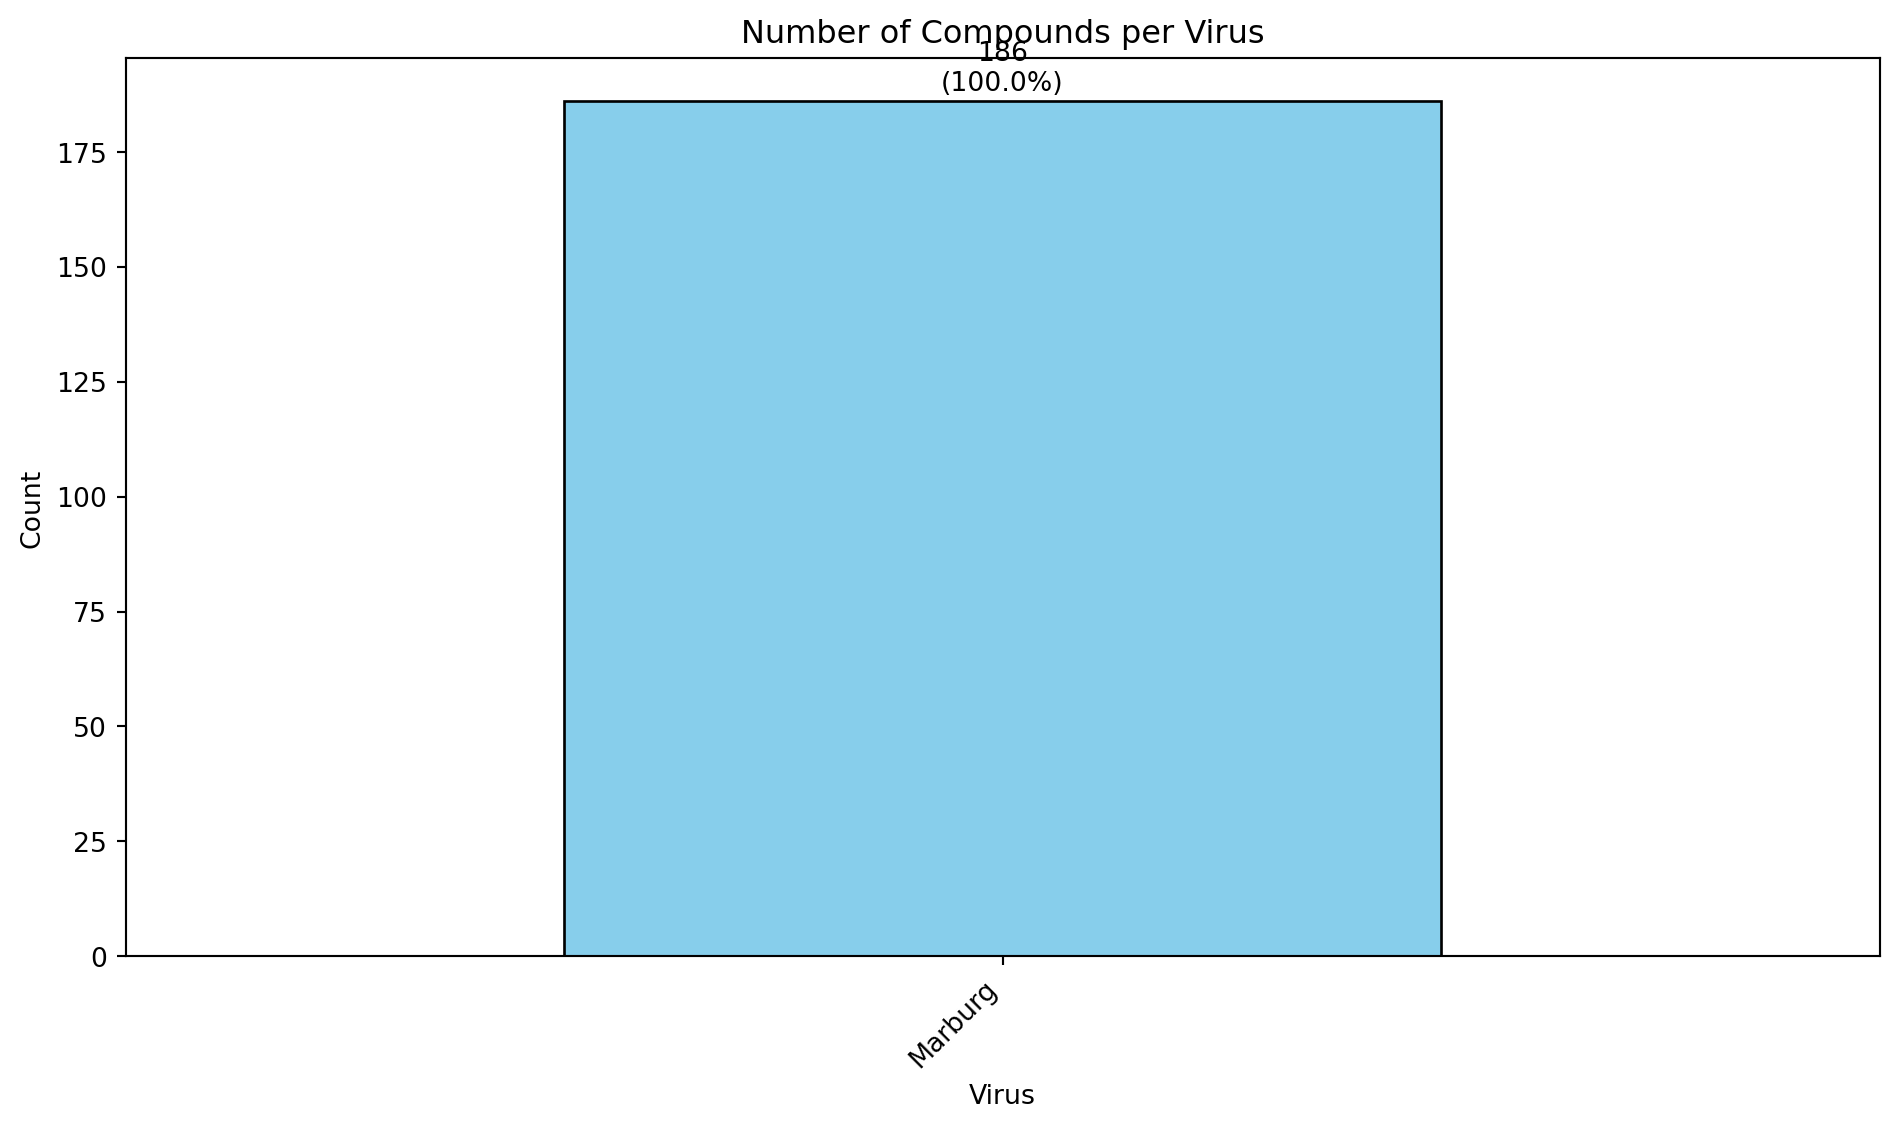

In [160]:
# Get counts and percentages
counts = MarburgVirusData_chEMBL_wMACAW['VirusClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [161]:
MarburgVirusData_chEMBL_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "MarburgVirusData_chEMBL_wMACAW_MLready.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [163]:
# df = MarburgVirusData_chEMBL_wMACAW
Y = MarburgVirusData_chEMBL_wMACAW.pPotency
smiles = MarburgVirusData_chEMBL_wMACAW.Smiles

In [164]:
print(len(smiles))

186


### Normalize the potency data
$$
\begin{align}
\text{value (M)} &= \text{value}_{\mu M} \times 10^{-6} \\
p\text{Potency} &= -\log_{10}(\text{value (M)}) \\
&= 6 - \log_{10}(\text{value}_{\mu M})
\end{align}
$$

so, $$ p\text{Potency} = 6 - \log_{10}(\text{value}_{\mu M}) $$

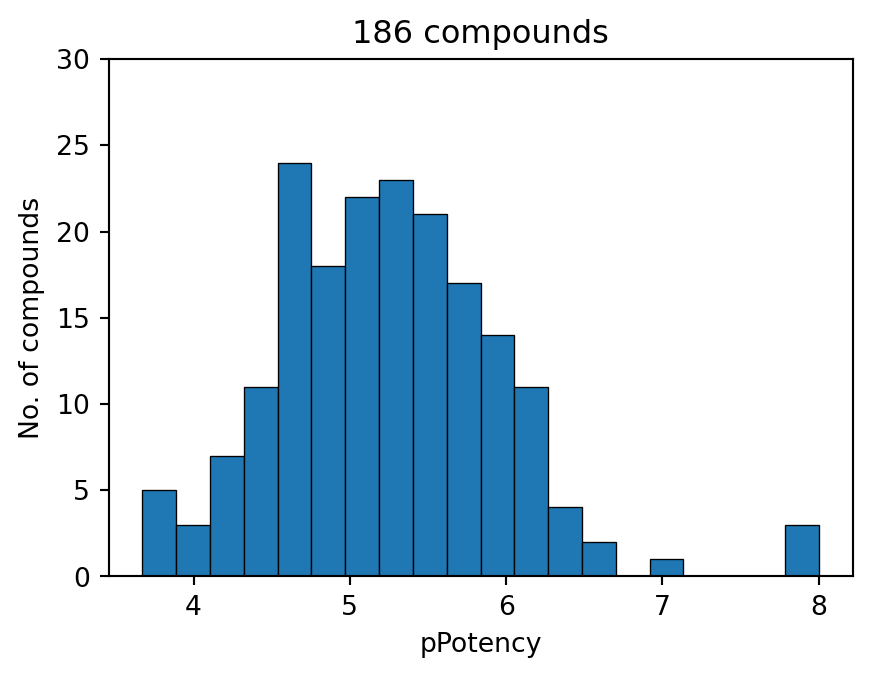

In [165]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [166]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [167]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [168]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [169]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 186 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### Create directory to save plot

In [170]:
save_path = resultsDir + 'Marburgvirus/MarburgVirus_CV_testOnly.svg'
os.makedirs(os.path.dirname(save_path), exist_ok=True)

### ML predictions with Train + Test results

In [171]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.22
  RMSE: 0.32
  R²:   0.80
Test Set:
  MAE:  0.33
  RMSE: 0.47
  R²:   0.57

Best params (sample): [{'C': 1, 'epsilon': 0.1, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.1, 'kernel': 'rbf'}, {'C': 5, 'epsilon': 0.1, 'kernel': 'rbf'}]
CPU times: user 132 ms, sys: 40.8 ms, total: 173 ms
Wall time: 8.43 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_CV_TrTs.png


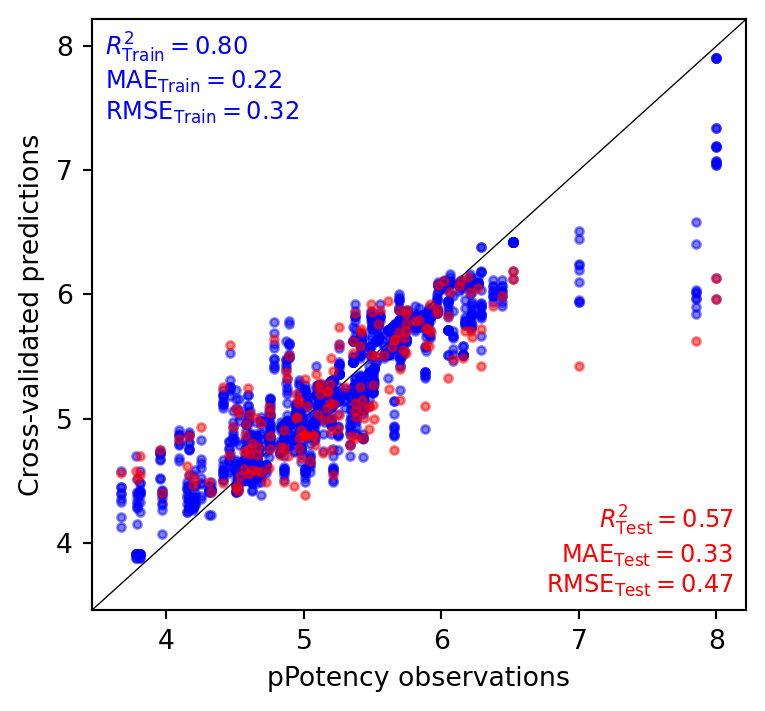

In [172]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'Marburgvirus/MarburgVirus_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [173]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=39
)
mcw.fit(smiles, Y)

In [174]:
X_all = mcw.transform(smiles)
X_all.shape

(186, 15)

Training samples: 148
Test samples: 38
Feature dimensions: 15

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 5
  epsilon: 0.1
  kernel: rbf

Best CV MAE (on training folds): 0.33

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.90            0.56            0.34           
MAE        0.16            0.36            0.20           
RMSE       0.22            0.54            0.32           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_fullData_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/D

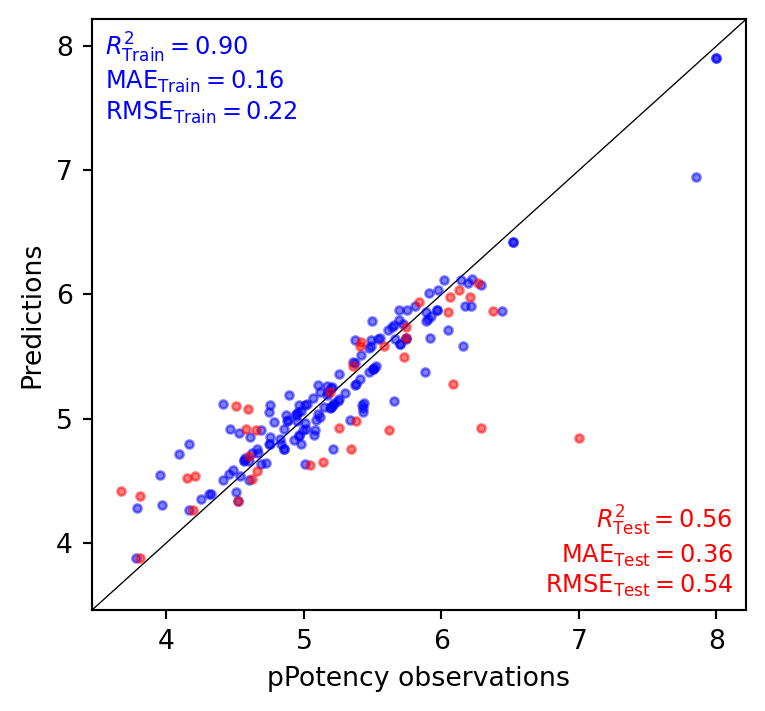

CPU times: user 1.04 s, sys: 88.2 ms, total: 1.13 s
Wall time: 1.75 s


In [175]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=39
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)

# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=resultsDir + 'Marburgvirus/MarburgVirus_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

### Compare performance of different ML model

- SVR
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Neural Network

Import all necessary libraries

## 2.1 Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [176]:
EnamineAntiviralsData = pd.read_csv(dataDir + "Enamine/Enamine_Antiviral_Library_plated_3200cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                    skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntiviralsData.shape}")

smiles_train = MarburgVirusData_chEMBL_wMACAW.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntiviralsData['Canonical_SMILES'] = EnamineAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntiviralsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntiviralsData_filtered = EnamineAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntiviralsData = EnamineAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntiviralsData.shape}")
print(f"Removed {EnamineAntiviralsData.shape[0] - EnamineAntiviralsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib = EnamineAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
EnamineAntiviralsData.head()

Original Enamine data shape: (3200, 11)
Number of unique SMILES in training set: 152
Filtered Enamine data shape for validation: (3200, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 3200


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,Z410227912,256.326,256.326,1.231,-2.190,2,4,76.140,5,https://real.enamine.net/public-enum-files/Z41...
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,Z383167688,237.256,237.256,-0.042,-0.692,1,3,69.720,5,https://real.enamine.net/public-enum-files/Z38...
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,Z235579208,306.404,306.404,1.583,-2.082,1,5,57.700,7,NaN
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,Z403694008,279.379,279.379,1.156,-0.660,1,3,58.370,7,https://real.enamine.net/public-enum-files/Z40...
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,Z384461492,307.389,307.389,1.084,-1.180,1,4,61.880,7,https://real.enamine.net/public-enum-files/Z38...


Generate predictions for the H1 receptor:

In [177]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [178]:
EnamineAntiviralsData_predicted = EnamineAntiviralsData.copy()
EnamineAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
EnamineAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-EnamineAntiviralsData_predicted['pPotency_prediction'])

EnamineAntiviralsData_predicted = EnamineAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
EnamineAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_EnamineDatasets_predicted_all.csv"), index=False)
EnamineAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_EnamineDatasets_predicted_all_SMILES.csv"), index=False)
EnamineAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,4.805,1.568e-05
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,4.537,2.903e-05
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,4.871,1.345e-05
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,4.740,1.819e-05
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,4.823,1.504e-05
...,...,...,...
3195,CCOC=1N=CC=CC1NC(=O)NC2CCN3CCCCC23,4.915,1.217e-05
3196,CC1=NN(CC(O)C=2C=CC=CC2)C(=O)C(C#N)=C1C,4.854,1.400e-05
3197,CCC1=NN=NN1CC(=O)NC2CCN(CC2)C(C)=O,4.736,1.836e-05
3198,CC=1C=C2N=CN(CC(O)CN3CCS(=O)CC3)C2=CC1C,4.767,1.709e-05


Let us represent the predictions of both models:

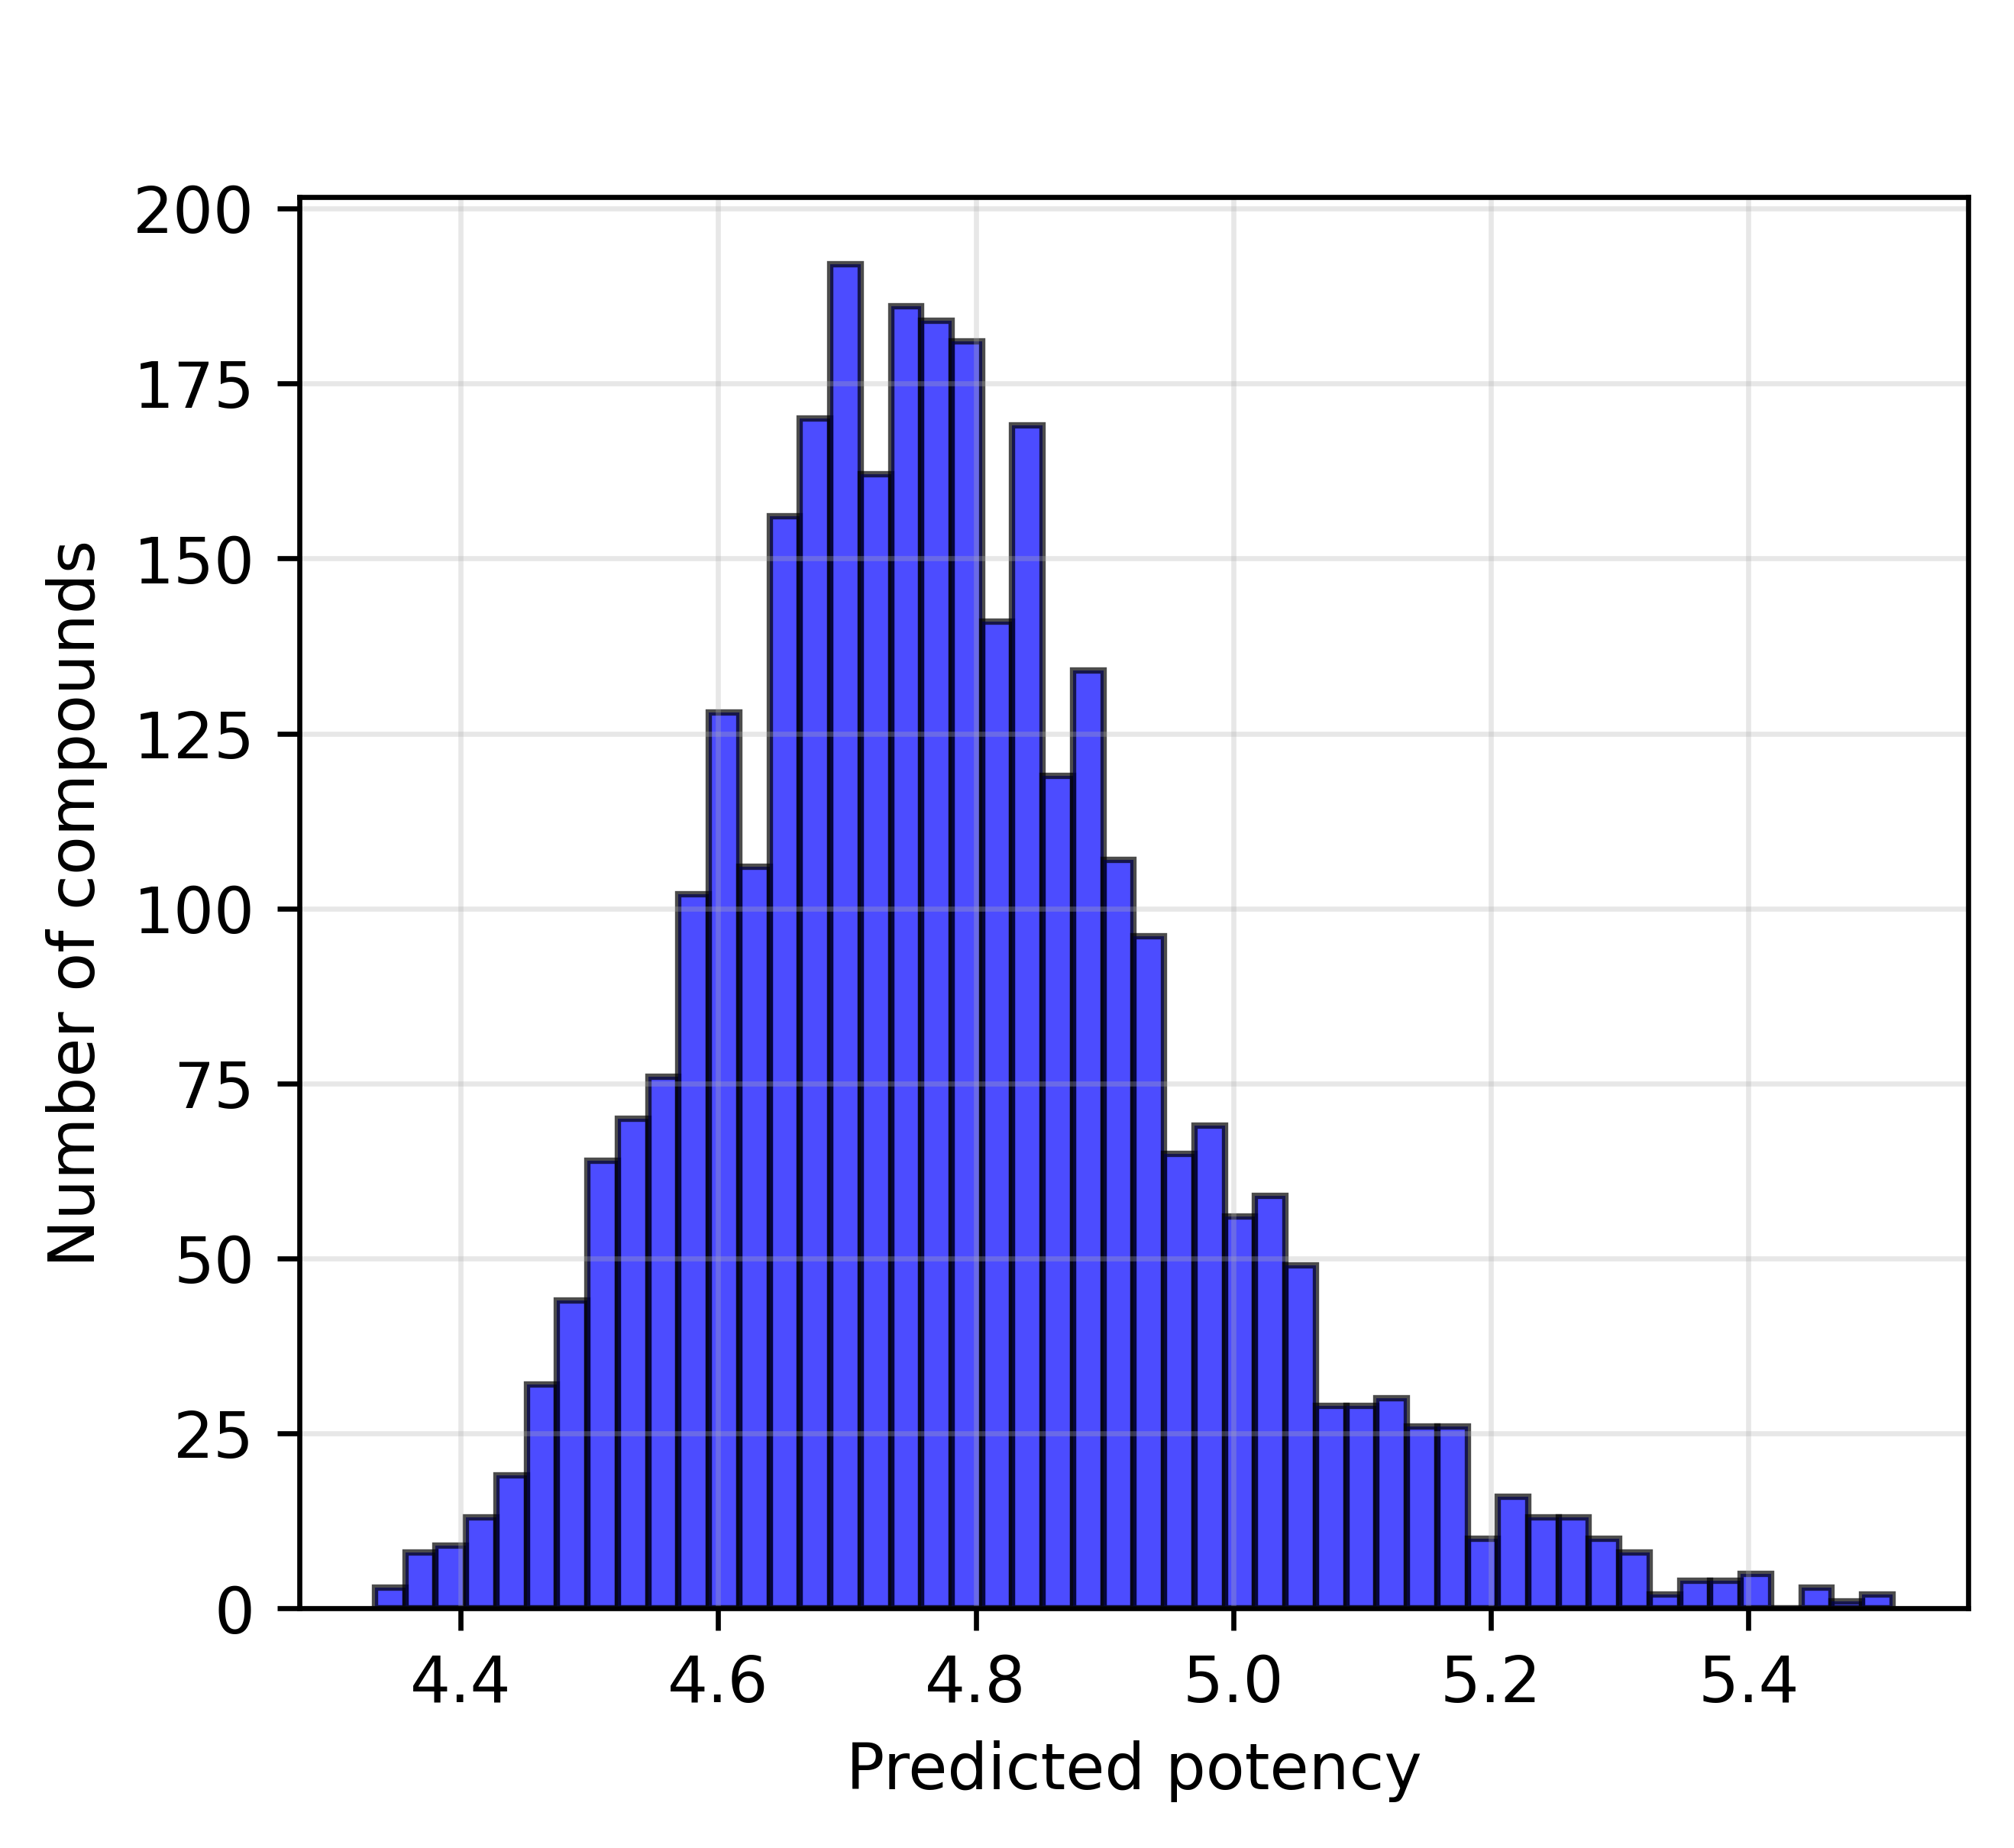

In [179]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_validation_EnamineDataset.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_validation_EnamineDataset.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [180]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 377 compounds


In [181]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,pPotency_prediction


### Top 20 compounds with higher PpPotency

In [182]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 5.34
Highest predicted pPotency: 5.51
Range of top 20: 5.34 - 5.51


In [183]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntiviralsData_top20 = EnamineAntiviralsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntiviralsData_top20 = EnamineAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    5.342
  IC50:        4.553e-06 M  (4552.52 nM)

Best Values (1st ranked compound):
  pPotency:    5.512
  IC50:        3.078e-06 M  (3077.83 nM)
Range for Top 20 Compounds:
pPotency Range:  5.342 - 5.512

IC50 Range (M):  4.553e-06 - 3.078e-06


,Rank,SMILES,pPotency_prediction,IC50 (M)
2984,1,CC1=CC=2N=CN(CC(O)CNC(C)C(C)N3C=CC=N3)C2C=C1C,5.512,3.078e-06
2880,2,COC=1C=C(C=CC1OCC(O)CN2C=NC=3C=CC=CC32)C(C)=O,5.498,3.176e-06
2584,3,CC=1C=NN(C1)CC(C)NCC(O)CN2C=NC=3C=C(C)C(C)=CC32,5.471,3.383e-06
1444,4,CNC=1N=CN=C2N=CN(CC(O)COC=3C(C)=CC=CC3C)C12,5.462,3.448e-06
2219,5,COCCN1C(=NC2=C1C(=O)NC(=O)N2C)NN=CC=3C=CC=CC3,5.462,3.449e-06
255,6,CC=1C=C2N=CN(CC(O)COC3=CC(C)=C(C)N=N3)C2=CC1C,5.441,3.619e-06
2645,7,COC=1C=C(C#N)C=CC1OCCN2C(=NC=3C=CC=CC32)C(C)O,5.416,3.837e-06
475,8,CC=1C=CC(C)=C(C1)OCC(O)CN2N=CC=3C=NN(C)C(=O)C32,5.412,3.870e-06
841,9,CC=1C=CC(C)=C(C1)OCC(O)CN2N=C(C=CC2=O)N3C=CN=C3,5.411,3.880e-06
200,10,CNC=1N=CN=C2N=CN(CC(O)COCC=3C=CC=CC3)C12,5.409,3.900e-06


In [184]:
EnamineAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_EnamineAntiviralsData_top20.csv"), index=False)
EnamineAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_EnamineAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_EnamineDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_EnamineDataset.svg


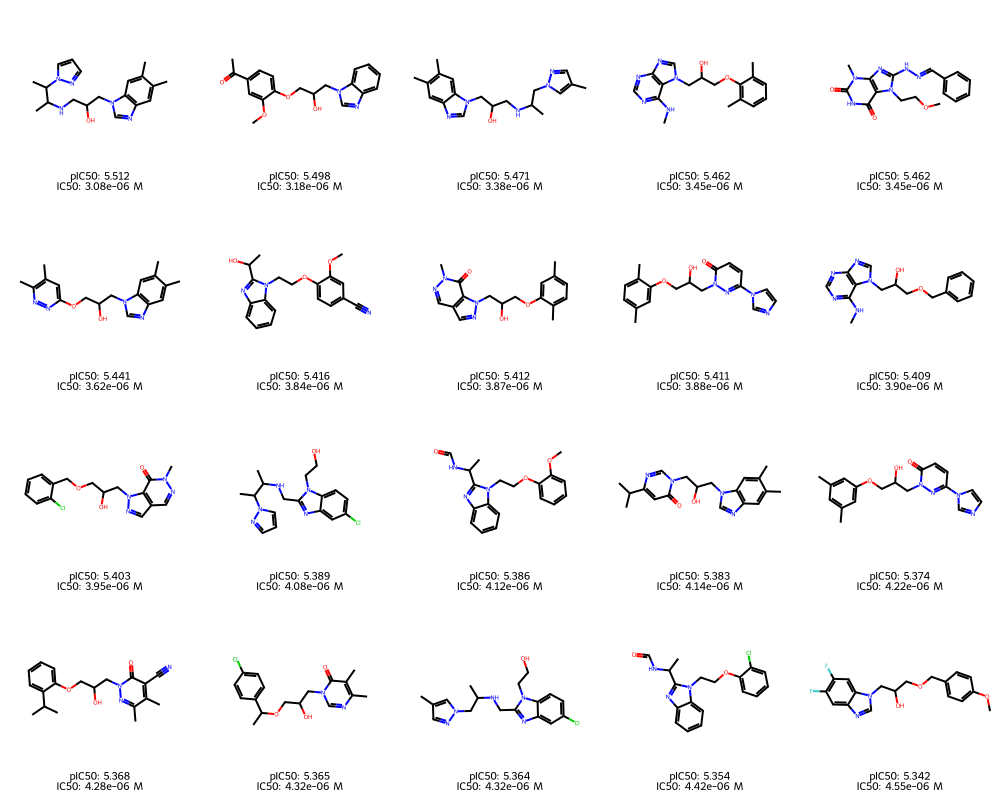

In [185]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'Marburgvirus/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'MarburgVirus_predictedCompounds_EnamineDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'MarburgVirus_predictedCompounds_EnamineDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

## 2.2 Discovery of new hits specific to all viruses (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [186]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Merged_Antiviral_Screening_Superset.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntiviralsData_superset = pd.DataFrame(records)
print(f"Original LifeChemicals data shape: {LCAntiviralsData_superset.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntiviralsData_superset['Canonical_SMILES'] = LCAntiviralsData_superset['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntiviralsData_superset['Canonical_SMILES'].isin(canonical_train)
LCAntiviralsData_superset_filtered = LCAntiviralsData_superset[mask].copy()

# Remove the helper column if you don't need it
LCAntiviralsData_superset = LCAntiviralsData_superset_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntiviralsData_superset.shape}")
print(f"Removed {LCAntiviralsData_superset_filtered.shape[0] - LCAntiviralsData_superset.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib = LCAntiviralsData_superset.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
LCAntiviralsData_superset.head()

Original LifeChemicals data shape: (45573, 17)
Number of unique SMILES in training set: 152
Filtered LifeChemicals data shape for validation: (45573, 17)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 45573


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,Acceptor,Donor,RotBonds,HAC,Collection,Library,PPDS,SMILES
0,F6544-0534,"11-(oxan-4-yl)-7,11-diazatricyclo[7.3.1.0²,⁷]t...",2034607-75-3,1.500,274.360,solid,0.690,-0.120,32.780,2,1,1,20.000,Advanced,Anti-Hepatitis_A_B_ Screening_Library,,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1
1,F6559-5304,6-[4-(trifluoromethyl)pyrimidin-2-yl]-6-azaspi...,2034225-11-9,1.500,301.260,solid,0.620,2.030,66.320,4,1,2,21.000,Advanced,2019-nCoV_Main_Protease_Targeted_Library,+,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2
2,F6610-6619,"1-methyl-4-[(pyridin-4-yl)methyl]-1,4-diazepane",2320860-02-2,1.000,205.300,oil,0.580,0.890,19.370,3,3,2,15.000,General,Anti-HIV_Focused_Library,,CN1CCCN(Cc2ccncc2)CC1
3,F6559-5274,"6-(4,6-dimethylpyrimidin-2-yl)-6-azaspiro[3.4]...",2034225-08-4,1.500,261.320,oil,0.640,2.090,66.320,4,1,2,19.000,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1
4,F1912-1536,N-cyclopropyl-N-(piperidin-4-yl)pyrimidin-4-amine,1781768-10-2,1.500,218.290,solid,0.670,0.790,41.050,2,2,3,16.000,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,c1cc(N(C2CCNCC2)C2CC2)ncn1


Generate predictions for the H1 receptor:

In [187]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [188]:
LCAntiviralsData_predicted = LCAntiviralsData_superset.copy()
LCAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
LCAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-LCAntiviralsData_predicted['pPotency_prediction'])

LCAntiviralsData_predicted = LCAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
LCAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_LCDatasets_predicted_all.csv"), index=False)
LCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_LCDatasets_predicted_all_SMILES.csv"), index=False)
LCAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1,4.509,3.094e-05
1,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2,4.566,2.718e-05
2,CN1CCCN(Cc2ccncc2)CC1,4.340,4.574e-05
3,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1,4.554,2.796e-05
4,c1cc(N(C2CCNCC2)C2CC2)ncn1,4.527,2.972e-05
...,...,...,...
45568,CCN1C=C/C(=C\C=C\c2cc[n+](CC)c3ccccc23)c2ccccc...,5.306,4.941e-06
45569,CCCN1/C(=C/C=C/c2sc3ccccc3[n+]2CCC)Sc2ccccc21....,5.194,6.394e-06
45570,COC(=O)c1ccccc1-c1c2ccc(=N)cc-2oc2cc(N)ccc12.Cl,4.772,1.689e-05
45571,CCN1/C(=C/C=C2\CCC(/C=C/c3sc4ccc(Cl)cc4[n+]3CC...,5.552,2.803e-06


Let us represent the predictions of both models:

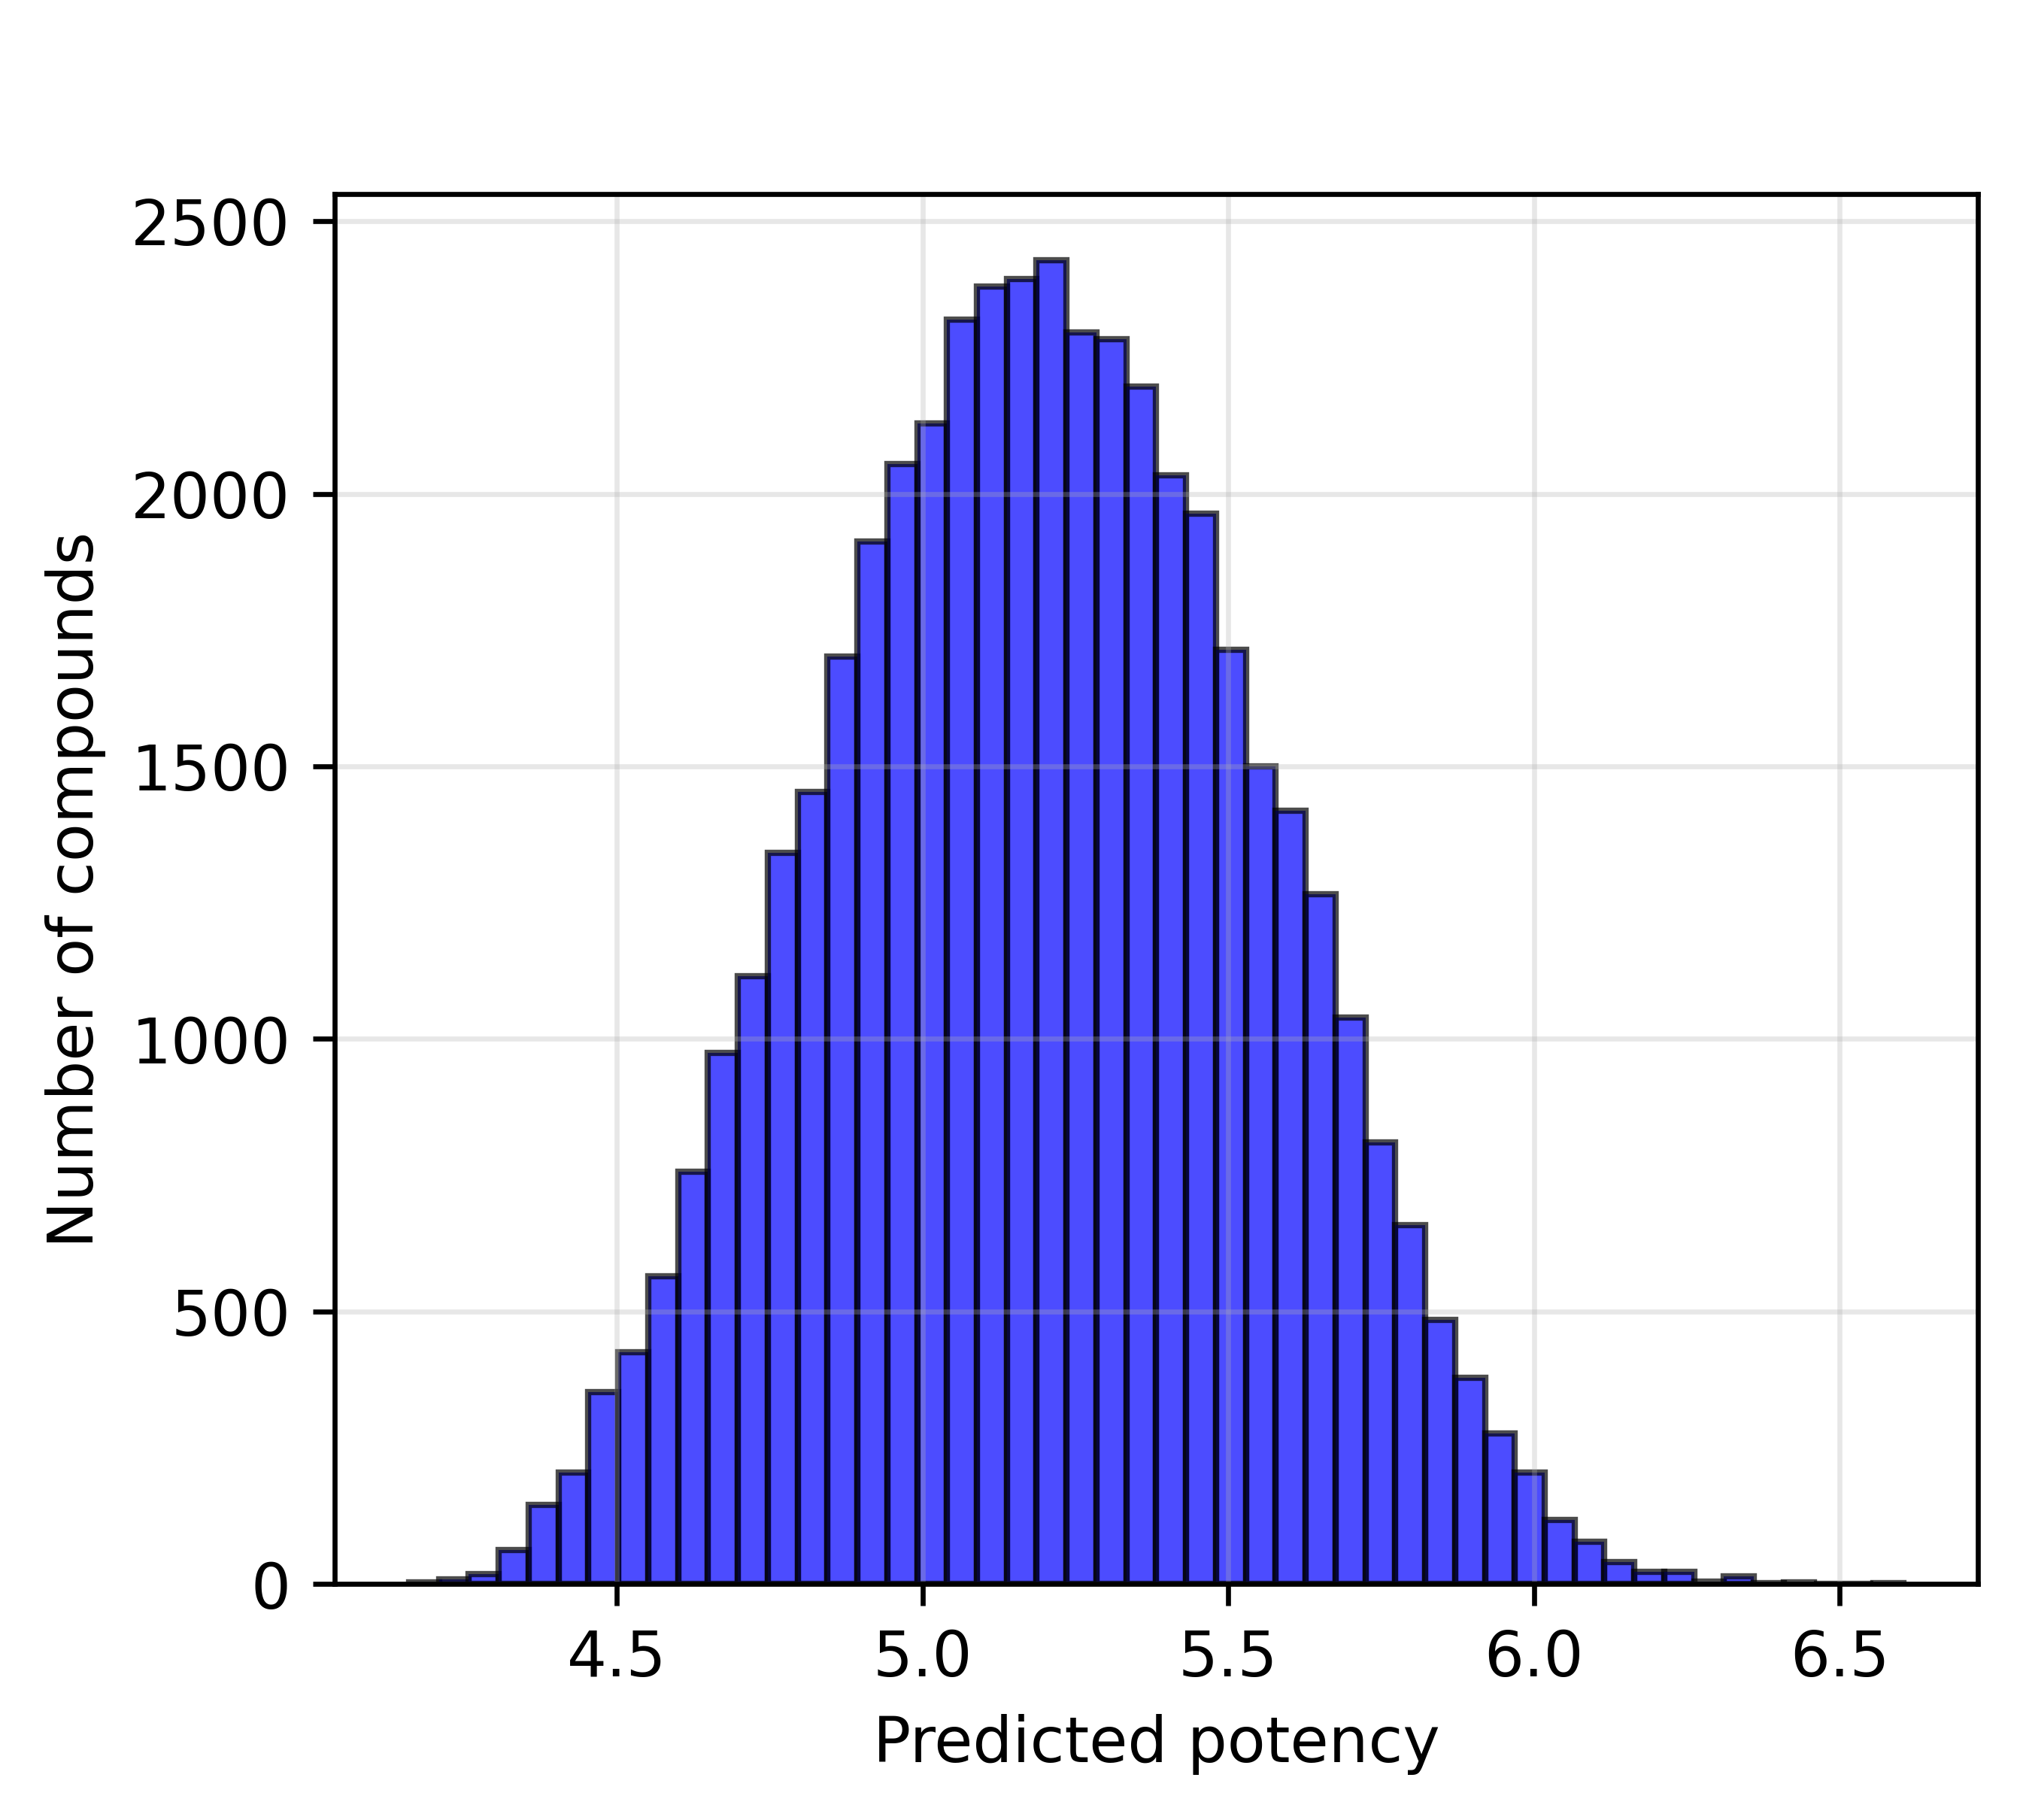

In [189]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_validation_LCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_validation_LCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [190]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 389 compounds
Low priority (5 ≤ pPotency < 6): 31700 compounds


In [191]:
LCAntiviralsData_superset_final = LCAntiviralsData_superset.iloc[idx].copy()
LCAntiviralsData_superset_final['pPotency_prediction'] = Y1_lib_pred[idx]
LCAntiviralsData_superset_final = LCAntiviralsData_superset_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
LCAntiviralsData_superset_final

,SMILES,pPotency_prediction,clogP


### Top 20 compounds with higher PpPotency

In [192]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.32
Highest predicted pPotency: 6.60
Range of top 20: 6.32 - 6.60


In [193]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntiviralsData_top20 = LCAntiviralsData_superset.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntiviralsData_top20 = LCAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.316
  IC50:        4.835e-07 M  (483.46 nM)

Best Values (1st ranked compound):
  pPotency:    6.604
  IC50:        2.487e-07 M  (248.75 nM)
Range for Top 20 Compounds:
pPotency Range:  6.316 - 6.604

IC50 Range (M):  4.835e-07 - 2.487e-07


,Rank,SMILES,pPotency_prediction,IC50 (M)
31117,1,COc1cccc(-c2noc(-c3cc(N4CCN(c5ccccn5)CC4)nc4cc...,6.604,2.487e-07
42642,2,COc1cccc(CSc2nc3cc(OC)c(OC)cc3c3nc(CCn4c(C)nc5...,6.599,2.517e-07
34688,3,COc1ccc(Nc2nc(N3CCN(c4ccccc4OC)CC3)nc3nccnc23)cc1,6.450,3.548e-07
42354,4,COc1ccccc1CC/N=C/c1c(NCCc2ccccc2OC)nc2ccc(C)cn...,6.441,3.623e-07
14805,5,Cc1ccc(Oc2cccc(C(=O)N3CCN(c4cc(Nc5ccccn5)nc(C)...,6.436,3.668e-07
33065,6,Cc1ccc(C)c(Nc2nc(N3CCN(c4ccccc4)CC3)nc3nccnc23)c1,6.380,4.173e-07
20519,7,Cc1nc(OCC(=O)NCCNc2cc(-n3cnc(C)c3C)ncn2)cc(-n2...,6.376,4.206e-07
37160,8,COc1ccc(Nc2nc(N3CCN(c4ccccc4OC)CC3)nc3[nH]ncc2...,6.356,4.411e-07
33967,9,COc1ccc(Nc2nc(N3CCN(Cc4ccccc4)CC3)nc3nccnc23)cc1,6.337,4.599e-07
38251,10,Cc1nc2ccccc2n1CCc1nc2c3ccccc3nc(NCc3ccccc3Cl)n2n1,6.336,4.613e-07


In [194]:
LCAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_LCAntiviralsData_top20.csv"), index=False)
LCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_LCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_LCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_LCDataset.svg


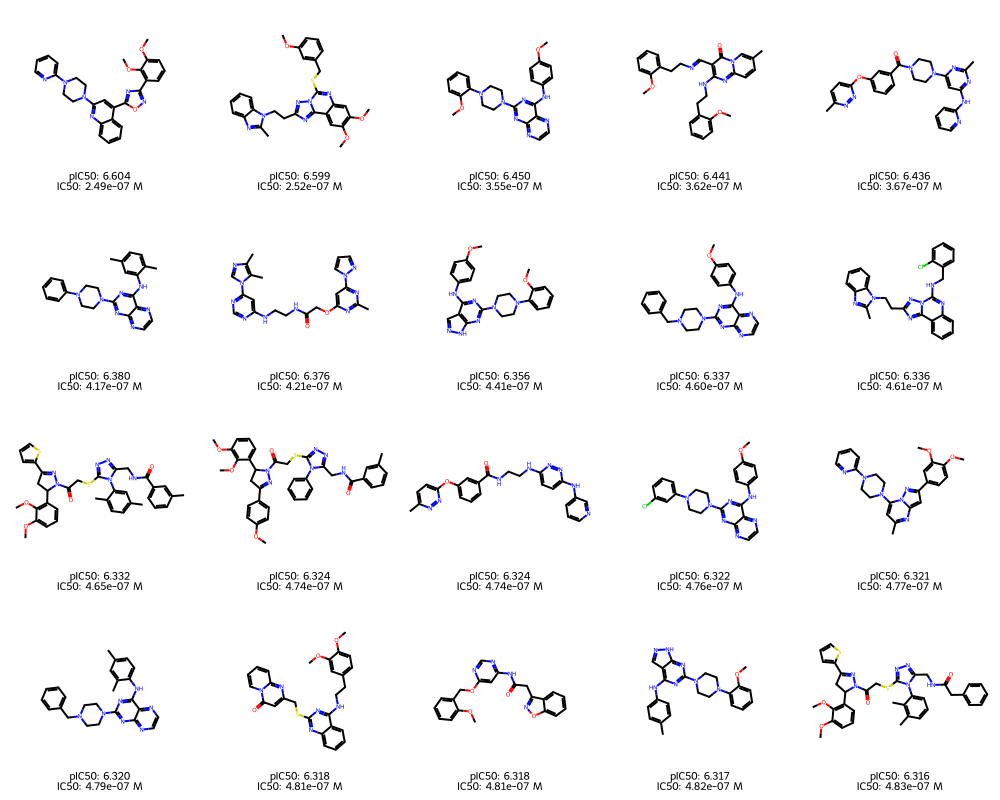

In [195]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'Marburgvirus/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in LCAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'MarburgVirus_predictedCompounds_LCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'MarburgVirus_predictedCompounds_LCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

## 2.3 Discovery of new hits specific to all viruses (data source `chemDiv` data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [196]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antiviral-Library-64958.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiviralsData = pd.DataFrame(records)
print(f"Original ChemDiv data shape: {ChemDivAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiviralsData['Canonical_SMILES'] = ChemDivAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiviralsData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiviralsData_filtered = ChemDivAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiviralsData = ChemDivAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiviralsData.shape}")
print(f"Removed {ChemDivAntiviralsData_filtered.shape[0] - ChemDivAntiviralsData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib = ChemDivAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
ChemDivAntiviralsData

Original ChemDiv data shape: (64958, 28)
Number of unique SMILES in training set: 152
Filtered ChemDiv data shape for validation: (64958, 28)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 64958


,IDNUMBER,available,H_acceptor,H_donor,B_rotN,N_O,logP,logD,logSw,PSA,...,InChI Key,PERCENTSP3,Link,CLNUMBER,Saltdata,Saltdata_MW,STEREO,State,SMILES,CAS
0,E676-1193,55,6,0,10,6.000,4.584,3.825,-4.736,44.193,...,CADSCKHSUSMLDE-UHFFFAOYSA-N,33.300,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,NaN
1,E676-4289,2,8,0,9,7.000,2.084,1.279,-2.867,59.381,...,GBCBRISSOXAFMF-UHFFFAOYSA-N,47.400,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,NaN
2,E676-2516,15,7,0,7,7.000,4.274,3.444,-4.355,53.078,...,LSLRIDUYGBBIBR-SFHVURJKSA-N,36.400,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,RACEMIC MIXTURE,Solid,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,NaN
3,F735-0482,21,7,2,9,7.000,3.231,3.225,-3.423,79.491,...,NBFDETMKPOQYSJ-UHFFFAOYSA-N,22.200,https://www.chemdiv.com/catalog/screening-comp...,CL8286,NaN,NaN,ACHIRAL,Solid,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,NaN
4,G211-0195,304,5,1,5,5.000,5.054,5.054,-5.469,49.877,...,DRPXIGZHBISZAU-UHFFFAOYSA-N,32.000,https://www.chemdiv.com/catalog/screening-comp...,CL6036,NaN,NaN,ACHIRAL,Solid,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64953,8010-2606,54,8,1,9,8.000,6.685,3.100,-6.678,70.818,...,ZQXAXHNEVALOJP-UHFFFAOYSA-N,30.800,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,NaN
64954,2774-1508,1,7,1,8,7.000,6.551,3.884,-5.738,62.323,...,KDXCUTJRVPCZKK-UHFFFAOYSA-N,25.000,https://www.chemdiv.com/catalog/screening-comp...,CL1652,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,NaN
64955,K061-0539,124,7,1,7,7.000,6.014,2.429,-5.464,64.713,...,XEIANUQFWJNADZ-UHFFFAOYSA-N,27.300,https://www.chemdiv.com/catalog/screening-comp...,CL1647,NaN,NaN,ACHIRAL,Solid,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,NaN
64956,K061-0894,165,6,1,7,7.000,6.905,6.387,-6.761,57.369,...,IBXAKUXFQPUZBE-UHFFFAOYSA-N,13.600,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,NaN


Generate predictions for the H1 receptor:

In [197]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

50000


In [198]:
ChemDivAntiviralsData_predicted = ChemDivAntiviralsData.copy()
ChemDivAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
ChemDivAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-ChemDivAntiviralsData_predicted['pPotency_prediction'])

ChemDivAntiviralsData_predicted = ChemDivAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
ChemDivAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_ChemDivDatasets_predicted_all.csv"), index=False)
ChemDivAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_ChemDivDatasets_predicted_all_SMILES.csv"), index=False)
ChemDivAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,5.495,3.200e-06
1,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,4.911,1.229e-05
2,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,5.415,3.843e-06
3,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,5.139,7.259e-06
4,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,5.047,8.970e-06
...,...,...,...
64953,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,5.707,1.961e-06
64954,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,5.567,2.711e-06
64955,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.571,2.685e-06
64956,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,5.830,1.480e-06


Let us represent the predictions of both models:

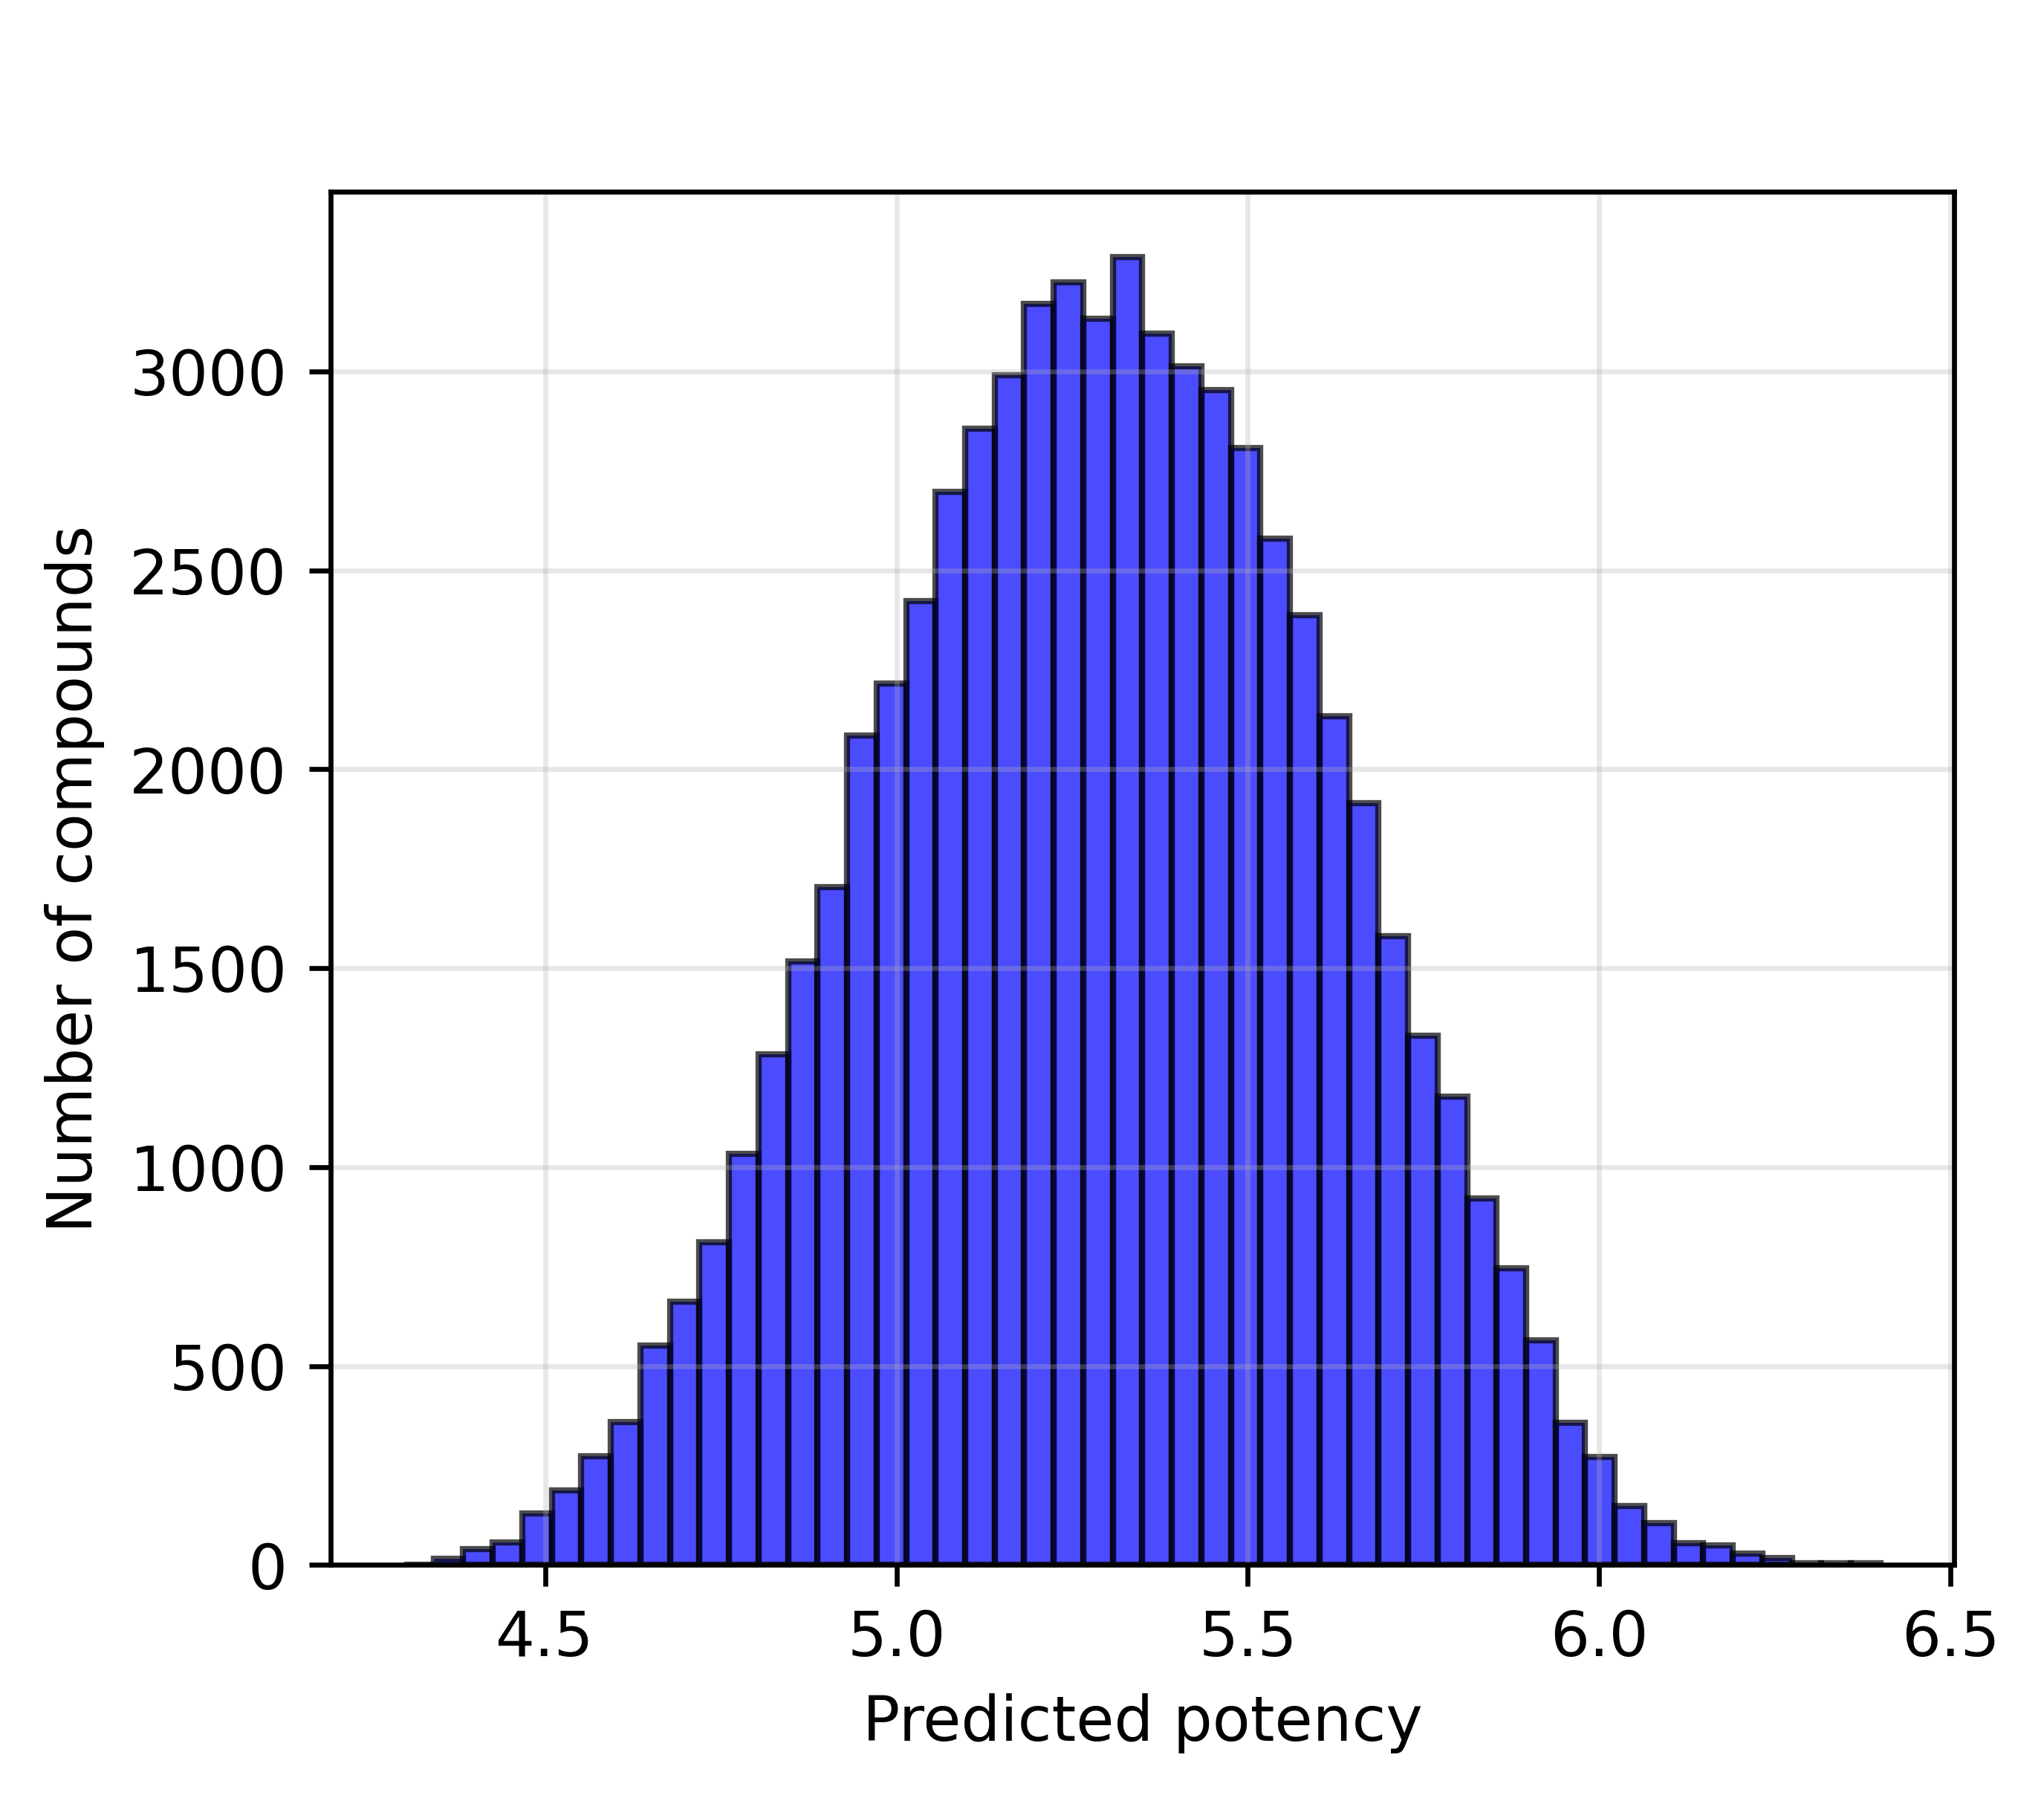

In [199]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_validation_ChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_validation_ChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [200]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 543 compounds
Low priority (5 ≤ pPotency < 6): 52274 compounds


In [201]:
ChemDivAntiviralsData_final = ChemDivAntiviralsData.iloc[idx].copy()
ChemDivAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]
ChemDivAntiviralsData_final = ChemDivAntiviralsData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
ChemDivAntiviralsData_final

,SMILES,pPotency_prediction


### Top 20 compounds with higher PpPotency

In [202]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.25
Highest predicted pPotency: 6.40
Range of top 20: 6.25 - 6.40


In [203]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
ChemDivAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.253
  IC50:        5.582e-07 M  (558.19 nM)

Best Values (1st ranked compound):
  pPotency:    6.400
  IC50:        3.979e-07 M  (397.93 nM)
Range for Top 20 Compounds:
pPotency Range:  6.253 - 6.400

IC50 Range (M):  5.582e-07 - 3.979e-07


,Rank,SMILES,pPotency_prediction,IC50 (M)
19751,1,C=CCOc1c(OC)cccc1C1CC(=O)Nc2c1c(C)nn2-c1nncc(-...,6.400,3.979e-07
53370,2,COc1cccc(C2Cn3nnc(-c4nc(-c5ccccc5OCc5ccccc5)no...,6.363,4.334e-07
34014,3,COc1cc2c(cc1OC)CN(c1cc(C(=O)NCc3ccccn3)c3ccccc...,6.360,4.361e-07
56395,4,C=CCOc1cc(C2CC(=O)Nc3c2c(C)nn3-c2nncc(-c3cccc(...,6.359,4.375e-07
5142,5,C=CCOc1ccc(C2CC(=O)Nc3c2c(C)nn3-c2nncc(-c3cccc...,6.344,4.525e-07
41280,6,CCOc1ccc(C2Cn3nnc(-c4nc(-c5ccccc5OCC)no4)c3CO2...,6.342,4.547e-07
59303,7,COc1cccc(-c2nc(-c3nnn4c3COC(c3ccccc3Cl)C4)no2)...,6.340,4.570e-07
33565,8,CCOc1cc(-c2noc(-c3nnn4c3COC(c3ccc(C)cc3C)C4)n2...,6.327,4.708e-07
53371,9,COc1ccc(-c2noc(-c3nnn4c3COC(c3ccc(C)cc3C)C4)n2...,6.313,4.866e-07
19750,10,C=CCOc1ccccc1C1CC(=O)Nc2c1c(C)nn2-c1nncc(-c2cc...,6.305,4.951e-07


In [204]:
ChemDivAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_ChemDivAntiviralsData_top20.csv"), index=False)
ChemDivAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_ChemDivAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_ChemDivDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_ChemDivDataset.svg


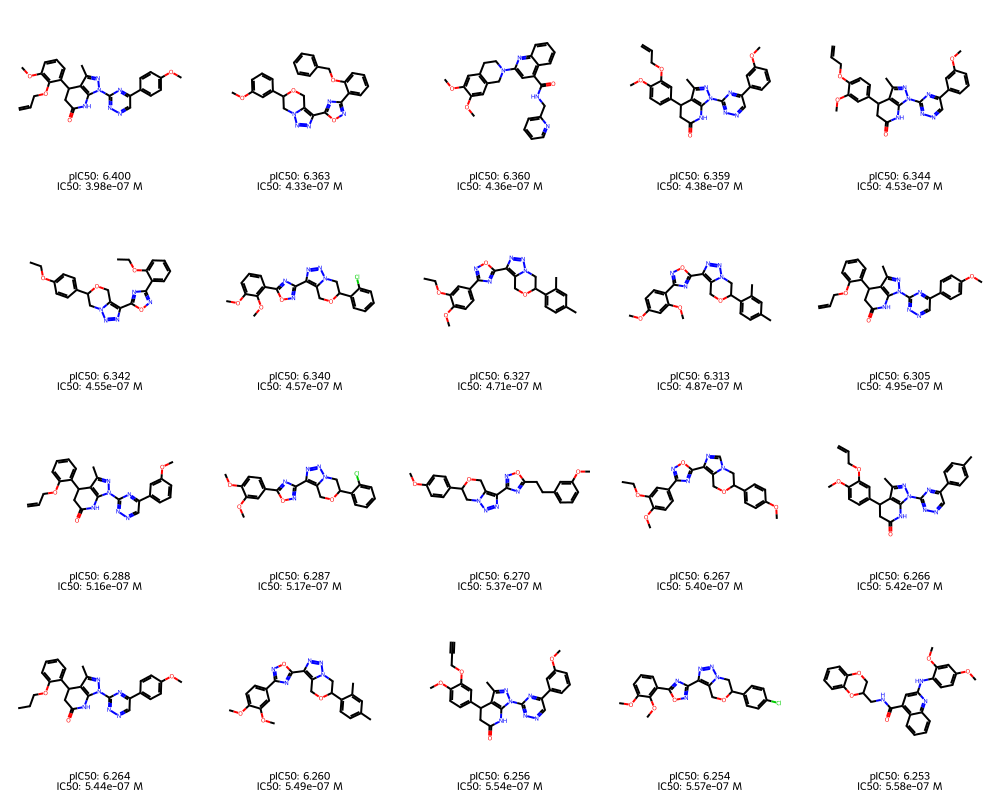

In [205]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'Marburgvirus/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in ChemDivAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'MarburgVirus_predictedCompounds_ChemDivDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'MarburgVirus_predictedCompounds_ChemDivDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.4 Discovery of new hits specific to all viruses (data source `SMACC` Antivirals data set)
In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. In particular, we are interested in molecules with high predicted pPotency.

In [206]:
SMACCAntiviralsData = pd.read_csv(modelBuildingDataDir + "SMACCAntiviralsData_clean.csv")

# Check for duplicates
dup_check = SMACCAntiviralsData.groupby('SMILES')['pIC50'].agg(['count', 'median', 'std'])
duplicates = dup_check[dup_check['count'] > 1]
print(f"Original SMACC data shape: {SMACCAntiviralsData.shape}, with Duplicate SMILES: {len(duplicates)}")

# Take median pIC50 for duplicates
SMACCAntiviralsData = SMACCAntiviralsData.groupby('SMILES').agg({
    'Molecule ChEMBL ID': 'first',
    'pIC50': 'median',  # Use median instead of mean
    'Virus': 'first'
}).reset_index()

print(f"After removing internal duplicates: {SMACCAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")
# Add canonical SMILES column to SMACC data (reusing canonical_train from previous code)
SMACCAntiviralsData['Canonical_SMILES'] = SMACCAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~SMACCAntiviralsData['Canonical_SMILES'].isin(canonical_train)
SMACCAntiviralsData_filtered = SMACCAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
SMACCAntiviralsData = SMACCAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered SMACC data shape for validation: {SMACCAntiviralsData.shape}")
print(f"Removed {SMACCAntiviralsData_filtered.shape[0] - SMACCAntiviralsData.shape[0]} duplicate compounds from SMACC data set")
SMACCAntiviralsData = SMACCAntiviralsData.rename(columns={'pIC50': 'pIC50_experimental'})

smi_lib = SMACCAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
SMACCAntiviralsData.head()

Original SMACC data shape: (1923, 5), with Duplicate SMILES: 197
After removing internal duplicates: (1612, 4)
Number of unique SMILES in training set: 152
Filtered SMACC data shape for validation: (1612, 4)
Removed 0 duplicate compounds from SMACC data set
Total compounds to screen: 1612


,SMILES,Molecule ChEMBL ID,pIC50_experimental,Virus
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,CHEMBL243652,5.690,SARS-CoV-2
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,CHEMBL4284511,5.328,Dengue
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,CHEMBL1402117,4.132,Dengue
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,CHEMBL4303595,7.097,SARS-CoV-2
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,CHEMBL1361582,4.627,Dengue


Generate predictions

In [207]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [208]:
SMACCAntiviralsData_predicted = SMACCAntiviralsData.copy()
SMACCAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
SMACCAntiviralsData_predicted['IC50(M)_experimental'] = 10 ** (-SMACCAntiviralsData_predicted['pIC50_experimental'])
SMACCAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-SMACCAntiviralsData_predicted['pPotency_prediction'])

SMACCAntiviralsData_predicted = SMACCAntiviralsData_predicted.filter(
    items=["SMILES", "Virus", "pIC50_experimental", "pPotency_prediction",  "IC50(M)_experimental", "pPotency(M)_prediction"]
)
SMACCAntiviralsData_predicted

,SMILES,Virus,pIC50_experimental,pPotency_prediction,IC50(M)_experimental,pPotency(M)_prediction
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,SARS-CoV-2,5.690,4.865,2.040e-06,1.366e-05
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,Dengue,5.328,5.140,4.700e-06,7.247e-06
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,Dengue,4.132,4.678,7.371e-05,2.098e-05
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,SARS-CoV-2,7.097,4.414,8.000e-08,3.851e-05
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,Dengue,4.627,4.954,2.359e-05,1.111e-05
...,...,...,...,...,...,...
1607,S=C1NN=C(Nc2ccccc2)S1,SARS-CoV-2,6.409,4.642,3.900e-07,2.283e-05
1608,S=C1Nc2ccccc2S1,SARS-CoV-2,5.759,4.484,1.740e-06,3.282e-05
1609,SC(=S)N1CCCC1,SARS-CoV-2,6.678,4.450,2.100e-07,3.552e-05
1610,c1coc(c1)-c1nc2ccccc2nc1-c1ccco1,Dengue,4.000,4.433,1.000e-04,3.694e-05


In [209]:
SMACCAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_SMACCAntiviralsData_predicted_all.csv"), index=False)
SMACCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_SMACCAntiviralsData_predicted_all_SMILES.csv"), index=False)

### Plot the error between `experimental_pPotency` and `predicted_pPotency`

Mean Residual: 0.280
Std Dev of Residuals: 1.072
Min Residual: -4.822
Max Residual: 2.629


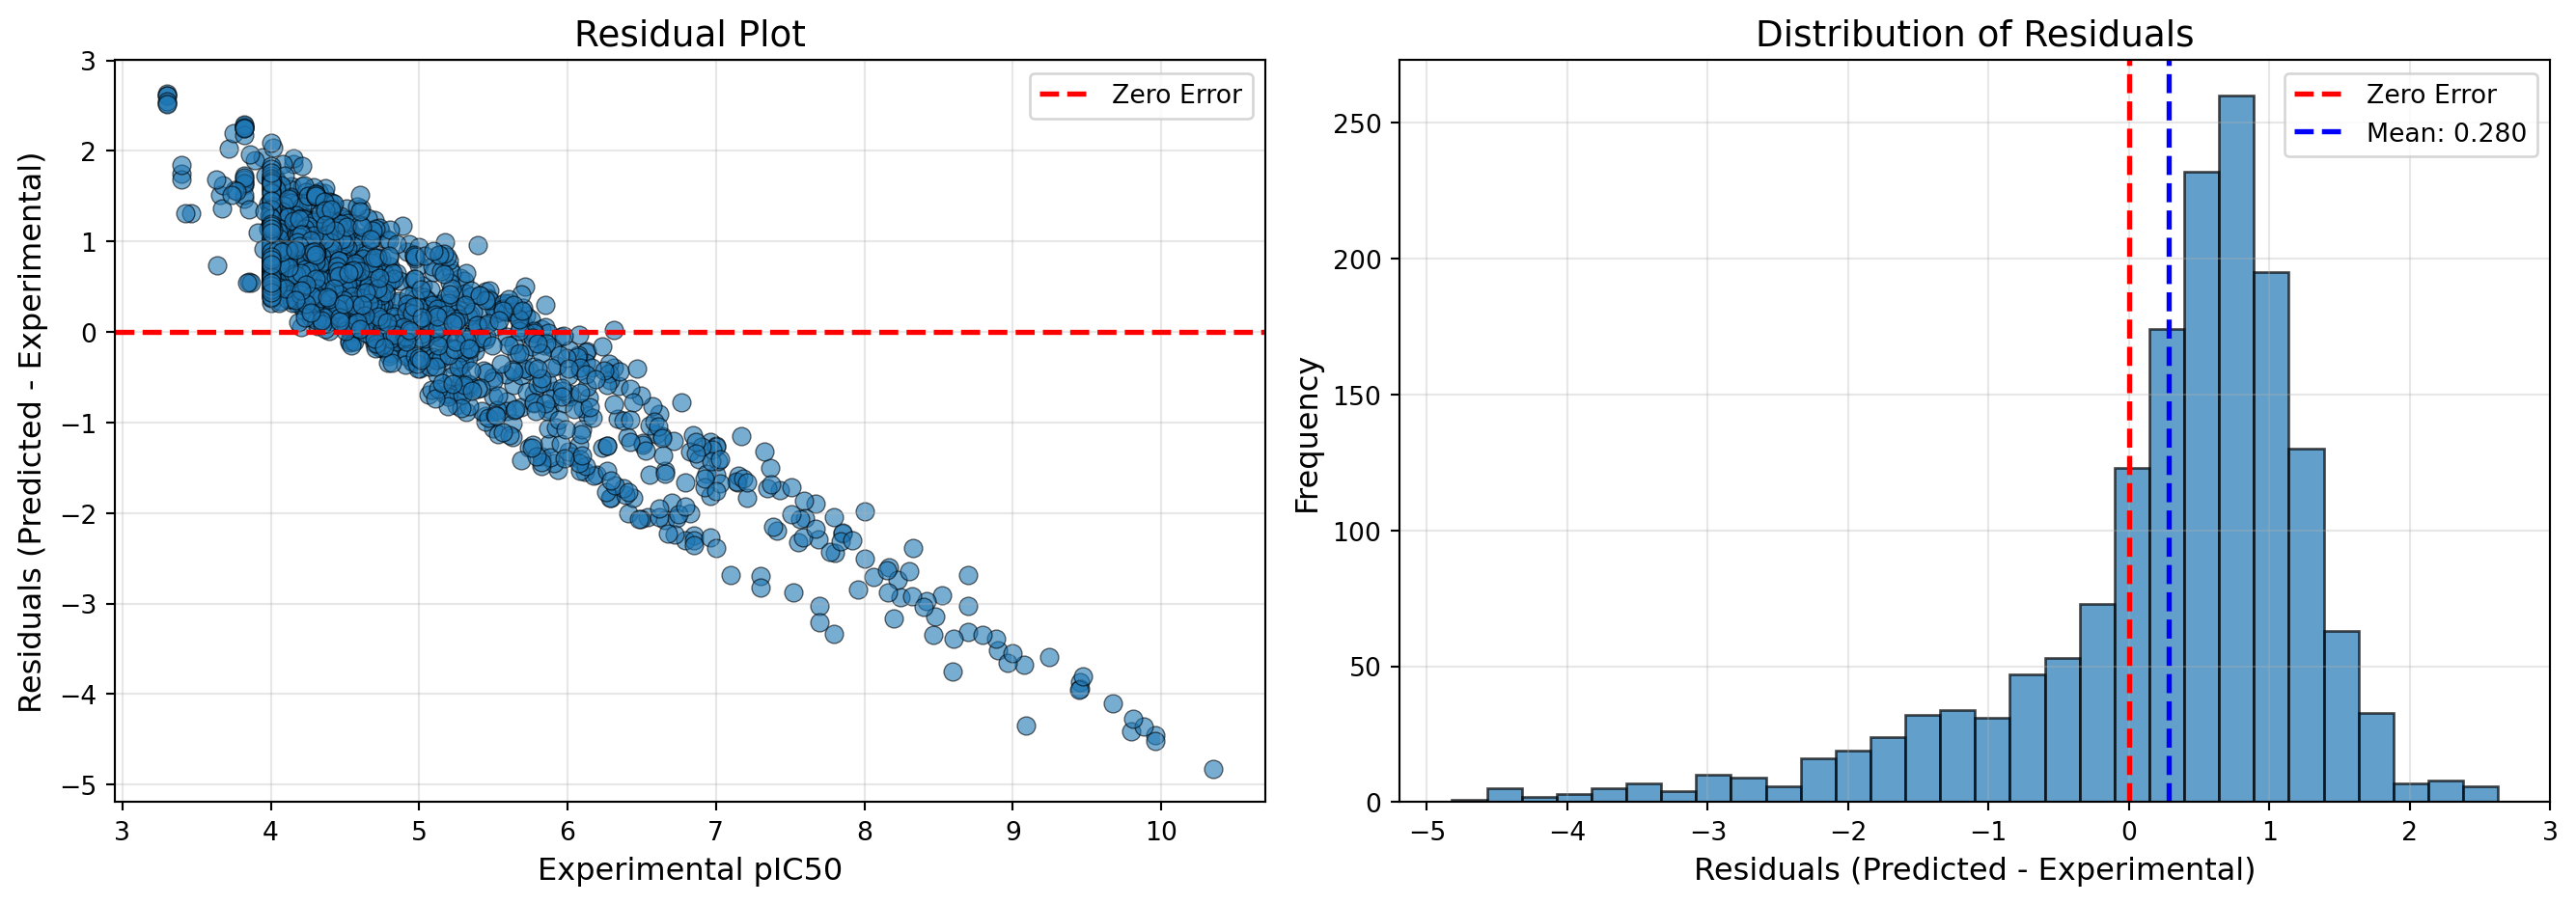

In [210]:
# Calculate residuals (difference)
SMACCAntiviralsData_predicted['residuals'] = (
    SMACCAntiviralsData_predicted['pPotency_prediction'] - 
    SMACCAntiviralsData_predicted['pIC50_experimental']
)

# Print statistics
print(f"Mean Residual: {SMACCAntiviralsData_predicted['residuals'].mean():.3f}")
print(f"Std Dev of Residuals: {SMACCAntiviralsData_predicted['residuals'].std():.3f}")
print(f"Min Residual: {SMACCAntiviralsData_predicted['residuals'].min():.3f}")
print(f"Max Residual: {SMACCAntiviralsData_predicted['residuals'].max():.3f}")

# Create residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Experimental values
axes[0].scatter(SMACCAntiviralsData_predicted['pIC50_experimental'], 
                SMACCAntiviralsData_predicted['residuals'], 
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_xlabel('Experimental pIC50', fontsize=12)
axes[0].set_ylabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution of residuals
axes[1].hist(SMACCAntiviralsData_predicted['residuals'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(x=SMACCAntiviralsData_predicted['residuals'].mean(), 
                color='blue', linestyle='--', linewidth=2, 
                label=f'Mean: {SMACCAntiviralsData_predicted["residuals"].mean():.3f}')
axes[1].set_xlabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Residual Plot Analysis

In [211]:
print(f"Mean residual: {SMACCAntiviralsData_predicted['residuals'].mean():.3f} (Close to 0 indicates no systematic bias)")
print(f"Std deviation: {SMACCAntiviralsData_predicted['residuals'].std():.3f} (typical prediction error)")
print(f"95% of predictions are within ±{1.96 * SMACCAntiviralsData_predicted['residuals'].std():.3f} pIC50 units")

Mean residual: 0.280 (Close to 0 indicates no systematic bias)
Std deviation: 1.072 (typical prediction error)
95% of predictions are within ±2.102 pIC50 units


Let us have a look at the compounds:

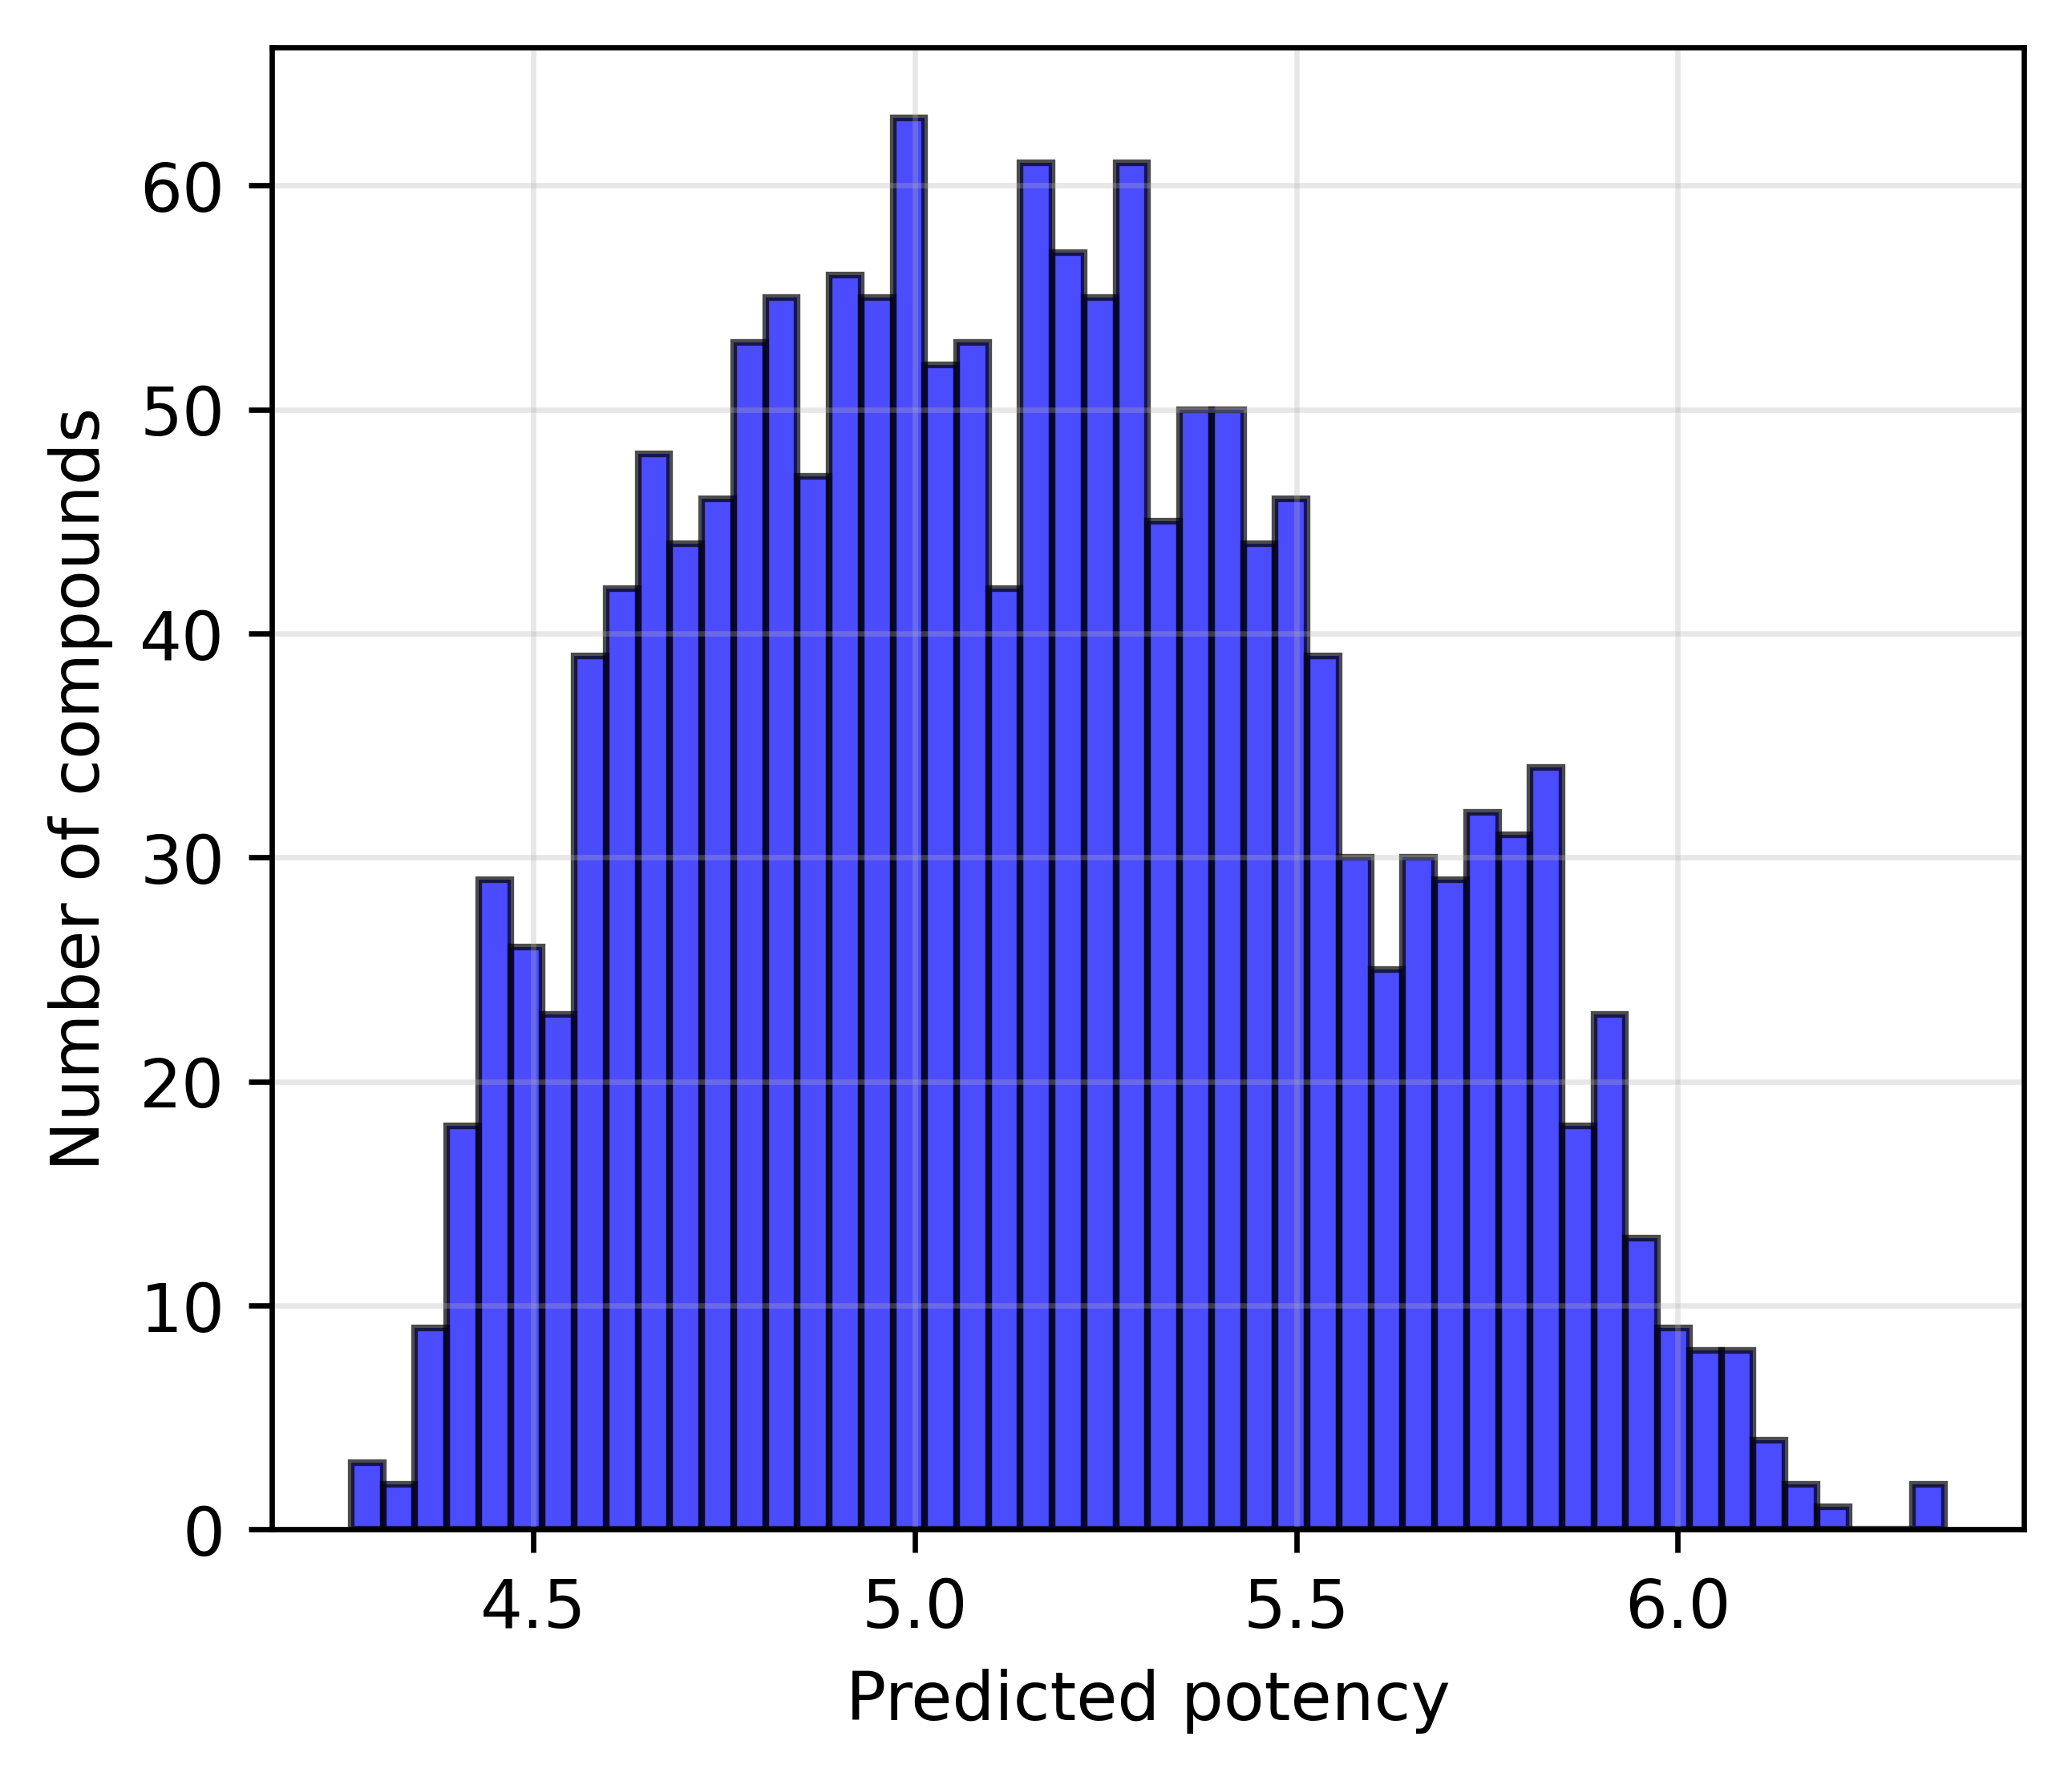

In [212]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_validation_SMACCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_validation_SMACCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

In [213]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 29 compounds
Low priority (5 ≤ pPotency < 6): 943 compounds


### Top 20 compounds with higher pPotency

In [214]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.04
Highest predicted pPotency: 6.35
Range of top 20: 6.04 - 6.35


In [215]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
SMACCAntiviralsData_top20 = SMACCAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
SMACCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
SMACCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
SMACCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'


SMACCAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.041
  IC50:        9.095e-07 M  (909.55 nM)

Best Values (1st ranked compound):
  pPotency:    6.349
  IC50:        4.472e-07 M  (447.20 nM)
Range for Top 20 Compounds:
pPotency Range:  6.041 - 6.349

IC50 Range (M):  9.095e-07 - 4.472e-07


,Rank,SMILES,Virus,pIC50_experimental,pPotency_prediction,IC50(M)_experimental,pPotency(M)_prediction,residuals,IC50 (M)
96,1,CC(C)OC(=O)C(C)NP(=O)(OCC1C(O)C(O)C(n2cnc3c(N)...,Zika,5.394,6.349,4.034e-06,4.472e-07,0.955,4.472e-07
99,2,CC(C)OC(=O)C(C)NP(=O)(OCC1OC(N2C=CC(=O)NC2=O)C...,Zika,6.310,6.330,4.899e-07,4.677e-07,0.020,4.677e-07
98,3,CC(C)OC(=O)C(C)NP(=O)(OCC1OC(N2C=CC(=O)NC2=O)C...,Zika,5.715,6.219,1.926e-06,6.046e-07,0.503,6.046e-07
50,4,CC(=O)OC1CC(C)(C)C(=C=CC(C)=CC=CC=CC=C(C)C=C2O...,Dengue,5.176,6.163,6.671e-06,6.869e-07,0.987,6.869e-07
97,5,CC(C)OC(=O)C(C)NP(=O)(OCC1OC(C(O)C1O)N1C=CC(=O...,Zika,5.849,6.144,1.414e-06,7.182e-07,0.294,7.182e-07
515,6,COC(=O)C1=CC(NC(=O)Nc2cccc(OC)c2)C(NC(C)=O)C(O...,HPIV3,3.824,6.114,1.500e-04,7.696e-07,2.290,7.696e-07
628,7,COc1ccc(C=Cc2cc(OC)c(OC)c(OC)c2)cc1NC(=O)C(CO)...,Dengue,4.602,6.111,2.500e-05,7.747e-07,1.509,7.747e-07
327,8,CCCCCOCc1c(Nc2ccc(cc2)S(N)(=O)=O)nc(nc1C(=O)NC...,Zika,5.690,6.109,2.040e-06,7.778e-07,0.419,7.778e-07
514,9,COC(=O)C1=CC(NC(=O)Nc2ccc3OCOc3c2)C(NC(C)=O)C(...,HPIV3,3.824,6.100,1.500e-04,7.942e-07,2.276,7.942e-07
513,10,COC(=O)C1=CC(NC(=O)Nc2ccc(OC)cc2)C(NC(C)=O)C(O...,HPIV3,3.824,6.089,1.500e-04,8.156e-07,2.265,8.156e-07


In [216]:
SMACCAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_SMACCAntiviralsData_top20.csv"), index=False)
SMACCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_SMACCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_SMACCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_SMACCDataset.svg


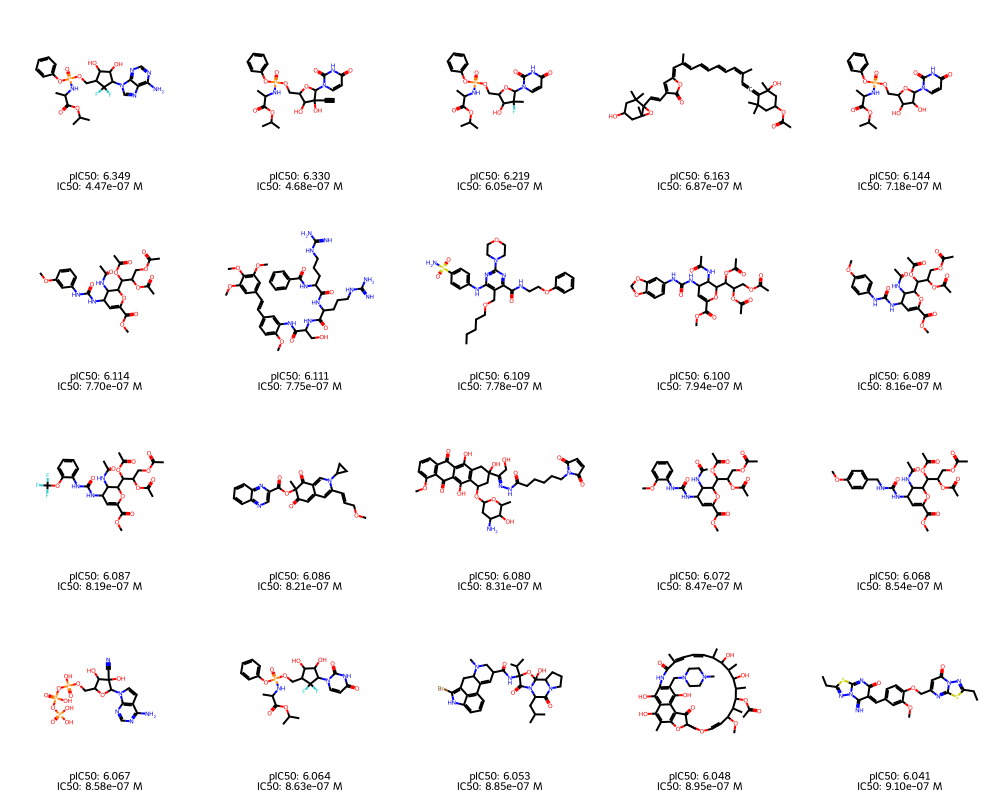

In [217]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'Marburgvirus/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in SMACCAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in SMACCAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'MarburgVirus_predictedCompounds_SMACCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'MarburgVirus_predictedCompounds_SMACCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

# Run the same code by removing duplicate SMILES for `Maburg` virus

In [218]:
MarburgVirusData_chEMBL_wMACAW

,ID,compound_id,Smiles,pPotency,VirusClassifier
14291,1,CHEMBL5593581,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2cccnc2)CC1,4.413,Marburg
14292,2,CHEMBL5593153,CN(C)C1CCN(C(=O)c2cc3occc3n2Cc2ccc(Cl)cc2)CC1,5.099,Marburg
14294,4,CHEMBL5593168,CC(C)N1CCN(C(=O)c2cc3sccc3n2Cc2ccc(Cl)cc2)CC1,4.484,Marburg
14295,5,CHEMBL1236524,Nc1ncnc2c([C@@H]3N[C@H](CO)[C@@H](O)[C@H]3O)c[...,5.523,Marburg
14296,6,CHEMBL5592994,CCN1CCN(CC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)C3...,4.521,Marburg
...,...,...,...,...,...
14489,199,CHEMBL5595280,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCCCC1)C...,3.971,Marburg
14490,200,CHEMBL5592622,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCN(C)CC...,4.322,Marburg
14491,201,CHEMBL1655,CN(C)CCOc1ccc(/C(=C(/CCCl)c2ccccc2)c2ccccc2)cc1,6.155,Marburg
14492,202,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,5.337,Marburg


### Remove duplicate compounds using Compute median potency per (Smiles, Virus) pair

In [219]:
# Print shape before removing duplicates
print("Before removing duplicates:", MarburgVirusData_chEMBL_wMACAW.shape)

# Aggregate duplicates *within the same Virus*
aggDF = (
    MarburgVirusData_chEMBL_wMACAW.groupby(['Smiles', 'VirusClassifier'], as_index=False)
      .agg({'pPotency': 'median'})   # or 'mean' if you prefer
)

# Merge back non-target columns (like MACAW features)
MarburgVirusData_chEMBL_wMACAW_noDuplicates = (aggDF
      .merge(
          aggDF.drop(columns=['pPotency']),
          on=['Smiles', 'VirusClassifier'],
          how='left'
      )
      .drop_duplicates(subset=['Smiles', 'VirusClassifier'])
      .reset_index(drop=True)
)

# Print shape after removing duplicates
print("After removing duplicates:", MarburgVirusData_chEMBL_wMACAW_noDuplicates.shape)

Before removing duplicates: (186, 5)
After removing duplicates: (152, 3)


In [220]:
duplicates = MarburgVirusData_chEMBL_wMACAW_noDuplicates.duplicated(subset=['Smiles', 'VirusClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 0


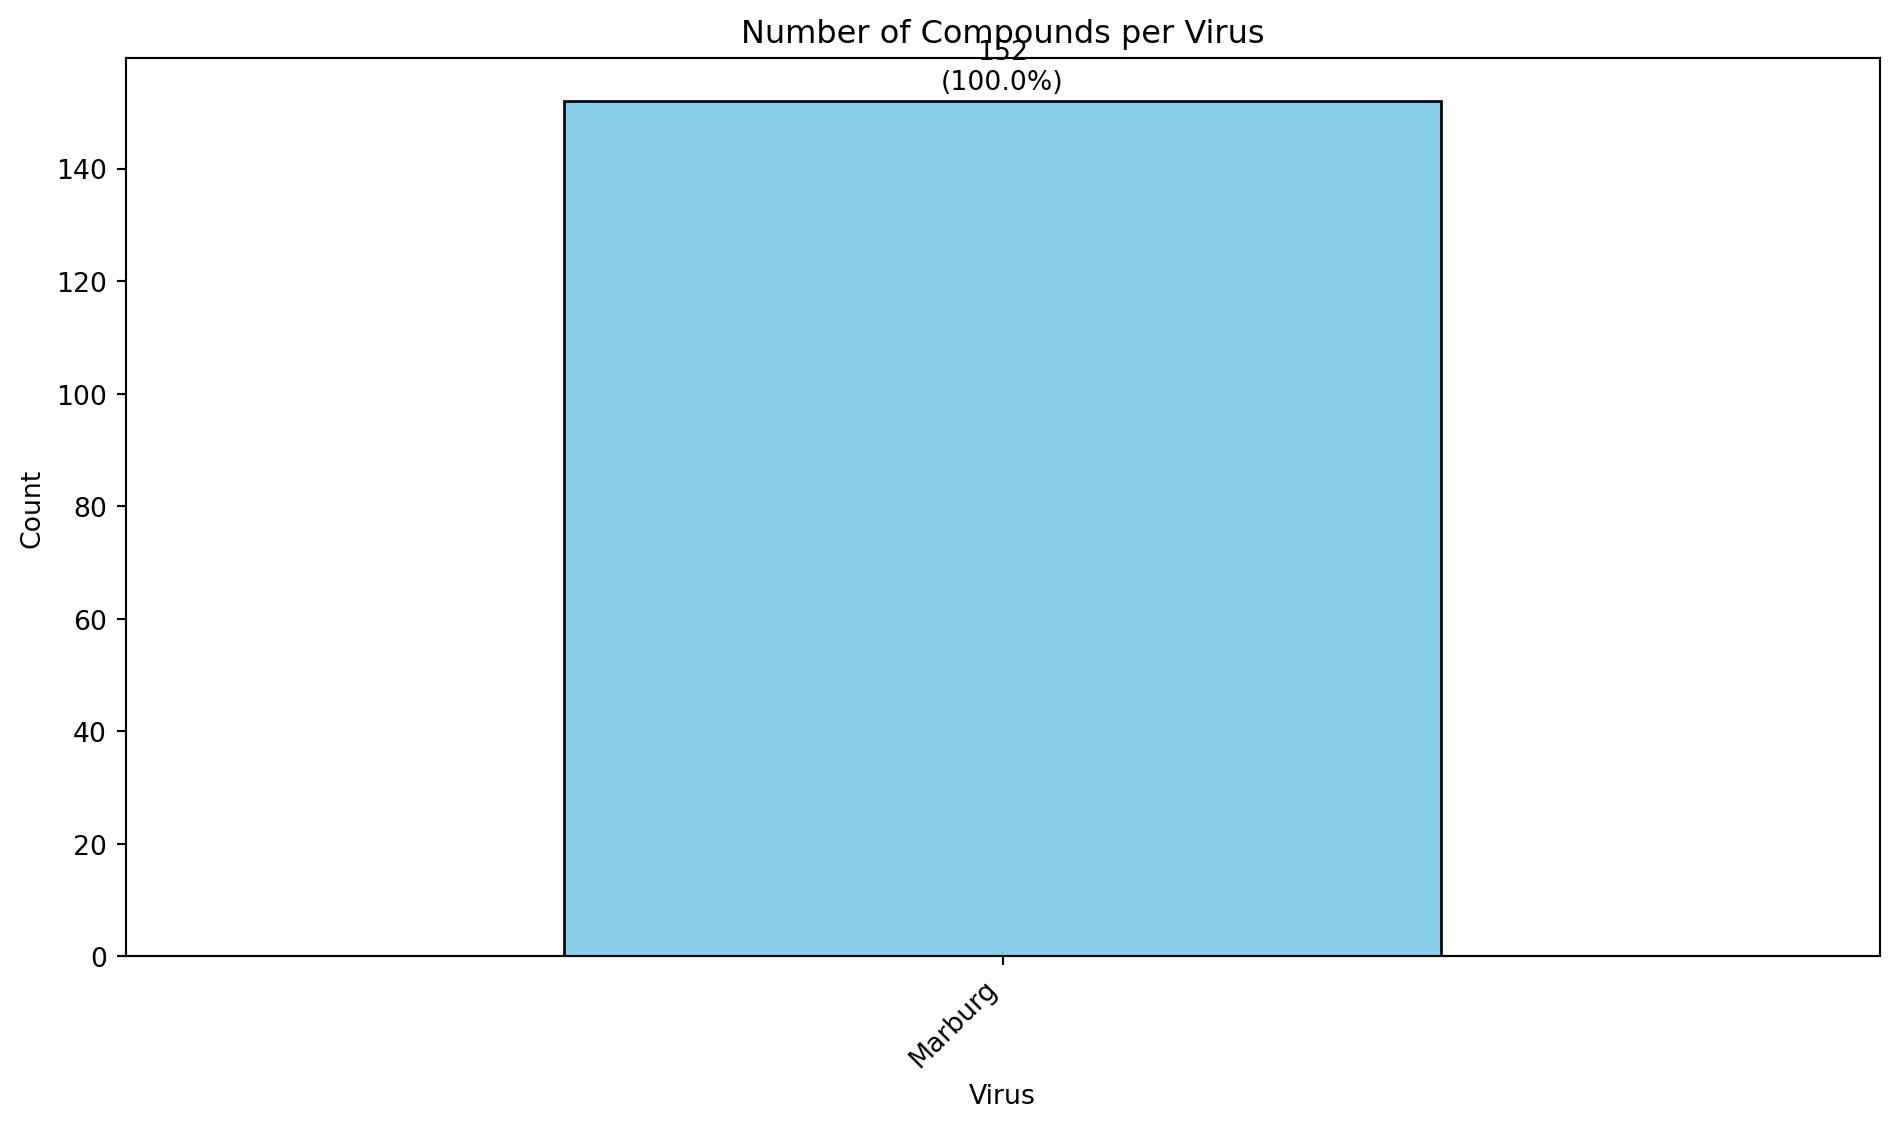

In [221]:
# Get counts and percentages
counts = MarburgVirusData_chEMBL_wMACAW_noDuplicates['VirusClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [222]:
MarburgVirusData_chEMBL_wMACAW_noDuplicates.to_csv(os.path.join(modelBuildingDataDir, "MarburgVirusData_chEMBL_wMACAW_noDuplicates_MLready.csv"), index=False)

### pPotency value distribution across each Virus

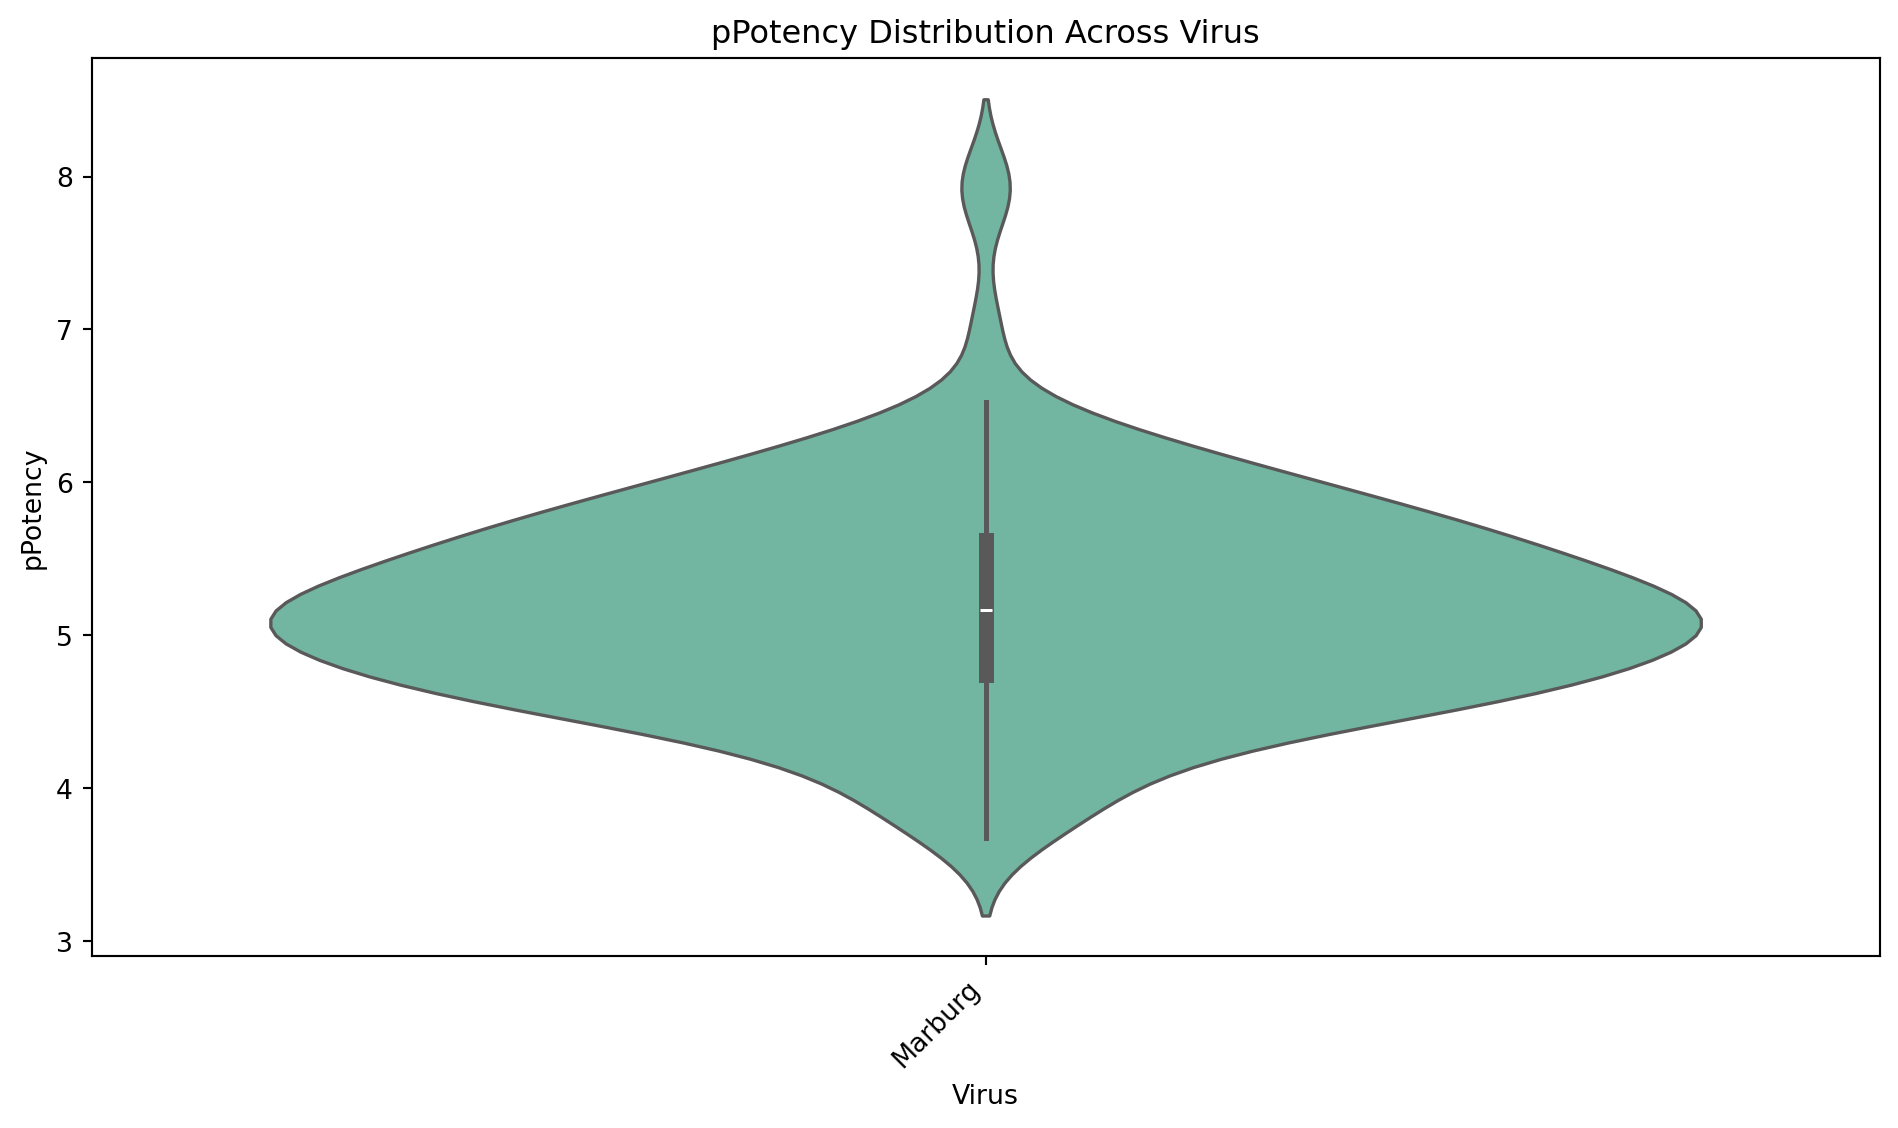

In [223]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=MarburgVirusData_chEMBL_wMACAW_noDuplicates,
    x='VirusClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

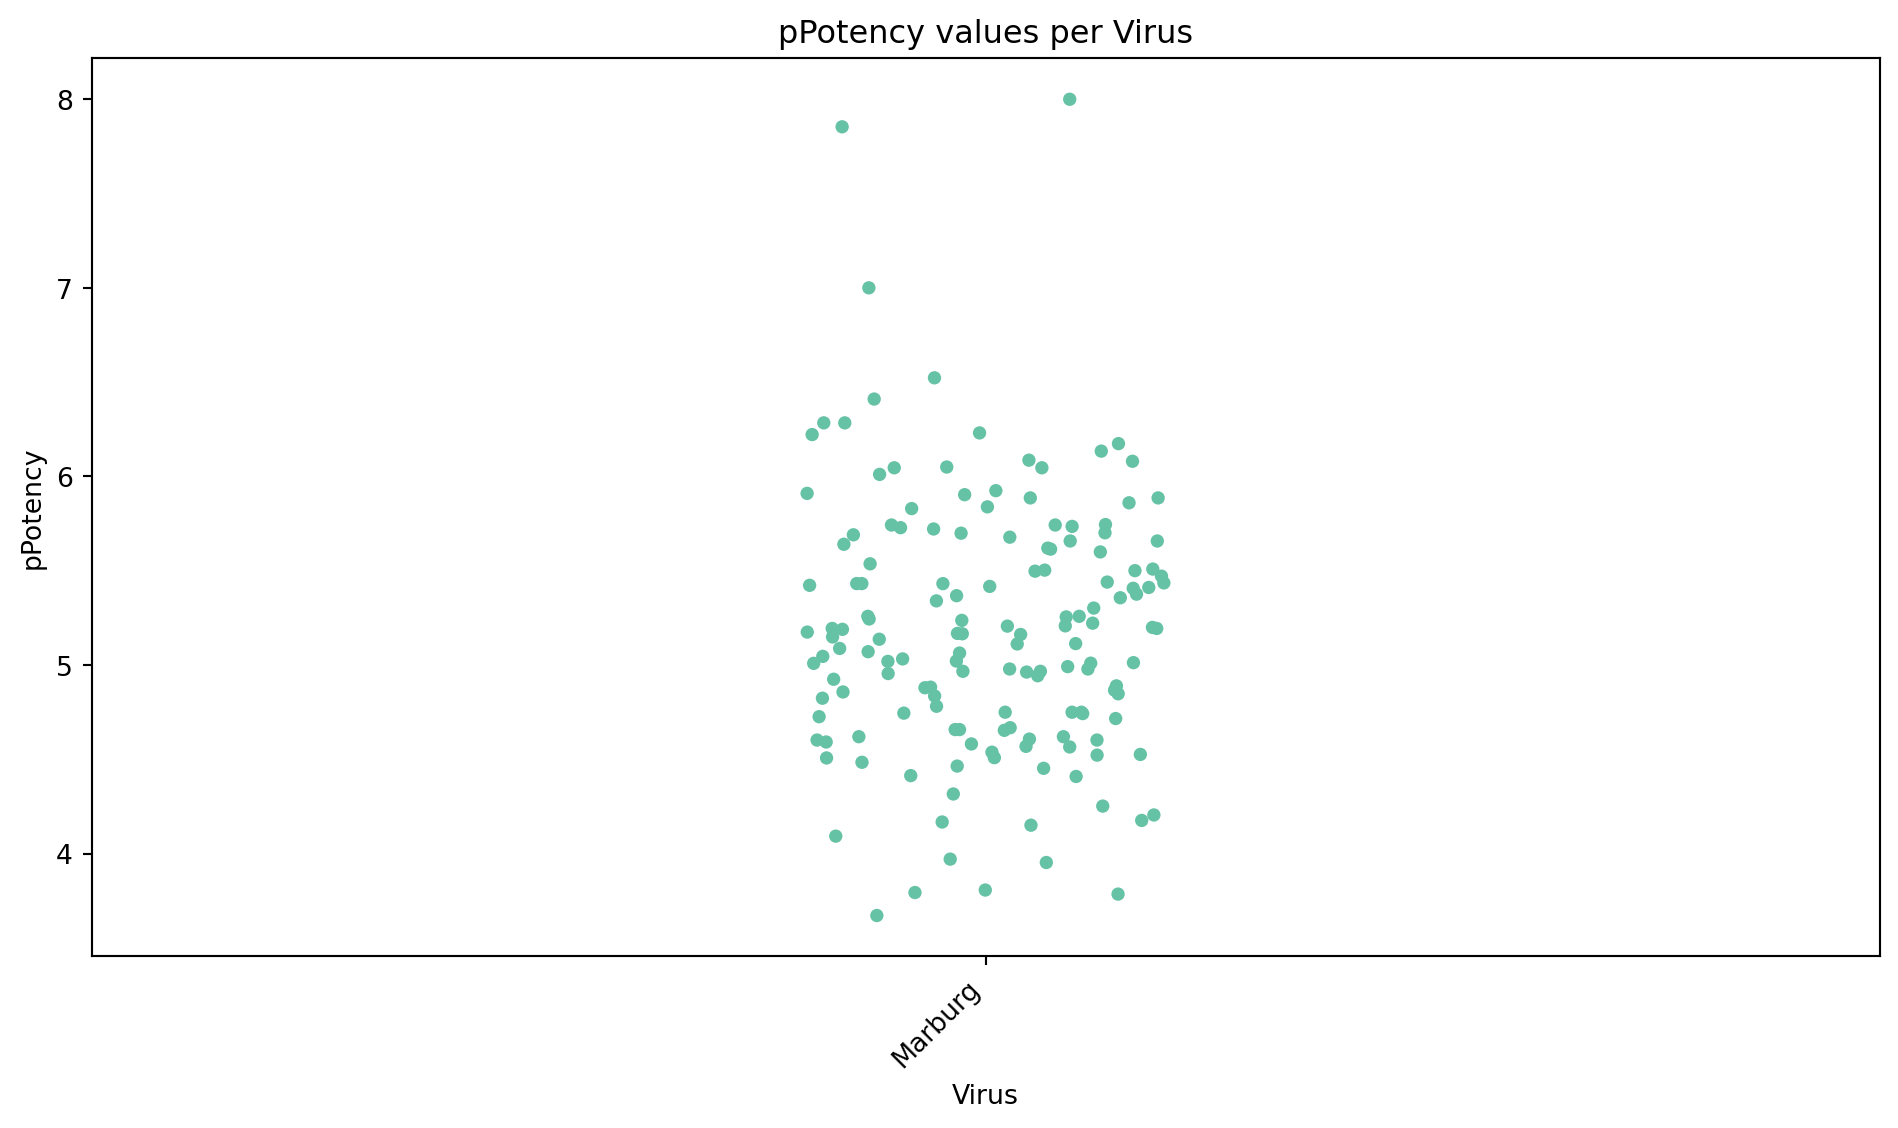

In [224]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=MarburgVirusData_chEMBL_wMACAW_noDuplicates,
    x='VirusClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [225]:
# df = MarburgVirusData_chEMBL_wMACAW_noDuplicates
Y = MarburgVirusData_chEMBL_wMACAW_noDuplicates.pPotency
smiles = MarburgVirusData_chEMBL_wMACAW_noDuplicates.Smiles

In [226]:
print(len(smiles))

152


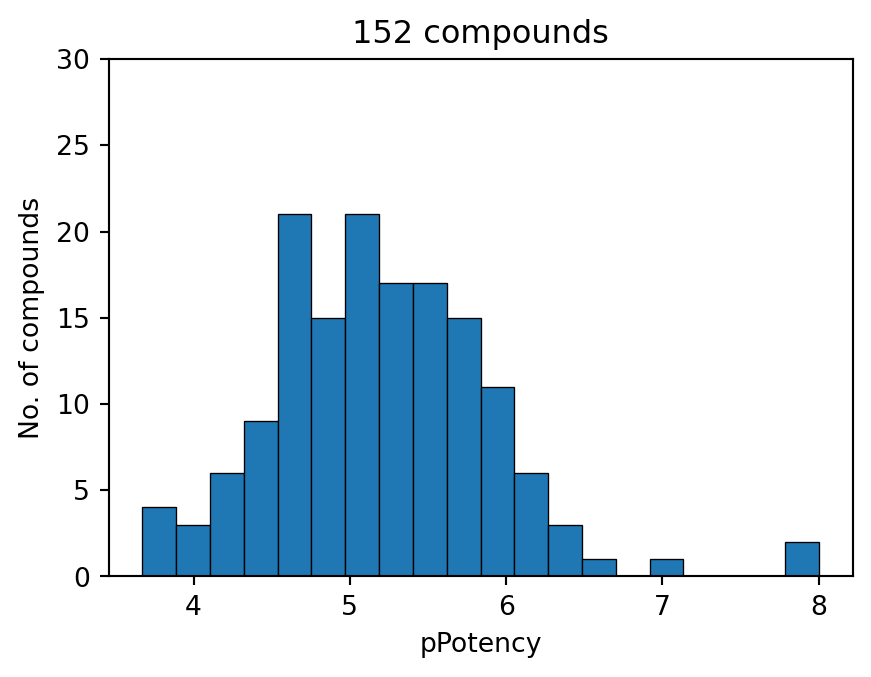

In [227]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [228]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [229]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [230]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [231]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 152 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results

In [232]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.26
  RMSE: 0.37
  R²:   0.71
Test Set:
  MAE:  0.35
  RMSE: 0.50
  R²:   0.47

Best params (sample): [{'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}]
CPU times: user 89.6 ms, sys: 47.3 ms, total: 137 ms
Wall time: 2.34 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_noDuplicates_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_noDuplicates_CV_TrTs.png


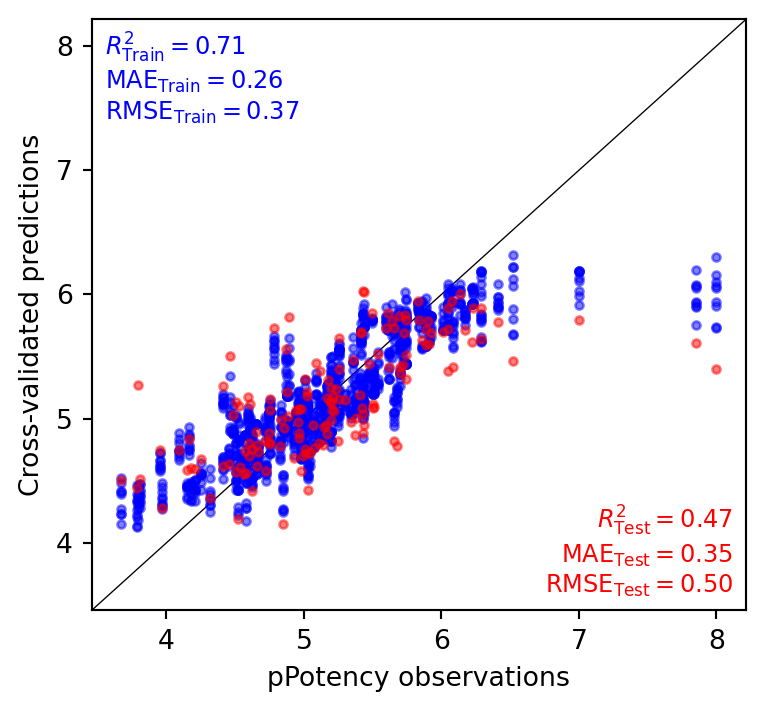

In [233]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'Marburgvirus/MarburgVirus_noDuplicates_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [234]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=39
)
mcw.fit(smiles, Y)

In [235]:
X_all = mcw.transform(smiles)
X_all.shape

(152, 15)

Training samples: 121
Test samples: 31
Feature dimensions: 15

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 1
  epsilon: 0.1
  kernel: rbf

Best CV MAE (on training folds): 0.36

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.73            0.37            0.36           
MAE        0.23            0.42            0.19           
RMSE       0.34            0.59            0.25           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_noDuplicates_fullData_TrTs.svg
Saved: /mnt/data.ese/nfs/us

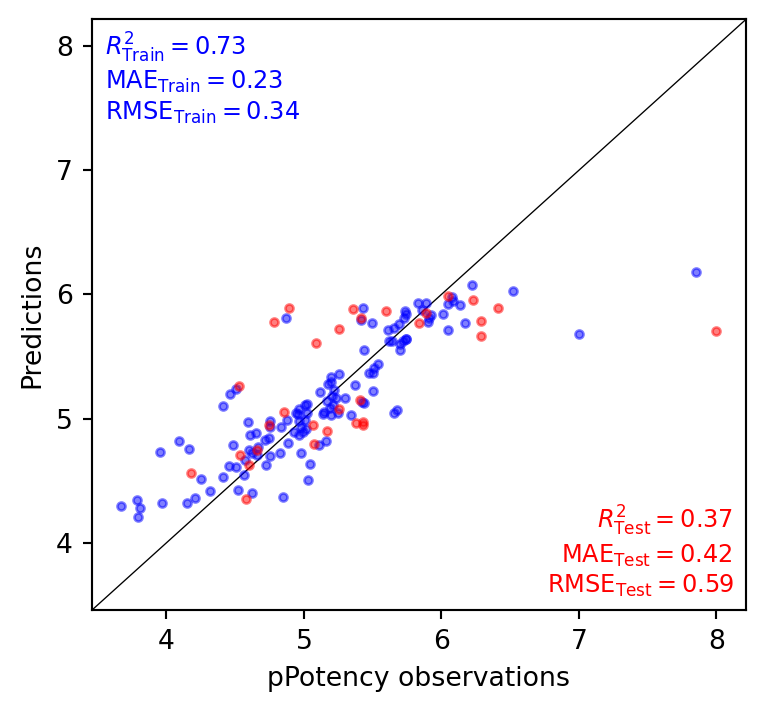

CPU times: user 917 ms, sys: 72.1 ms, total: 989 ms
Wall time: 1.02 s


In [236]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=39
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)

# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=resultsDir + 'Marburgvirus/MarburgVirus_noDuplicates_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

### Compare performance of different ML model

- SVR
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Neural Network

Import all necessary libraries

## 2.1 Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [237]:
EnamineAntiviralsData = pd.read_csv(dataDir + "Enamine/Enamine_Antiviral_Library_plated_3200cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                    skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntiviralsData.shape}")

smiles_train = MarburgVirusData_chEMBL_wMACAW.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntiviralsData['Canonical_SMILES'] = EnamineAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntiviralsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntiviralsData_filtered = EnamineAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntiviralsData = EnamineAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntiviralsData.shape}")
print(f"Removed {EnamineAntiviralsData.shape[0] - EnamineAntiviralsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib = EnamineAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
EnamineAntiviralsData.head()

Original Enamine data shape: (3200, 11)
Number of unique SMILES in training set: 152
Filtered Enamine data shape for validation: (3200, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 3200


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,Z410227912,256.326,256.326,1.231,-2.190,2,4,76.140,5,https://real.enamine.net/public-enum-files/Z41...
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,Z383167688,237.256,237.256,-0.042,-0.692,1,3,69.720,5,https://real.enamine.net/public-enum-files/Z38...
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,Z235579208,306.404,306.404,1.583,-2.082,1,5,57.700,7,NaN
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,Z403694008,279.379,279.379,1.156,-0.660,1,3,58.370,7,https://real.enamine.net/public-enum-files/Z40...
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,Z384461492,307.389,307.389,1.084,-1.180,1,4,61.880,7,https://real.enamine.net/public-enum-files/Z38...


Generate predictions

In [238]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [239]:
EnamineAntiviralsData_predicted = EnamineAntiviralsData.copy()
EnamineAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
EnamineAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-EnamineAntiviralsData_predicted['pPotency_prediction'])

EnamineAntiviralsData_predicted = EnamineAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
EnamineAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_EnamineDatasets_predicted_all.csv"), index=False)
EnamineAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_EnamineDatasets_predicted_all_SMILES.csv"), index=False)
EnamineAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,5.325,4.727e-06
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,5.185,6.525e-06
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,5.101,7.930e-06
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,5.239,5.765e-06
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,5.141,7.221e-06
...,...,...,...
3195,CCOC=1N=CC=CC1NC(=O)NC2CCN3CCCCC23,5.320,4.786e-06
3196,CC1=NN(CC(O)C=2C=CC=CC2)C(=O)C(C#N)=C1C,5.496,3.188e-06
3197,CCC1=NN=NN1CC(=O)NC2CCN(CC2)C(C)=O,5.129,7.422e-06
3198,CC=1C=C2N=CN(CC(O)CN3CCS(=O)CC3)C2=CC1C,5.319,4.793e-06


Let us represent the predictions of both models:

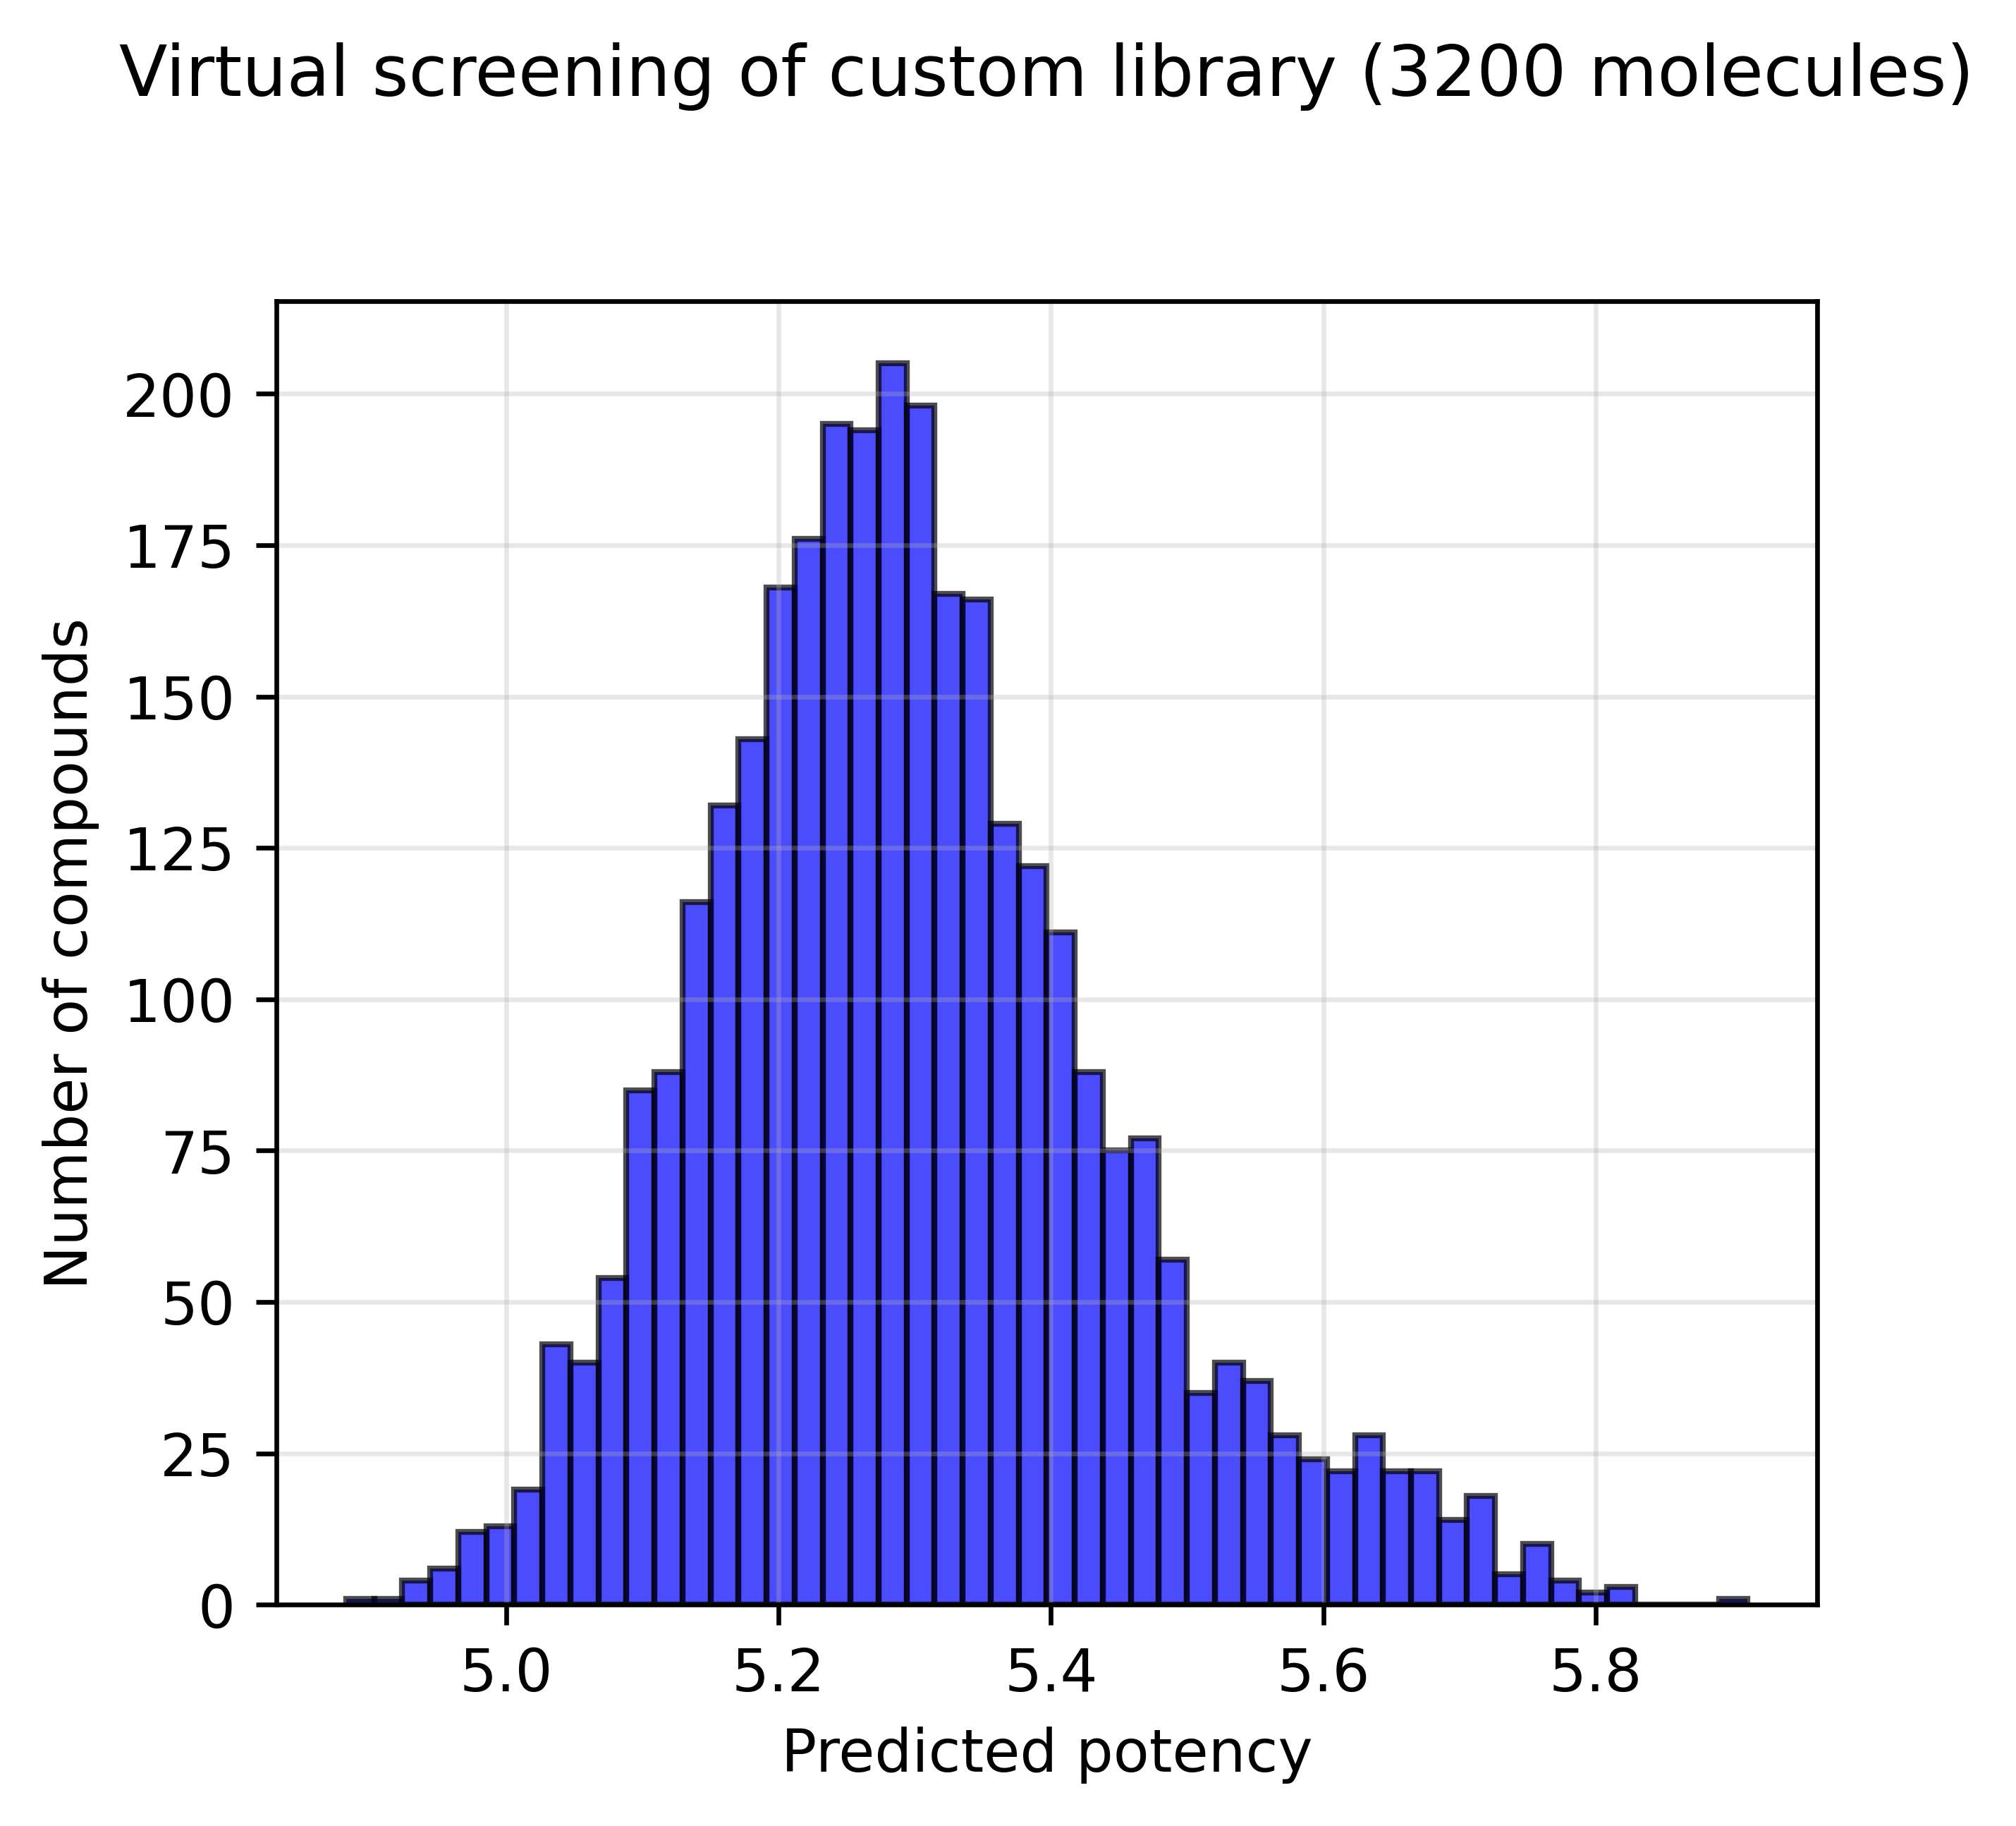

In [240]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_noDuplicates_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_noDuplicates_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [241]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 3164 compounds


In [242]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,pPotency_prediction


### Top 20 compounds with higher pPotency

In [243]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 5.75
Highest predicted pPotency: 5.91
Range of top 20: 5.75 - 5.91


In [244]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntiviralsData_top20 = EnamineAntiviralsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntiviralsData_top20 = EnamineAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    5.748
  IC50:        1.788e-06 M  (1788.44 nM)

Best Values (1st ranked compound):
  pPotency:    5.911
  IC50:        1.227e-06 M  (1226.99 nM)
Range for Top 20 Compounds:
pPotency Range:  5.748 - 5.911

IC50 Range (M):  1.788e-06 - 1.227e-06


,Rank,SMILES,pPotency_prediction,IC50 (M)
2636,1,CC(=O)NC=1C=CC(=CC1)OCC(O)CN2C(C)=NC=3C=CC=CC32,5.911,1.227e-06
2530,2,CC(=O)N[C@@H](C)C1=NC=2C=CC=CC2N1CC(O)C3=CC=CC...,5.817,1.523e-06
2485,3,CCC(=O)C=1C=CC(=CC1)OCC(O)CN2C=NC3=CC=CC=C32,5.815,1.531e-06
1043,4,CCN1C(=O)N(CC(O)COC=2C=CC(C#N)=CC2)C=3C=CC=CC31,5.812,1.540e-06
1297,5,CC(=O)C=1C=CC(=CC1)OCC(O)CN2C(C)=NC=3C=CC=CC32,5.799,1.587e-06
2618,6,CC(=O)NC(C)C1=NC=2C=CC=CC2N1CC(O)C=3C=CC=CC3,5.799,1.587e-06
2744,7,COC=1C=CC(OC)=C(C1)C(O)CN2C(C)=NC=3C=CC=CC32,5.787,1.634e-06
1355,8,CC1=NC=2C=CC=CC2N1CC(O)C=3C=CC(=CC3)OC(F)F,5.776,1.673e-06
2880,9,COC=1C=C(C=CC1OCC(O)CN2C=NC=3C=CC=CC32)C(C)=O,5.773,1.687e-06
2030,10,COC=1C=CC(OC)=C(C1)C(O)CN2C(=O)N(C)C=3C=CC=CC32,5.768,1.707e-06


In [245]:
EnamineAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_EnamineAntiviralsData_top20.csv"), index=False)
EnamineAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_EnamineAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_noDuplicates_predictedCompounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_noDuplicates_predictedCompounds.svg


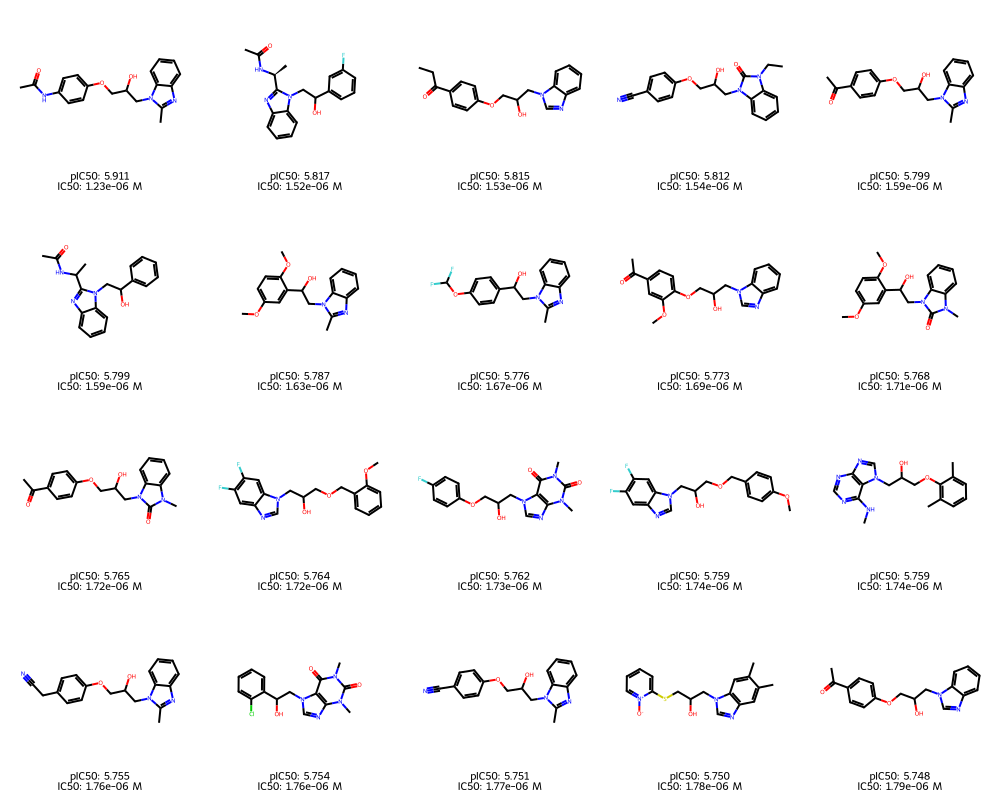

In [246]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'Marburgvirus/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'MarburgVirus_noDuplicates_predictedCompounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'MarburgVirus_noDuplicates_predictedCompounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

## 2.2 Discovery of new hits specific to all viruses (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [247]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Merged_Antiviral_Screening_Superset.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntiviralsData_superset = pd.DataFrame(records)
print(f"Original LifeChemicals data shape: {LCAntiviralsData_superset.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntiviralsData_superset['Canonical_SMILES'] = LCAntiviralsData_superset['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntiviralsData_superset['Canonical_SMILES'].isin(canonical_train)
LCAntiviralsData_superset_filtered = LCAntiviralsData_superset[mask].copy()

# Remove the helper column if you don't need it
LCAntiviralsData_superset = LCAntiviralsData_superset_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntiviralsData_superset.shape}")
print(f"Removed {LCAntiviralsData_superset_filtered.shape[0] - LCAntiviralsData_superset.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib = LCAntiviralsData_superset.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
LCAntiviralsData_superset.head()

Original LifeChemicals data shape: (45573, 17)
Number of unique SMILES in training set: 152
Filtered LifeChemicals data shape for validation: (45573, 17)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 45573


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,Acceptor,Donor,RotBonds,HAC,Collection,Library,PPDS,SMILES
0,F6544-0534,"11-(oxan-4-yl)-7,11-diazatricyclo[7.3.1.0²,⁷]t...",2034607-75-3,1.500,274.360,solid,0.690,-0.120,32.780,2,1,1,20.000,Advanced,Anti-Hepatitis_A_B_ Screening_Library,,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1
1,F6559-5304,6-[4-(trifluoromethyl)pyrimidin-2-yl]-6-azaspi...,2034225-11-9,1.500,301.260,solid,0.620,2.030,66.320,4,1,2,21.000,Advanced,2019-nCoV_Main_Protease_Targeted_Library,+,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2
2,F6610-6619,"1-methyl-4-[(pyridin-4-yl)methyl]-1,4-diazepane",2320860-02-2,1.000,205.300,oil,0.580,0.890,19.370,3,3,2,15.000,General,Anti-HIV_Focused_Library,,CN1CCCN(Cc2ccncc2)CC1
3,F6559-5274,"6-(4,6-dimethylpyrimidin-2-yl)-6-azaspiro[3.4]...",2034225-08-4,1.500,261.320,oil,0.640,2.090,66.320,4,1,2,19.000,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1
4,F1912-1536,N-cyclopropyl-N-(piperidin-4-yl)pyrimidin-4-amine,1781768-10-2,1.500,218.290,solid,0.670,0.790,41.050,2,2,3,16.000,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,c1cc(N(C2CCNCC2)C2CC2)ncn1


Generate predictions for the H1 receptor:

In [248]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [249]:
LCAntiviralsData_predicted = LCAntiviralsData_superset.copy()
LCAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
LCAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-LCAntiviralsData_predicted['pPotency_prediction'])

LCAntiviralsData_predicted = LCAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
LCAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_LCDatasets_predicted_all.csv"), index=False)
LCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_LCDatasets_predicted_all_SMILES.csv"), index=False)
LCAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1,4.944,1.137e-05
1,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2,5.294,5.084e-06
2,CN1CCCN(Cc2ccncc2)CC1,5.058,8.754e-06
3,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1,5.229,5.907e-06
4,c1cc(N(C2CCNCC2)C2CC2)ncn1,5.115,7.676e-06
...,...,...,...
45568,CCN1C=C/C(=C\C=C\c2cc[n+](CC)c3ccccc23)c2ccccc...,5.758,1.744e-06
45569,CCCN1/C(=C/C=C/c2sc3ccccc3[n+]2CCC)Sc2ccccc21....,5.588,2.582e-06
45570,COC(=O)c1ccccc1-c1c2ccc(=N)cc-2oc2cc(N)ccc12.Cl,5.611,2.451e-06
45571,CCN1/C(=C/C=C2\CCC(/C=C/c3sc4ccc(Cl)cc4[n+]3CC...,5.939,1.150e-06


Let us represent the predictions of both models:

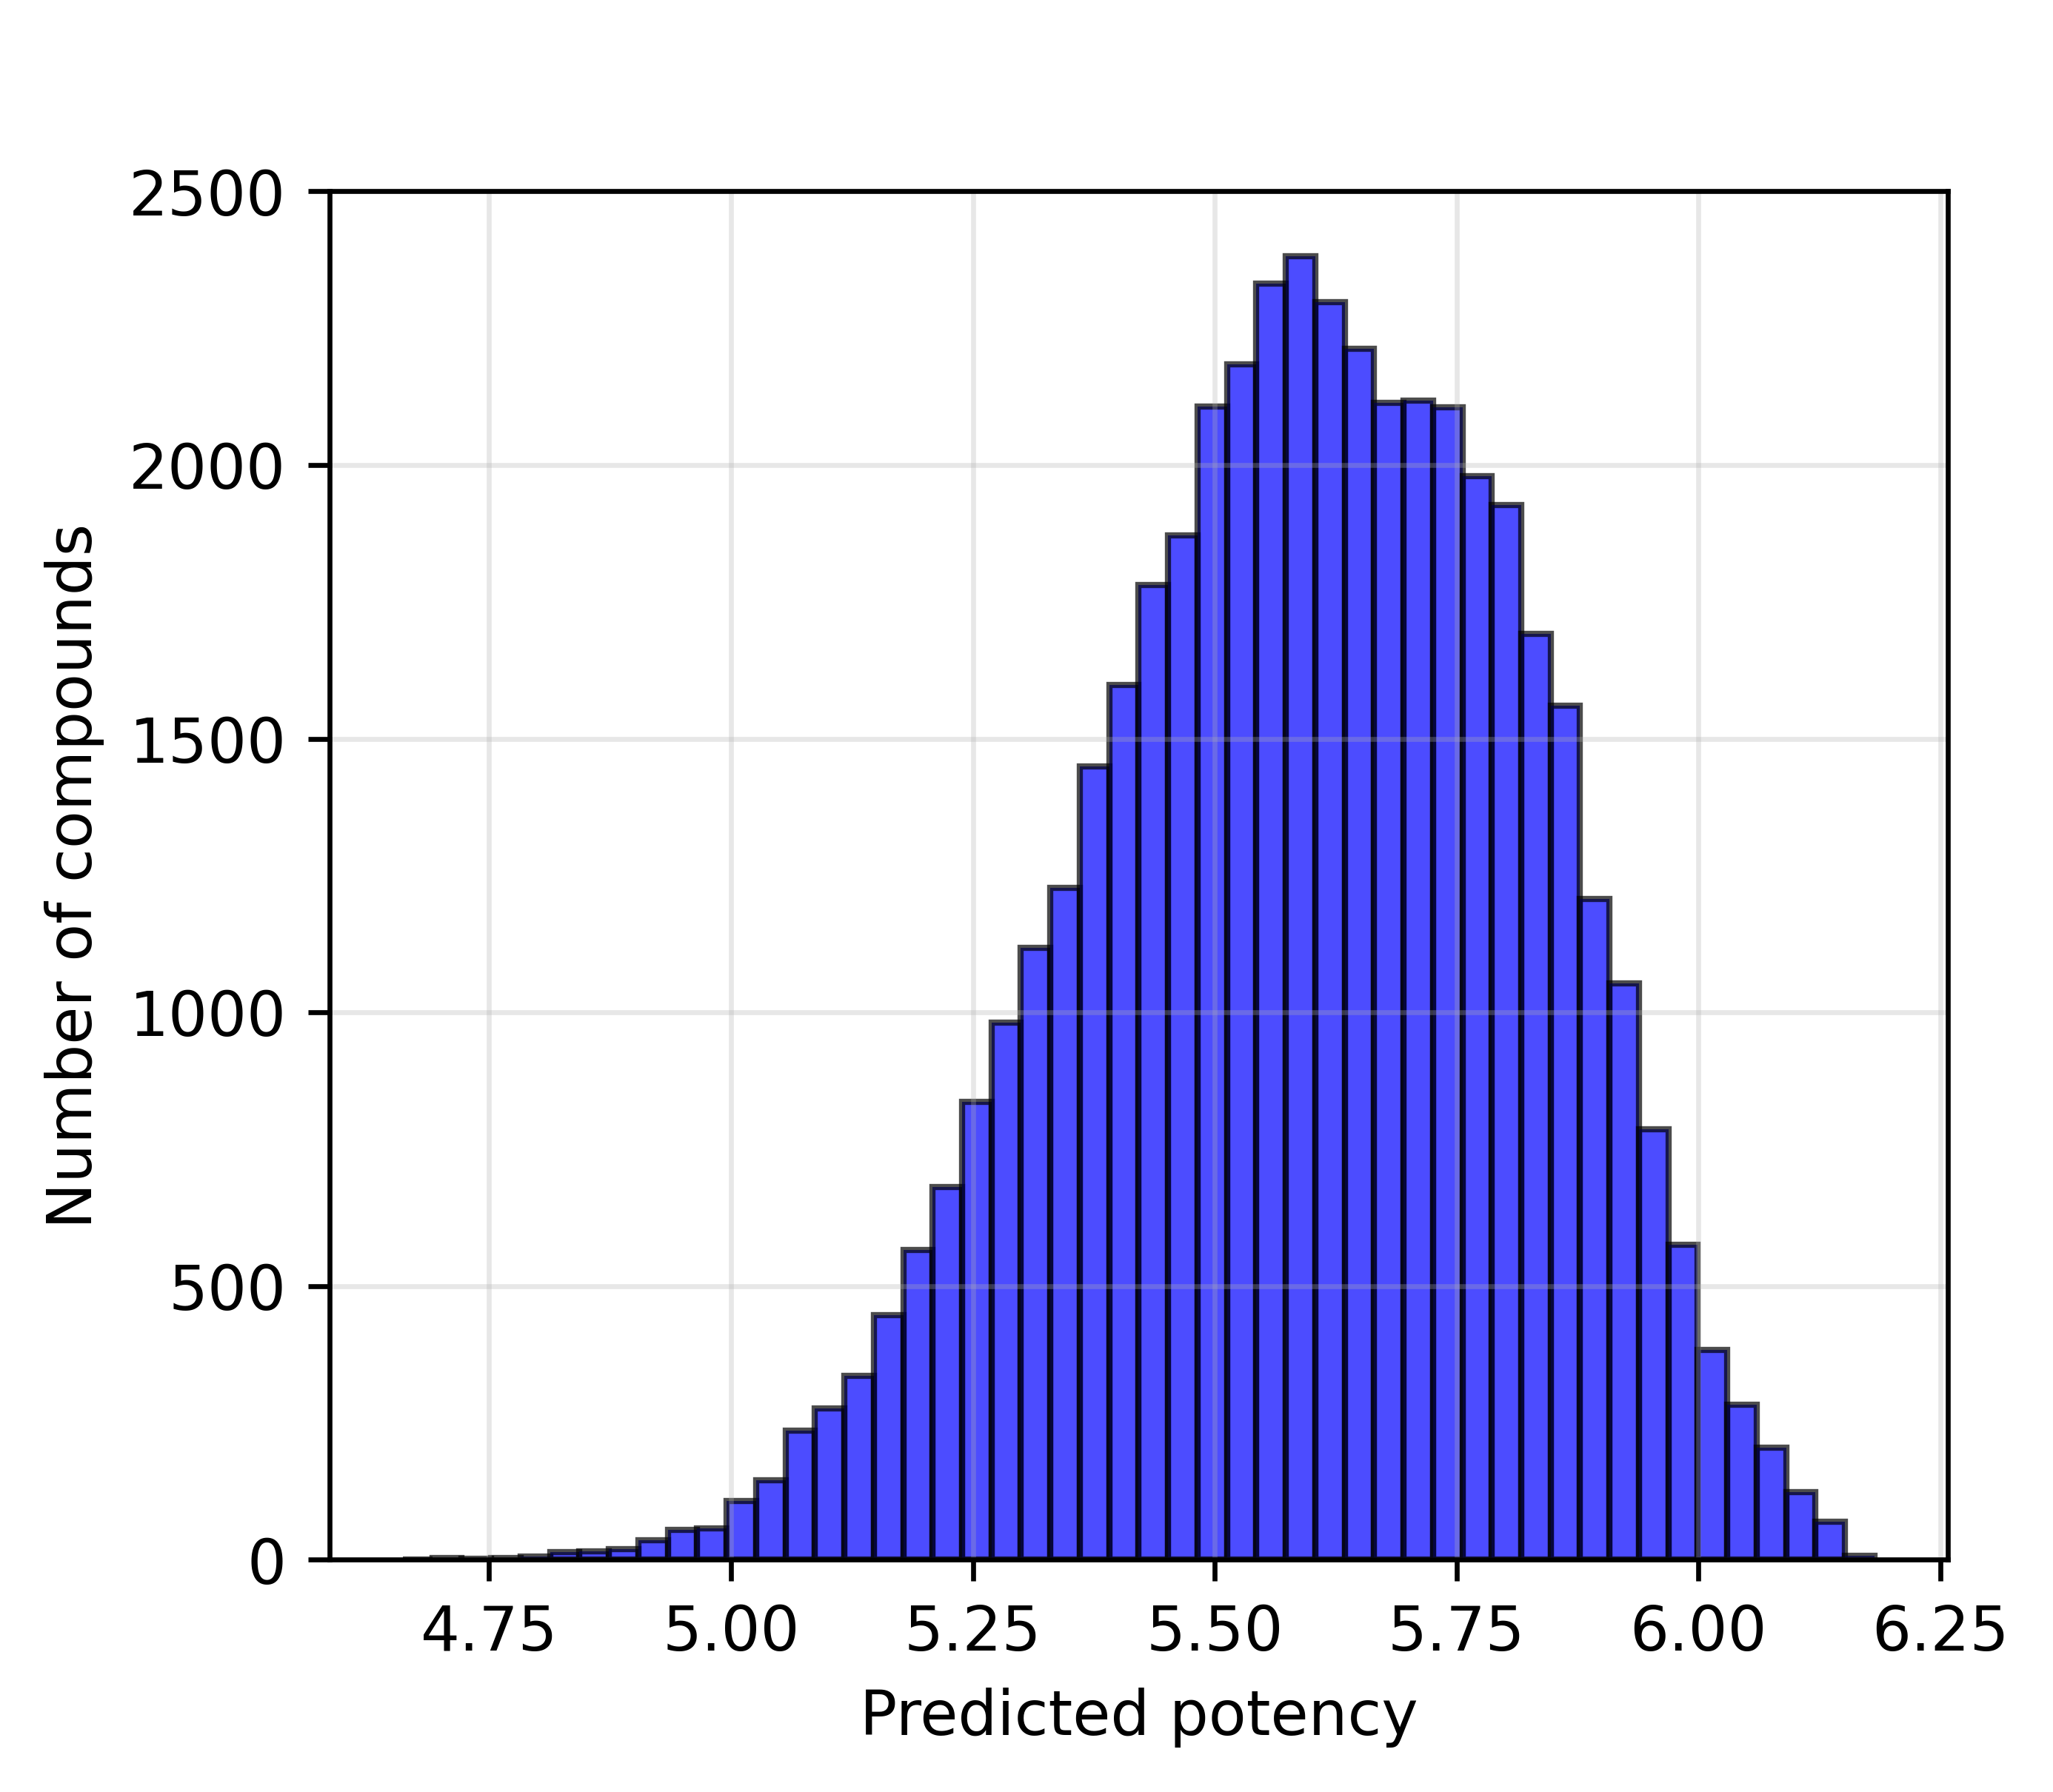

In [250]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_validation_noDuplicates_LCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_validation_noDuplicates_LCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [251]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 1060 compounds
Low priority (5 ≤ pPotency < 6): 44284 compounds


In [252]:
LCAntiviralsData_superset_final = LCAntiviralsData_superset.iloc[idx].copy()
LCAntiviralsData_superset_final['pPotency_prediction'] = Y1_lib_pred[idx]
LCAntiviralsData_superset_final = LCAntiviralsData_superset_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
LCAntiviralsData_superset_final

,SMILES,pPotency_prediction,clogP


### Top 20 compounds with higher PpPotency

In [253]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.14
Highest predicted pPotency: 6.18
Range of top 20: 6.14 - 6.18


In [254]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntiviralsData_top20 = LCAntiviralsData_superset.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntiviralsData_top20 = LCAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.143
  IC50:        7.201e-07 M  (720.13 nM)

Best Values (1st ranked compound):
  pPotency:    6.182
  IC50:        6.581e-07 M  (658.11 nM)
Range for Top 20 Compounds:
pPotency Range:  6.143 - 6.182

IC50 Range (M):  7.201e-07 - 6.581e-07


,Rank,SMILES,pPotency_prediction,IC50 (M)
40972,1,CCOc1ccc(-n2c(SCC(=O)Nc3ccc(CC)cc3)nnc2-c2c[nH...,6.182,6.581e-07
43774,2,CCOC(=O)c1ccc(NC(=O)CSc2nnc(CNC(=O)c3ccc(S(=O)...,6.165,6.836e-07
43812,3,CN(C)c1ccc(NC(=O)CSc2nc3cc4c(cc3c(=O)n2Cc2ccc(...,6.162,6.885e-07
43802,4,CCc1ccc(NC(=O)CSc2nc3cc4c(cc3c(=O)n2Cc2ccc(C(=...,6.158,6.946e-07
43071,5,CCOc1ccc(-n2c(CNC(=O)c3ccc(S(=O)(=O)N4CCOCC4)c...,6.157,6.962e-07
42929,6,CCOc1ccc(-n2c(CNC(=O)c3ccc(S(=O)(=O)N4CCCC4)cc...,6.154,7.014e-07
34572,7,CC(C)c1ccc(NC(=O)CSc2nc3ccc(N4CCOCC4)cc3c(=O)n...,6.154,7.020e-07
43842,8,CCCN(CCC)S(=O)(=O)c1ccc(C(=O)Nc2ccccc2C(=O)Nc2...,6.151,7.070e-07
42857,9,CCOc1ccc(-n2c(CNC(=O)c3ccc(S(=O)(=O)N4CCOCC4)c...,6.149,7.096e-07
42832,10,CCOc1ccc(-n2c(SCC(=O)Nc3ccc(CC)cc3)nc3c([nH]c4...,6.147,7.128e-07


In [255]:
LCAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_LCAntiviralsData_top20.csv"), index=False)
LCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_LCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_noDuplicates_LCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_noDuplicates_LCDataset.svg


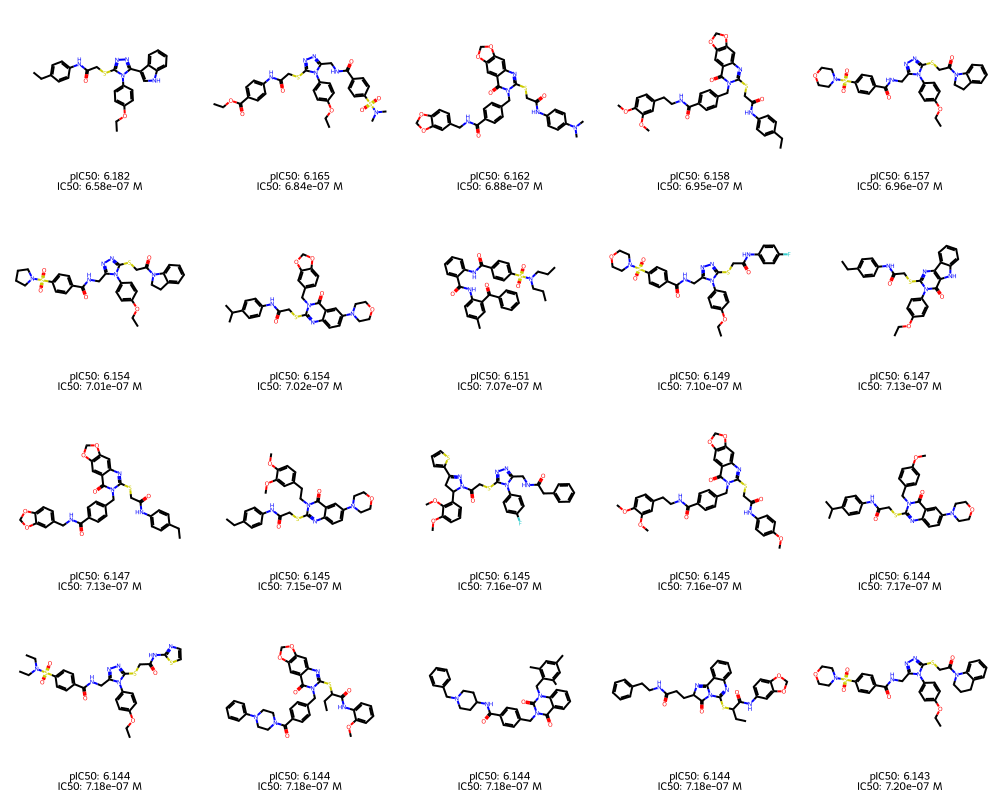

In [256]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'Marburgvirus/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in LCAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'MarburgVirus_predictedCompounds_noDuplicates_LCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'MarburgVirus_predictedCompounds_noDuplicates_LCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

## 2.3 Discovery of new hits specific to all viruses (data source `chemDiv` data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [257]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antiviral-Library-64958.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiviralsData = pd.DataFrame(records)
print(f"Original ChemDiv data shape: {ChemDivAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiviralsData['Canonical_SMILES'] = ChemDivAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiviralsData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiviralsData_filtered = ChemDivAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiviralsData = ChemDivAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiviralsData.shape}")
print(f"Removed {ChemDivAntiviralsData_filtered.shape[0] - ChemDivAntiviralsData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib = ChemDivAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
ChemDivAntiviralsData

Original ChemDiv data shape: (64958, 28)
Number of unique SMILES in training set: 152
Filtered ChemDiv data shape for validation: (64958, 28)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 64958


,IDNUMBER,available,H_acceptor,H_donor,B_rotN,N_O,logP,logD,logSw,PSA,...,InChI Key,PERCENTSP3,Link,CLNUMBER,Saltdata,Saltdata_MW,STEREO,State,SMILES,CAS
0,E676-1193,55,6,0,10,6.000,4.584,3.825,-4.736,44.193,...,CADSCKHSUSMLDE-UHFFFAOYSA-N,33.300,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,NaN
1,E676-4289,2,8,0,9,7.000,2.084,1.279,-2.867,59.381,...,GBCBRISSOXAFMF-UHFFFAOYSA-N,47.400,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,NaN
2,E676-2516,15,7,0,7,7.000,4.274,3.444,-4.355,53.078,...,LSLRIDUYGBBIBR-SFHVURJKSA-N,36.400,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,RACEMIC MIXTURE,Solid,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,NaN
3,F735-0482,21,7,2,9,7.000,3.231,3.225,-3.423,79.491,...,NBFDETMKPOQYSJ-UHFFFAOYSA-N,22.200,https://www.chemdiv.com/catalog/screening-comp...,CL8286,NaN,NaN,ACHIRAL,Solid,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,NaN
4,G211-0195,304,5,1,5,5.000,5.054,5.054,-5.469,49.877,...,DRPXIGZHBISZAU-UHFFFAOYSA-N,32.000,https://www.chemdiv.com/catalog/screening-comp...,CL6036,NaN,NaN,ACHIRAL,Solid,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64953,8010-2606,54,8,1,9,8.000,6.685,3.100,-6.678,70.818,...,ZQXAXHNEVALOJP-UHFFFAOYSA-N,30.800,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,NaN
64954,2774-1508,1,7,1,8,7.000,6.551,3.884,-5.738,62.323,...,KDXCUTJRVPCZKK-UHFFFAOYSA-N,25.000,https://www.chemdiv.com/catalog/screening-comp...,CL1652,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,NaN
64955,K061-0539,124,7,1,7,7.000,6.014,2.429,-5.464,64.713,...,XEIANUQFWJNADZ-UHFFFAOYSA-N,27.300,https://www.chemdiv.com/catalog/screening-comp...,CL1647,NaN,NaN,ACHIRAL,Solid,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,NaN
64956,K061-0894,165,6,1,7,7.000,6.905,6.387,-6.761,57.369,...,IBXAKUXFQPUZBE-UHFFFAOYSA-N,13.600,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,NaN


Generate predictions for the H1 receptor:

In [258]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

50000


In [259]:
ChemDivAntiviralsData_predicted = ChemDivAntiviralsData.copy()
ChemDivAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
ChemDivAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-ChemDivAntiviralsData_predicted['pPotency_prediction'])

ChemDivAntiviralsData_predicted = ChemDivAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
ChemDivAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_ChemDivDatasets_predicted_all.csv"), index=False)
ChemDivAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_ChemDivDatasets_predicted_all_SMILES.csv"), index=False)
ChemDivAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,5.565,2.723e-06
1,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,5.259,5.513e-06
2,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,5.469,3.396e-06
3,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,5.631,2.340e-06
4,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,5.620,2.398e-06
...,...,...,...
64953,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,5.974,1.061e-06
64954,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,5.993,1.017e-06
64955,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.921,1.198e-06
64956,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,5.982,1.042e-06


Let us represent the predictions of both models:

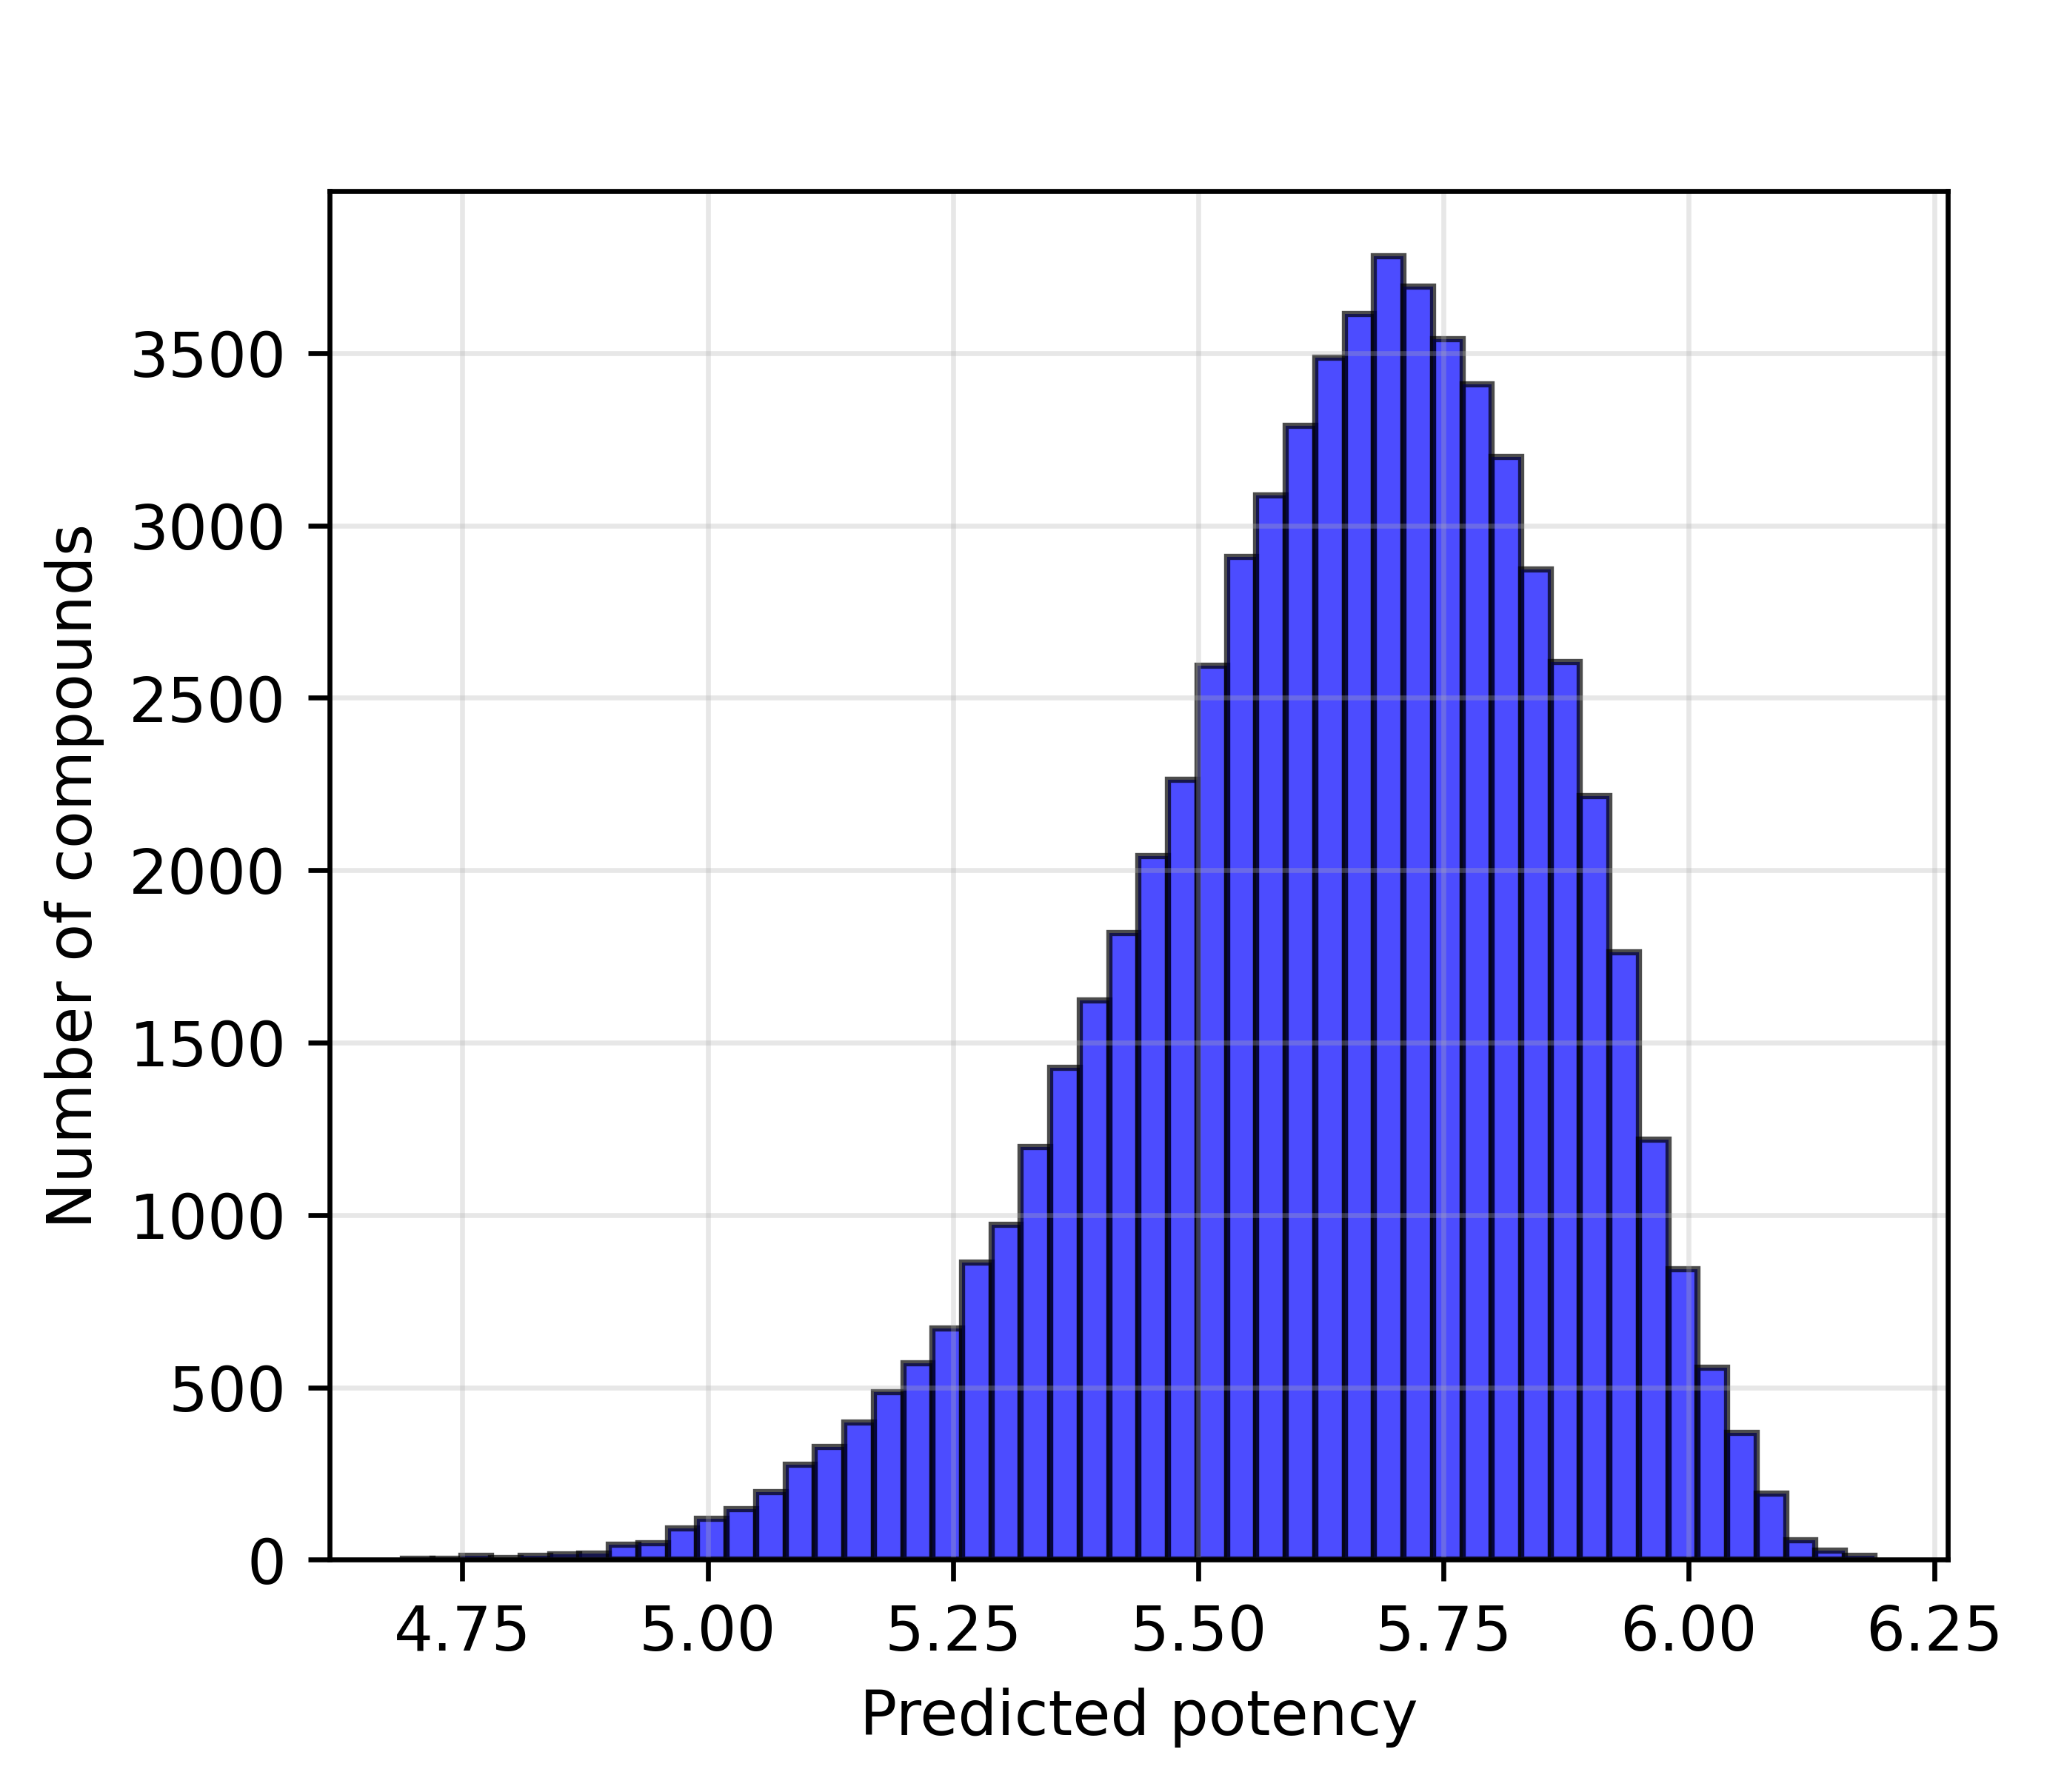

In [260]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_validation_noDuplicates_ChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_validation_noDuplicates_ChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [261]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 1442 compounds
Low priority (5 ≤ pPotency < 6): 63223 compounds


In [262]:
ChemDivAntiviralsData_final = ChemDivAntiviralsData.iloc[idx].copy()
ChemDivAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]
ChemDivAntiviralsData_final = ChemDivAntiviralsData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
ChemDivAntiviralsData_final

,SMILES,pPotency_prediction


### Top 20 compounds with higher PpPotency

In [263]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.15
Highest predicted pPotency: 6.19
Range of top 20: 6.15 - 6.19


In [264]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
ChemDivAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.147
  IC50:        7.130e-07 M  (713.00 nM)

Best Values (1st ranked compound):
  pPotency:    6.189
  IC50:        6.471e-07 M  (647.07 nM)
Range for Top 20 Compounds:
pPotency Range:  6.147 - 6.189

IC50 Range (M):  7.130e-07 - 6.471e-07


,Rank,SMILES,pPotency_prediction,IC50 (M)
36666,1,CCC(C)NS(=O)(=O)c1cc(NC(=O)C2CCCC2)ccc1Oc1c(C)...,6.189,6.471e-07
1055,2,CCC(C)NS(=O)(=O)c1cc(NC(=O)C2CCCC2)ccc1Oc1c(C)...,6.181,6.598e-07
48563,3,CCOc1ccc(C(=O)CSc2nnc3n(C)c(=O)c4ccc(C(=O)NC5C...,6.168,6.792e-07
47993,4,CCC(C)NC(=O)c1ccc2c(=O)n(C)c3nnc(SCc4ccc(N5CCC...,6.167,6.803e-07
44003,5,CCOc1ccc(C(=O)CSc2nnc3n(C)c(=O)c4ccc(C(=O)NC5C...,6.166,6.824e-07
4418,6,COc1ccc(-n2ncc(Oc3ccc4c(c3)CCC4)c(Nc3cccc(C(=O...,6.164,6.861e-07
4858,7,CC1CCN(S(=O)(=O)c2ccc3nc(-c4cccnc4)cc(C(=O)NC(...,6.163,6.868e-07
47283,8,Cc1ccccc1-n1nc(C(=O)O)c(C)c1Oc1ccc(NC(=O)C2CCC...,6.162,6.889e-07
36664,9,CCC(C)NS(=O)(=O)c1cc(NC(=O)c2cccs2)ccc1Oc1c(C)...,6.162,6.889e-07
56701,10,CC(C)c1ccc(Nc2cc(C(=O)NC(C)c3ccc4c(c3)OCCO4)c3...,6.162,6.891e-07


In [265]:
ChemDivAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_ChemDivAntiviralsData_top20.csv"), index=False)
ChemDivAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_ChemDivAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_noDuplicates_ChemDivDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_noDuplicates_ChemDivDataset.svg


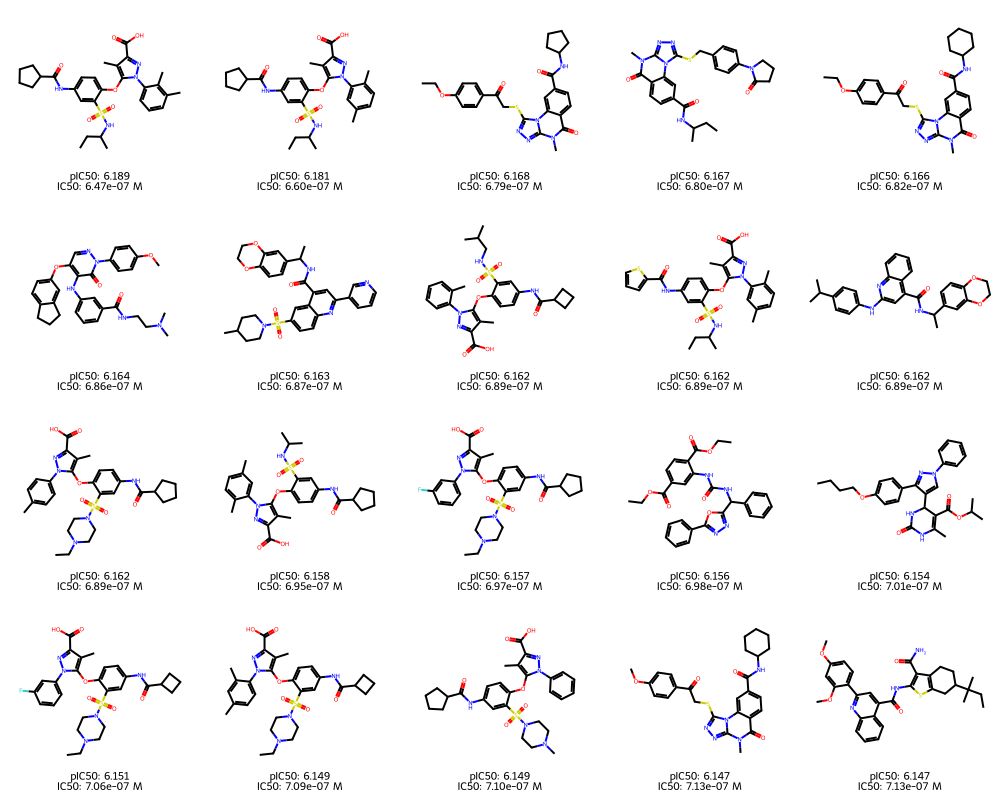

In [266]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'Marburgvirus/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in ChemDivAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'MarburgVirus_predictedCompounds_noDuplicates_ChemDivDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'MarburgVirus_predictedCompounds_noDuplicates_ChemDivDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.4 Discovery of new hits specific to all viruses (data source `SMACC` Antivirals data set)
In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. In particular, we are interested in molecules with high predicted pPotency.

In [267]:
SMACCAntiviralsData = pd.read_csv(modelBuildingDataDir + "SMACCAntiviralsData_clean.csv")

# Check for duplicates
dup_check = SMACCAntiviralsData.groupby('SMILES')['pIC50'].agg(['count', 'median', 'std'])
duplicates = dup_check[dup_check['count'] > 1]
print(f"Original SMACC data shape: {SMACCAntiviralsData.shape}, with Duplicate SMILES: {len(duplicates)}")

# Take median pIC50 for duplicates
SMACCAntiviralsData = SMACCAntiviralsData.groupby('SMILES').agg({
    'Molecule ChEMBL ID': 'first',
    'pIC50': 'median',  # Use median instead of mean
    'Virus': 'first'
}).reset_index()

print(f"After removing internal duplicates: {SMACCAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")
# Add canonical SMILES column to SMACC data (reusing canonical_train from previous code)
SMACCAntiviralsData['Canonical_SMILES'] = SMACCAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~SMACCAntiviralsData['Canonical_SMILES'].isin(canonical_train)
SMACCAntiviralsData_filtered = SMACCAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
SMACCAntiviralsData = SMACCAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered SMACC data shape for validation: {SMACCAntiviralsData.shape}")
print(f"Removed {SMACCAntiviralsData_filtered.shape[0] - SMACCAntiviralsData.shape[0]} duplicate compounds from SMACC data set")
SMACCAntiviralsData = SMACCAntiviralsData.rename(columns={'pIC50': 'pIC50_experimental'})

smi_lib = SMACCAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
SMACCAntiviralsData.head()

Original SMACC data shape: (1923, 5), with Duplicate SMILES: 197
After removing internal duplicates: (1612, 4)
Number of unique SMILES in training set: 152
Filtered SMACC data shape for validation: (1612, 4)
Removed 0 duplicate compounds from SMACC data set
Total compounds to screen: 1612


,SMILES,Molecule ChEMBL ID,pIC50_experimental,Virus
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,CHEMBL243652,5.690,SARS-CoV-2
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,CHEMBL4284511,5.328,Dengue
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,CHEMBL1402117,4.132,Dengue
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,CHEMBL4303595,7.097,SARS-CoV-2
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,CHEMBL1361582,4.627,Dengue


Generate predictions

In [268]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [269]:
SMACCAntiviralsData_predicted = SMACCAntiviralsData.copy()
SMACCAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
SMACCAntiviralsData_predicted['IC50(M)_experimental'] = 10 ** (-SMACCAntiviralsData_predicted['pIC50_experimental'])
SMACCAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-SMACCAntiviralsData_predicted['pPotency_prediction'])

SMACCAntiviralsData_predicted = SMACCAntiviralsData_predicted.filter(
    items=["SMILES", "Virus", "pIC50_experimental", "pPotency_prediction",  "IC50(M)_experimental", "pPotency(M)_prediction"]
)
SMACCAntiviralsData_predicted

,SMILES,Virus,pIC50_experimental,pPotency_prediction,IC50(M)_experimental,pPotency(M)_prediction
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,SARS-CoV-2,5.690,5.571,2.040e-06,2.687e-06
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,Dengue,5.328,5.691,4.700e-06,2.038e-06
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,Dengue,4.132,5.338,7.371e-05,4.593e-06
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,SARS-CoV-2,7.097,5.118,8.000e-08,7.620e-06
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,Dengue,4.627,5.717,2.359e-05,1.919e-06
...,...,...,...,...,...,...
1607,S=C1NN=C(Nc2ccccc2)S1,SARS-CoV-2,6.409,5.231,3.900e-07,5.876e-06
1608,S=C1Nc2ccccc2S1,SARS-CoV-2,5.759,5.162,1.740e-06,6.880e-06
1609,SC(=S)N1CCCC1,SARS-CoV-2,6.678,5.205,2.100e-07,6.233e-06
1610,c1coc(c1)-c1nc2ccccc2nc1-c1ccco1,Dengue,4.000,5.233,1.000e-04,5.843e-06


In [270]:
SMACCAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_SMACCAntiviralsData_predicted_all.csv"), index=False)
SMACCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_SMACCAntiviralsData_predicted_all_SMILES.csv"), index=False)

### Plot the error between `experimental_pPotency` and `predicted_pPotency`

Mean Residual: 0.793
Std Dev of Residuals: 1.090
Min Residual: -4.506
Max Residual: 2.754


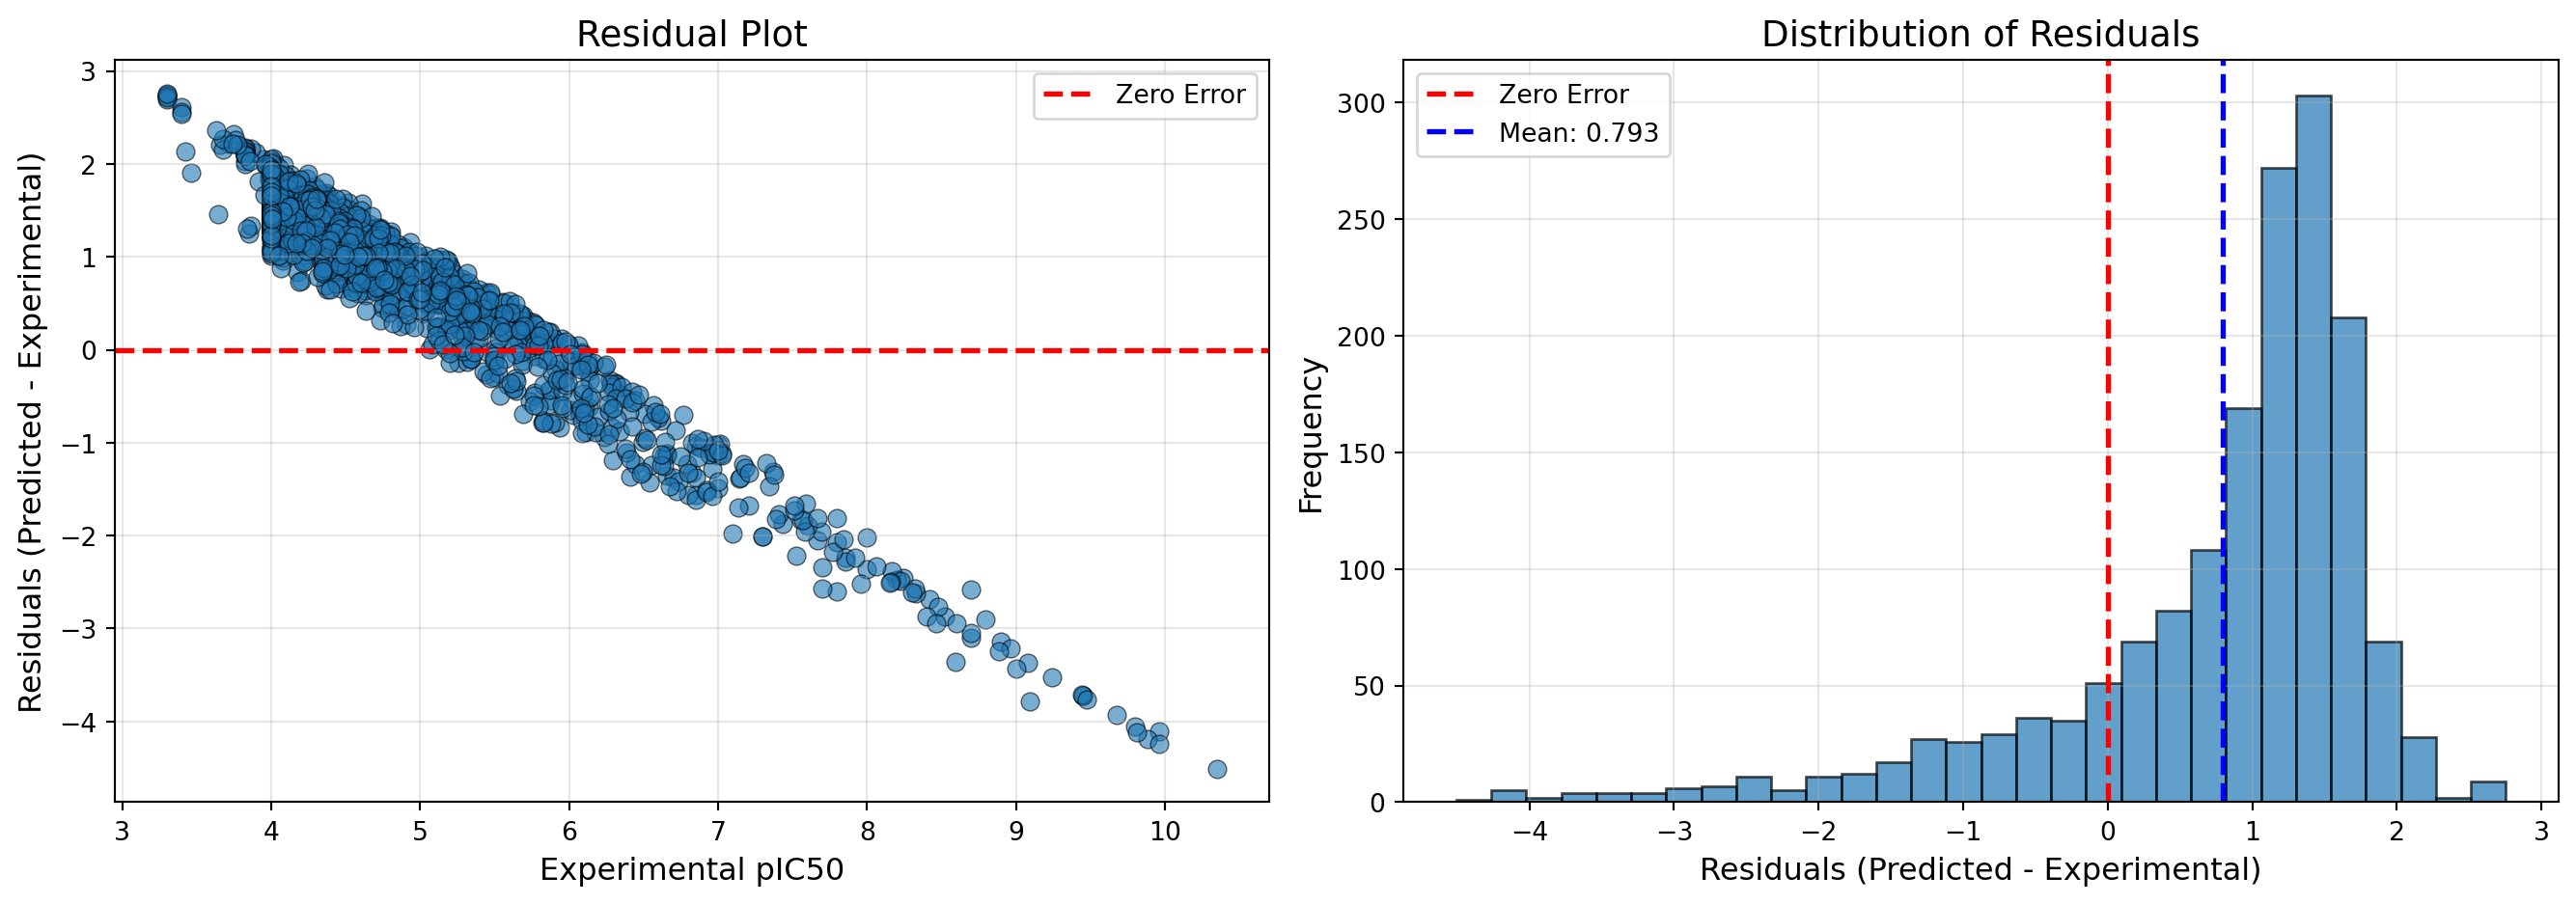

In [271]:
# Calculate residuals (difference)
SMACCAntiviralsData_predicted['residuals'] = (
    SMACCAntiviralsData_predicted['pPotency_prediction'] - 
    SMACCAntiviralsData_predicted['pIC50_experimental']
)

# Print statistics
print(f"Mean Residual: {SMACCAntiviralsData_predicted['residuals'].mean():.3f}")
print(f"Std Dev of Residuals: {SMACCAntiviralsData_predicted['residuals'].std():.3f}")
print(f"Min Residual: {SMACCAntiviralsData_predicted['residuals'].min():.3f}")
print(f"Max Residual: {SMACCAntiviralsData_predicted['residuals'].max():.3f}")

# Create residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Experimental values
axes[0].scatter(SMACCAntiviralsData_predicted['pIC50_experimental'], 
                SMACCAntiviralsData_predicted['residuals'], 
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_xlabel('Experimental pIC50', fontsize=12)
axes[0].set_ylabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution of residuals
axes[1].hist(SMACCAntiviralsData_predicted['residuals'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(x=SMACCAntiviralsData_predicted['residuals'].mean(), 
                color='blue', linestyle='--', linewidth=2, 
                label=f'Mean: {SMACCAntiviralsData_predicted["residuals"].mean():.3f}')
axes[1].set_xlabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Residual Plot Analysis

In [272]:
print(f"Mean residual: {SMACCAntiviralsData_predicted['residuals'].mean():.3f} (Close to 0 indicates no systematic bias)")
print(f"Std deviation: {SMACCAntiviralsData_predicted['residuals'].std():.3f} (typical prediction error)")
print(f"95% of predictions are within ±{1.96 * SMACCAntiviralsData_predicted['residuals'].std():.3f} pIC50 units")

Mean residual: 0.793 (Close to 0 indicates no systematic bias)
Std deviation: 1.090 (typical prediction error)
95% of predictions are within ±2.136 pIC50 units


Let us have a look at the compounds:

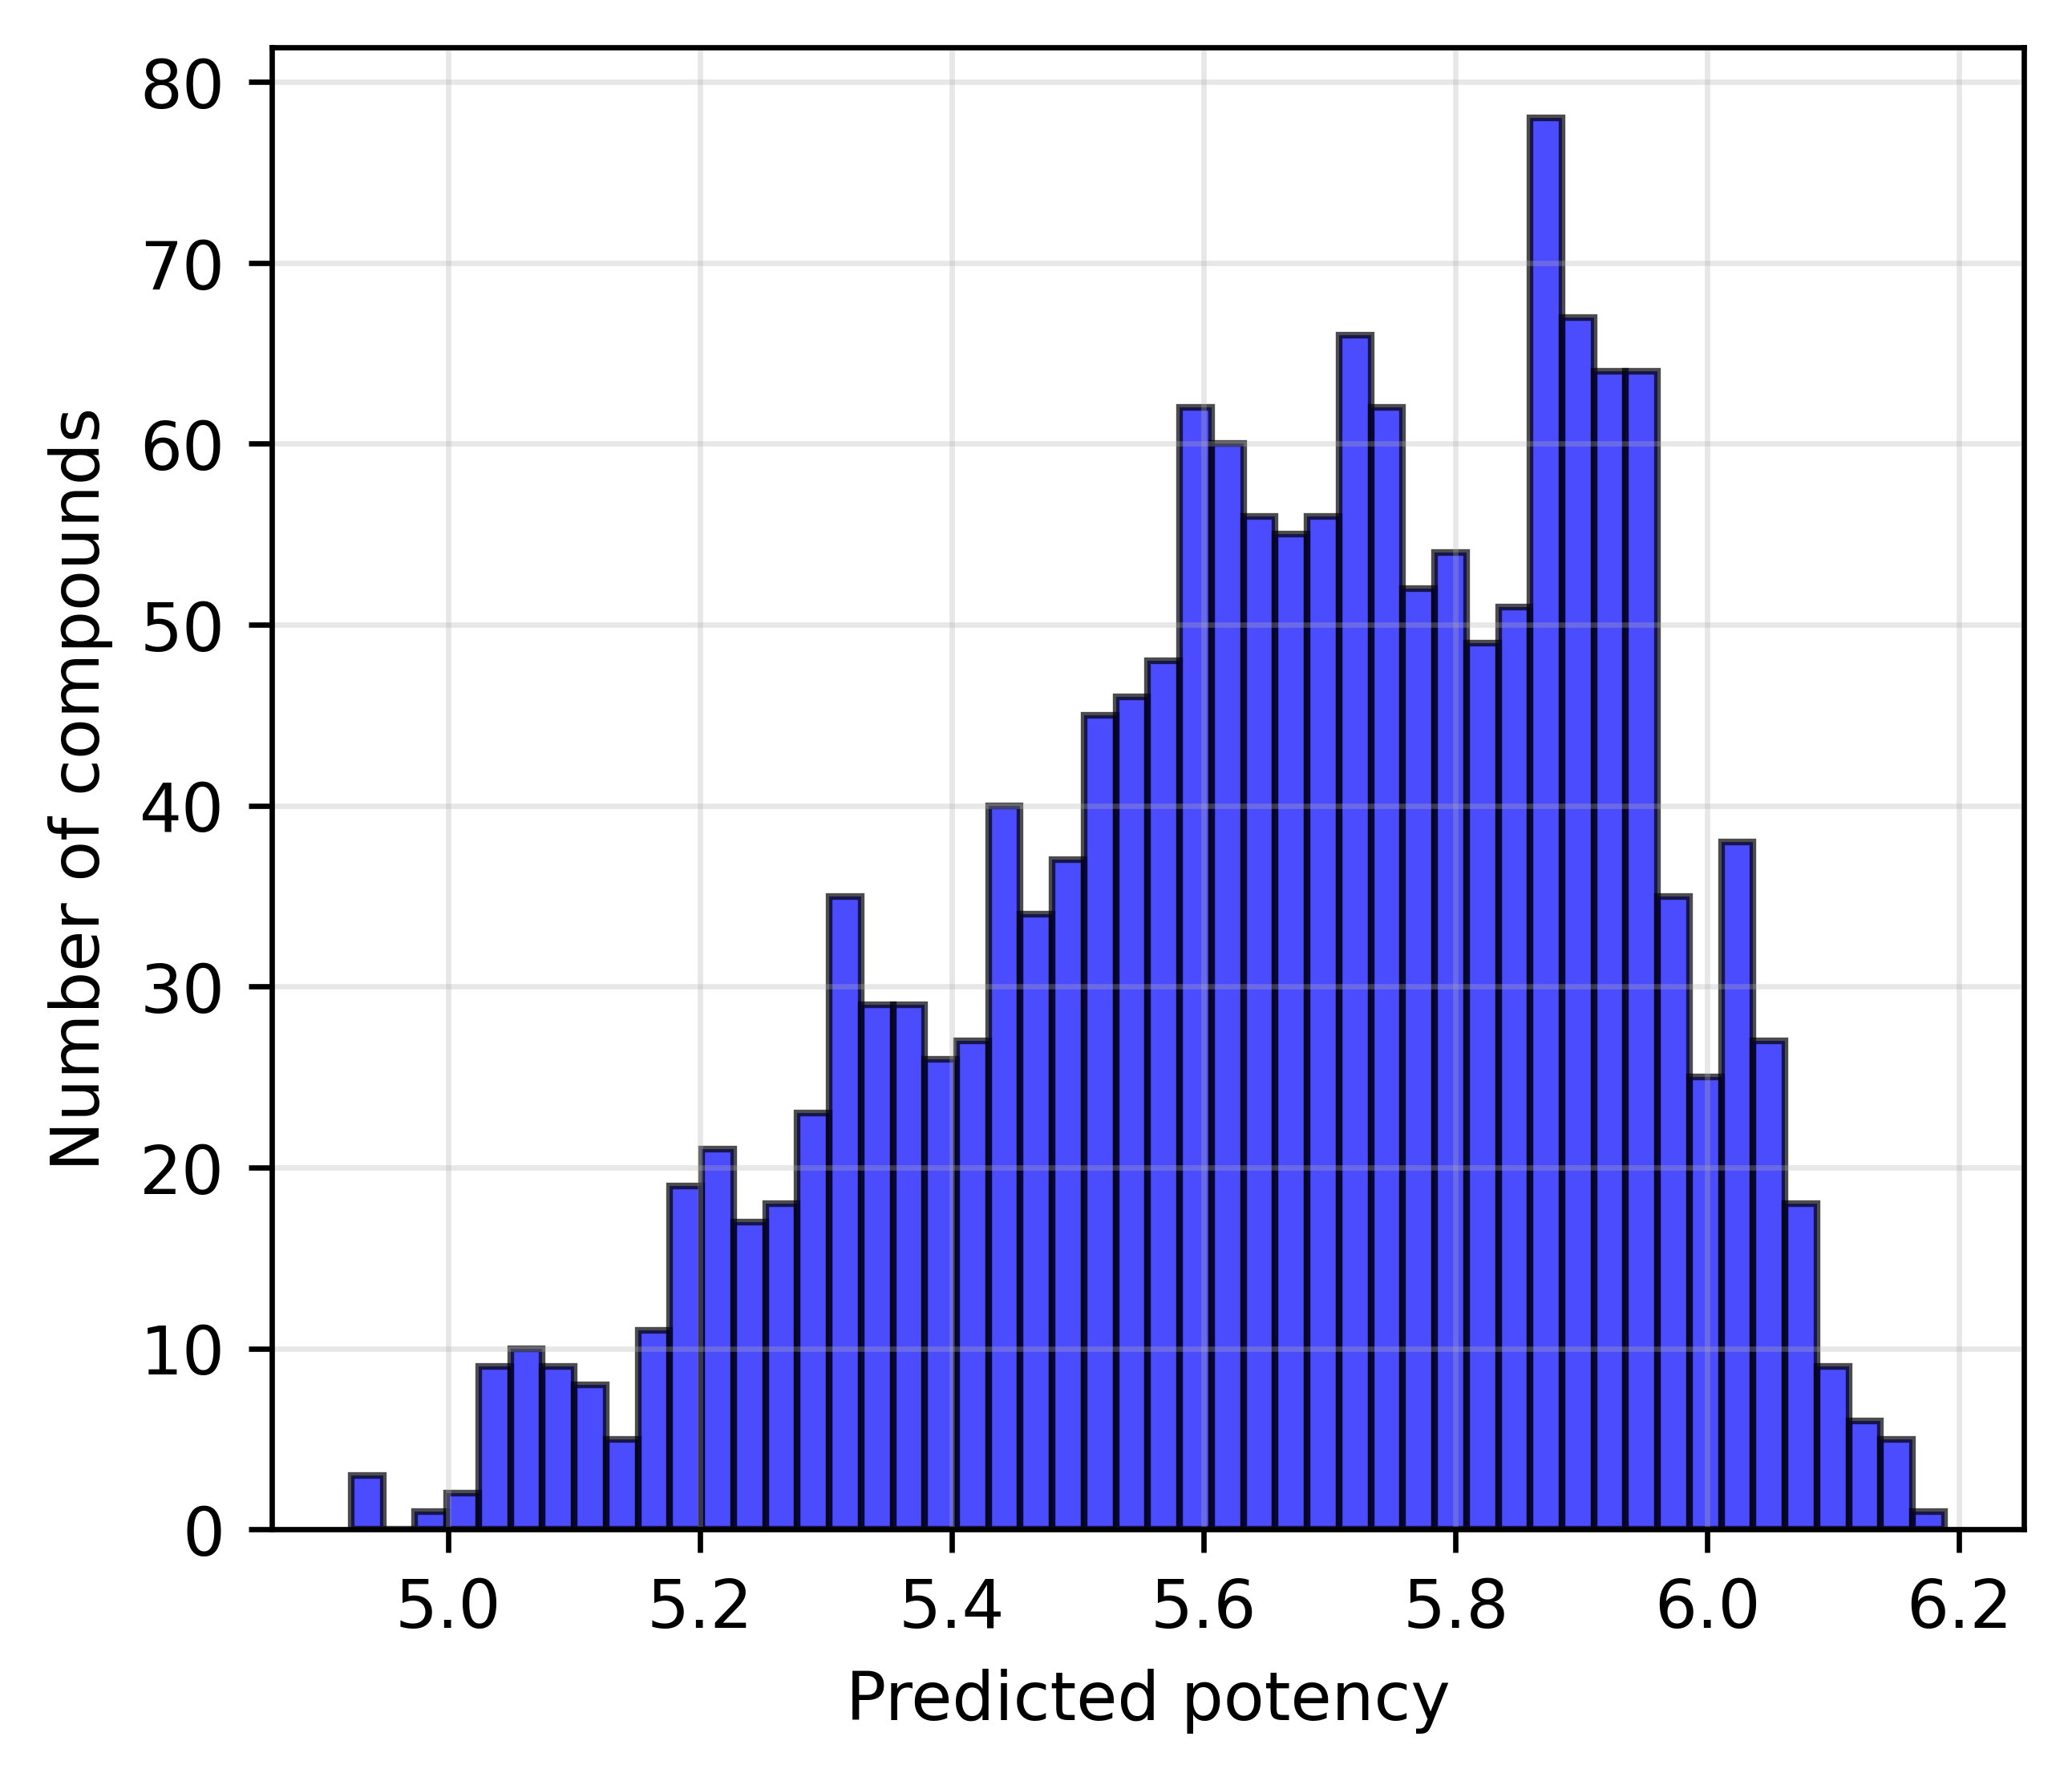

In [273]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_validation_noDuplicates_SMACCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Marburgvirus/MarburgVirus_validation_noDuplicates_SMACCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

In [274]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 117 compounds
Low priority (5 ≤ pPotency < 6): 1491 compounds


### Top 20 compounds with higher pPotency

In [275]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.10
Highest predicted pPotency: 6.19
Range of top 20: 6.10 - 6.19


In [276]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
SMACCAntiviralsData_top20 = SMACCAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
SMACCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
SMACCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
SMACCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'


SMACCAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.096
  IC50:        8.015e-07 M  (801.49 nM)

Best Values (1st ranked compound):
  pPotency:    6.188
  IC50:        6.484e-07 M  (648.43 nM)
Range for Top 20 Compounds:
pPotency Range:  6.096 - 6.188

IC50 Range (M):  8.015e-07 - 6.484e-07


,Rank,SMILES,Virus,pIC50_experimental,pPotency_prediction,IC50(M)_experimental,pPotency(M)_prediction,residuals,IC50 (M)
223,1,CC1CN=C(N1)c1ccc(Nc2nnc(Nc3ccc(cc3)C3=NCC(C)N3...,West_Nile,4.611,6.188,2.450e-05,6.484e-07,1.577,6.484e-07
878,2,Cc1ccc(NS(=O)(=O)c2ccc(NN=Cc3ccccc3OCC(O)=O)c(...,Dengue,4.357,6.156,4.391e-05,6.976e-07,1.799,6.976e-07
978,3,Cc1cccc(c1)N1CC(NC(=O)C(NC(=O)C(CCCCN)NC(=O)C(...,Dengue,5.169,6.143,6.776e-06,7.190e-07,0.974,7.190e-07
900,4,Cc1ccc(cc1)N1CC(NC(=O)C(NC(=O)C(CCCCN)NC(=O)C(...,Dengue,5.184,6.143,6.552e-06,7.197e-07,0.959,7.197e-07
751,5,COc1ccccc1NS(=O)(=O)c1ccc(NN=Cc2ccccc2OCC(O)=O...,Dengue,4.248,6.142,5.645e-05,7.211e-07,1.894,7.211e-07
1140,6,NCCCCC(NC(=O)C(CCCNC(N)=N)NC(=O)c1ccccc1)C(=O)...,Dengue,5.314,6.138,4.854e-06,7.274e-07,0.824,7.274e-07
1141,7,NCCCCC(NC(=O)C(CCCNC(N)=N)NC(=O)c1ccccc1)C(=O)...,Dengue,5.638,6.137,2.300e-06,7.292e-07,0.499,7.292e-07
1100,8,NC(Cc1c[nH]c2ccccc12)C(=O)NC(Cc1ccc(O)cc1)C(=O...,Dengue,5.135,6.133,7.332e-06,7.360e-07,0.998,7.360e-07
1139,9,NCCCCC(NC(=O)C(CCCNC(N)=N)NC(=O)c1ccccc1)C(=O)...,Dengue,5.602,6.130,2.500e-06,7.409e-07,0.528,7.409e-07
987,10,Cc1cnc(N2CC3(C2)CCOCC3)c(c1)C(=O)Nc1ccc(cc1)C(...,RSV,8.699,6.120,2.000e-09,7.579e-07,-2.579,7.579e-07


In [277]:
SMACCAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_SMACCAntiviralsData_top20.csv"), index=False)
SMACCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_SMACCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_noDuplicates_SMACCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_noDuplicates_SMACCDataset.svg


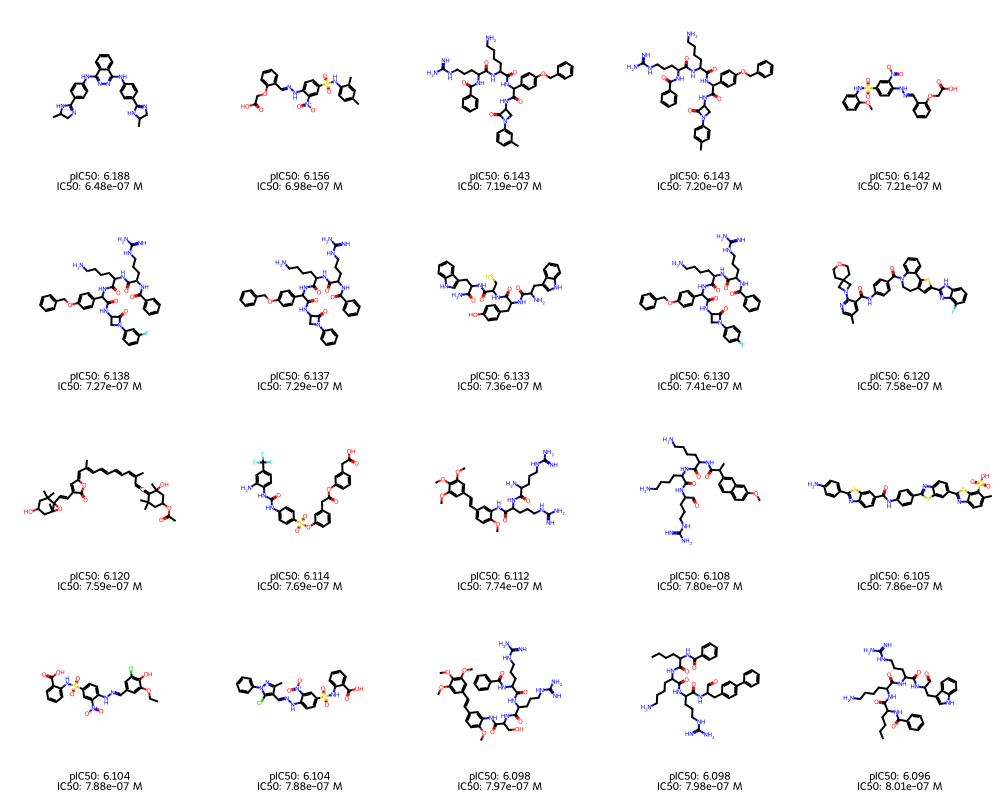

In [278]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'Marburgvirus/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in SMACCAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in SMACCAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'MarburgVirus_predictedCompounds_noDuplicates_SMACCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'MarburgVirus_predictedCompounds_noDuplicates_SMACCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  